# Homework 2 — Phát hiện vật thể trong nhà (Indoor Object Detection)

**Học viên:** Đặng Thành Nhân

---

## 1. Đề bài

> **Object detection.** Thực hiện phát hiện vật thể trong nhà.
> Dataset: <https://data.mendeley.com/datasets/nnph98d3kc/2>
> So sánh, đánh giá các mô hình dùng để thực hiện phát hiện vật thể.
> Đề xuất cải thiện nếu có.

Toàn bộ nhận xét / đánh giá được viết trực tiếp trong notebook này bằng **tiếng Việt**
(ô Markdown + comment trong code).

---

## 2. Bộ dữ liệu

| Thuộc tính | Giá trị |
|---|---|
| **Tên** | SyntheticIndoorObjectDetectionDataset |
| **Tác giả** | Nafiz Fahad — Multimedia University (Malaysia) |
| **Nguồn** | Mendeley Data, phiên bản 2, xuất bản 25/03/2025 |
| **DOI** | [10.17632/nnph98d3kc.2](https://doi.org/10.17632/nnph98d3kc.2) |
| **Giấy phép** | **CC BY 4.0** (được phép dùng lại / chỉnh sửa khi ghi nguồn) |
| **Nguồn gốc** | Trích từ bộ *MyNursingHome* (DOI [10.17632/fpctx3svzd.1](https://doi.org/10.17632/fpctx3svzd.1)), chọn 6/25 lớp |
| **Công cụ gán nhãn** | Roboflow → project *Indoor Objects v1* |
| **Định dạng nhãn** | **Pascal VOC XML** (mỗi ảnh `.jpg` đi kèm một file `.xml` cùng tên) |
| **Kích thước ảnh** | Đã resize (stretch) về **640 × 640**, auto-orientation, bỏ EXIF |
| **Số ảnh** | **7 107** ảnh sau tăng cường (gốc 2 993 → lọc chất lượng còn 2 961) |
| **Dung lượng tải** | 1 file zip ≈ **208 MB** (218 384 956 bytes), giải nén ≈ 210 MB |

**Danh sách lớp (6 lớp, tên chính xác như trong file XML):**

`basketbin`, `chair`, `door`, `human`, `sofa`, `table`

Số ảnh gốc theo lớp trước khi lọc: basket bin 499, sofa 499, human 499, table 500,
chair 496, door 500 → khá **cân bằng ở mức ảnh**; ta vẫn sẽ kiểm chứng lại mức cân bằng
**theo số bounding box** trong phần EDA.

**Cấu trúc bên trong file zip** (đã kiểm tra trực tiếp central directory của file zip):

```
SyntheticIndoorObjectDetectionDataset.zip
├── README.dataset.txt          # thông tin project Roboflow
├── README.roboflow.txt         # mô tả pipeline tiền xử lý + tăng cường
├── train/                      # 6 219 ảnh .jpg + 6 219 nhãn .xml  (thư mục phẳng)
├── valid/                      #   591 ảnh .jpg +   591 nhãn .xml
└── test/                       #   297 ảnh .jpg +   297 nhãn .xml
```

Tên file có dạng `00002_jpg.rf.<md5>.jpg`. Phần **trước** `_jpg.rf.` là *id ảnh gốc*,
phần hash phía sau phân biệt các **bản tăng cường khác nhau của cùng một ảnh gốc**.
Chi tiết này rất quan trọng: nếu chia lại train/val/test **ngẫu nhiên theo từng ảnh**, các bản
tăng cường của cùng một ảnh gốc sẽ rơi vào cả tập huấn luyện lẫn tập kiểm tra →
**rò rỉ dữ liệu (data leakage)**, làm mAP bị thổi phồng. Notebook này chia theo **nhóm ảnh gốc**
để tránh điều đó (xem Phần 5).

**Tiền xử lý & tăng cường của tác giả** (theo `README.roboflow.txt`): auto-orient, resize
640×640 (stretch); tăng cường tạo 3 phiên bản/ảnh huấn luyện: lật ngang 50%, lật dọc 50%,
xoay 90° (none / CW / CCW / 180°) đều xác suất, xoay ngẫu nhiên ±15°, shear ±10° theo cả hai
trục, chỉnh độ sáng ±15%.

### Trích dẫn

> Fahad, N. (2025). *SyntheticIndoorObjectDetectionDataset* (Version 2) [Data set].
> Mendeley Data. https://doi.org/10.17632/nnph98d3kc.2 — License: CC BY 4.0
>
> Bộ nguồn: Ismail, A. và cộng sự. *MyNursingHome: A fully-labelled image dataset for indoor
> object classification.* Data in Brief (2020). https://doi.org/10.1016/j.dib.2020.106268

---

## 3. Kế hoạch thực hiện

| Bước | Nội dung |
|---|---|
| 1 | Kiểm tra runtime Colab (GPU / đĩa), gắn Google Drive, cài `ultralytics`, đặt `SEED`, `QUICK_RUN` |
| 2 | Tải & giải nén dataset **headless** từ Mendeley public API (dự phòng `wget` / upload tay) |
| 3 | Đọc nhãn (tự nhận diện VOC / YOLO / COCO) → **chỉ mục thống nhất** trong bộ nhớ |
| 4 | EDA: phân bố lớp, số hộp/ảnh, diện tích & tỉ lệ khung, lưới ảnh mẫu có vẽ hộp |
| 5 | Chia 70/15/15 có seed, **theo nhóm ảnh gốc** + phân tầng theo lớp trội |
| 6 | Chuyển đổi sang **YOLO** (cho Ultralytics) và **COCO JSON** (cho torchvision + pycocotools) |
| 7 | Huấn luyện **5 mô hình** thuộc 3 họ kiến trúc khác nhau trên **cùng một split** |
| 8 | Đánh giá bằng **một bộ đo duy nhất** (pycocotools) trên tập test: mAP@0.5, mAP@0.5:0.95, AP từng lớp, P/R/F1, tốc độ, số tham số |
| 9 | Bảng so sánh + biểu đồ + scatter *độ chính xác ↔ tốc độ* + so sánh định tính & ca lỗi |
| 10 | **Đánh giá / phân tích** và **Đề xuất cải thiện** (có thực nghiệm minh hoạ) |

> ⚠️ **Nguyên tắc đo lường công bằng:** notebook **không** lấy chỉ số nội bộ của Ultralytics
> đem so với chỉ số của thư viện khác. Mọi mô hình đều được chạy suy luận trên **cùng danh sách
> ảnh test**, kết quả đưa về **cùng định dạng COCO detection**, rồi chấm bằng **cùng một `COCOeval`**.

> ⏱️ **Thời gian chạy ước tính trên Colab T4** (chỉ để tham khảo, phụ thuộc GPU được cấp):
> `QUICK_RUN = True` (10 epoch YOLO / 4 epoch torchvision, có lấy mẫu con) ≈ **40–70 phút** cho cả 5 mô hình.
> `QUICK_RUN = False` (50 epoch YOLO / 12 epoch torchvision, toàn bộ dữ liệu) ≈ **5–9 giờ** —
> gần chạm giới hạn ~12 h của một phiên Colab, nên **bắt buộc** gắn Google Drive để lưu checkpoint.

---
# Phần 1 — Kiểm tra runtime Colab, cài đặt, cấu hình

### 1.1 Kiểm tra GPU và dung lượng đĩa

Nếu ô dưới báo **không có GPU**, hãy vào **Runtime → Change runtime type → Hardware
accelerator → GPU (T4)** rồi chạy lại notebook từ đầu.

In [1]:
# =============================================================================
# KIỂM TRA RUNTIME COLAB: GPU + DUNG LƯỢNG ĐĨA
# =============================================================================
!nvidia-smi || echo "Không có nvidia-smi -> runtime hiện tại KHÔNG có GPU"
print()
!df -h /content

Tue Aug 25 06:45:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   35C    P0             59W /  400W |    1906MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import sys, os, torch

IN_COLAB = "google.colab" in sys.modules or os.path.isdir("/content")
print(f"Đang chạy trên Colab: {IN_COLAB}")
print(f"torch: {torch.__version__}  |  CUDA build: {torch.version.cuda}")

if not torch.cuda.is_available():
    print("\n" + "!" * 74)
    print("KHÔNG PHÁT HIỆN GPU.")
    print("Vào  Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)")
    print("rồi chạy lại notebook từ ô đầu tiên.")
    print("Notebook vẫn chạy được trên CPU nhưng sẽ RẤT chậm — nếu buộc phải chạy CPU,")
    print("hãy để QUICK_RUN = True ở ô cấu hình bên dưới.")
    print("!" * 74)
else:
    p = torch.cuda.get_device_properties(0)
    print(f"GPU  : {p.name}")
    print(f"VRAM : {p.total_memory / 1024**3:.1f} GB")

Đang chạy trên Colab: True
torch: 2.11.0+cu128  |  CUDA build: 12.8
GPU  : NVIDIA A100-SXM4-80GB
VRAM : 79.3 GB


### 1.2 Gắn Google Drive (khuyến nghị)

Object detection train lâu, mà phiên Colab có thể **ngắt kết nối** (giới hạn ~12 giờ, hoặc
timeout khi để máy nhàn rỗi). Ô dưới gắn Drive để lưu **checkpoint + bảng kết quả**;
nếu bỏ qua / không gắn được thì vẫn chạy bình thường nhưng mọi thứ sẽ mất khi runtime chết.

Nếu bị ngắt giữa chừng, với Ultralytics chỉ cần chạy lại và đổi thành
`YOLO(<CKPT_DIR>/<tên_run>/weights/last.pt).train(resume=True)` để học tiếp.

In [3]:
# =============================================================================
# GẮN GOOGLE DRIVE (tuỳ chọn) - để checkpoint sống sót qua các lần ngắt kết nối
# =============================================================================
try:
    from google.colab import drive
    drive.mount('/content/drive')
    CKPT_DIR = '/content/drive/MyDrive/dl_homework/hw2'
except Exception as e:
    print(f"Không gắn được Drive ({e}) -> lưu tạm trong /content (mất khi runtime chết).")
    CKPT_DIR = '/content/ckpt'

os.makedirs(CKPT_DIR, exist_ok=True)
print("CKPT_DIR =", CKPT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CKPT_DIR = /content/drive/MyDrive/dl_homework/hw2


In [4]:
# =============================================================================
# CẤU HÌNH TOÀN CỤC  --  chỉnh ở đây là đủ, mọi ô sau đều đọc từ đây
# =============================================================================
from pathlib import Path
import random

SEED = 42

# QUICK_RUN = True  -> chạy nhanh (smoke test): lấy mẫu con dữ liệu + ít epoch (~40-70 phút/T4)
# QUICK_RUN = False -> chạy đầy đủ trên toàn bộ dữ liệu (~5-9 giờ/T4)
QUICK_RUN = True

# --- Thư mục làm việc trên Colab -------------------------------------------
BASE_DIR  = Path("/content/indoor_det")
DATA_ROOT = BASE_DIR / "data"     # nơi tải & giải nén dataset gốc
WORK_DIR  = BASE_DIR / "work"     # dữ liệu đã chuyển đổi (YOLO / COCO json)
RUNS_DIR  = Path(CKPT_DIR)        # checkpoint + kết quả (ưu tiên Drive)
for _d in (BASE_DIR, DATA_ROOT, WORK_DIR, RUNS_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# --- Siêu tham số dùng CHUNG cho mọi mô hình (để so sánh công bằng) ---------
IMG_SIZE    = 640      # mọi mô hình đều được ép về cùng độ phân giải 640
CONF_EVAL   = 0.001    # ngưỡng conf khi sinh detection để chấm mAP (chuẩn COCO)
NMS_IOU     = 0.6      # ngưỡng IoU của NMS dùng chung
MAX_DET     = 100      # số detection tối đa / ảnh (chuẩn COCO maxDets=100)
CONF_REPORT = 0.25     # ngưỡng conf khi báo cáo Precision/Recall/F1 "vận hành"
IOU_REPORT  = 0.50     # ngưỡng IoU khi báo cáo P/R/F1

# --- Ngân sách huấn luyện (VRAM T4/L4 ~15-16 GB) ---------------------------
if QUICK_RUN:
    EPOCHS_YOLO   = 10
    EPOCHS_TV     = 4       # torchvision (Faster R-CNN / RetinaNet / SSDlite)
    BATCH_YOLO    = 16
    BATCH_TV      = 8
    MAX_TRAIN_IMG = 1200    # lấy mẫu con cho nhanh
    MAX_VAL_IMG   = 200
    MAX_TEST_IMG  = 200
    SPEED_N       = 30      # số ảnh dùng đo tốc độ suy luận
else:
    EPOCHS_YOLO   = 50
    EPOCHS_TV     = 12
    BATCH_YOLO    = 32      # T4 15 GB chịu được 32 @640 với YOLOv8n/s; giảm nếu OOM
    BATCH_TV      = 8       # Faster R-CNN R50-FPN @640 nặng -> 8 là hợp lý
    MAX_TRAIN_IMG = None
    MAX_VAL_IMG   = None
    MAX_TEST_IMG  = None
    SPEED_N       = 50

NUM_WORKERS = 2            # Colab: 2 worker là tối ưu
PIN_MEMORY  = torch.cuda.is_available()

# --- Chia dữ liệu -----------------------------------------------------------
# "regroup" : chia lại 70/15/15 theo NHÓM ảnh gốc (chống rò rỉ do ảnh tăng cường)
# "official": dùng đúng thư mục train/valid/test do tác giả cung cấp
SPLIT_MODE  = "regroup"
SPLIT_RATIO = (0.70, 0.15, 0.15)

# --- Các mô hình sẽ so sánh -------------------------------------------------
# Đổi True -> False để bỏ bớt mô hình nếu muốn chạy nhanh hơn.
MODEL_ENABLED = {
    "YOLOv8n":            True,   # 1-stage, anchor-free, siêu nhẹ
    "YOLOv8s":            True,   # 1-stage, anchor-free, bản lớn hơn
    "FasterRCNN-R50-FPN": True,   # 2-stage, anchor-based
    "RetinaNet-R50-FPN":  True,   # 1-stage, anchor-based, focal loss
    "SSDlite-MBv3":       True,   # 1-stage, anchor-based, hard negative mining
}

print(f"BASE_DIR  = {BASE_DIR}")
print(f"RUNS_DIR  = {RUNS_DIR}")
print(f"QUICK_RUN = {QUICK_RUN} | SPLIT_MODE = {SPLIT_MODE} | SEED = {SEED} | IMG_SIZE = {IMG_SIZE}")
print(f"epoch: YOLO={EPOCHS_YOLO}, torchvision={EPOCHS_TV} | batch: YOLO={BATCH_YOLO}, tv={BATCH_TV}")
print("Mô hình bật:", [k for k, v in MODEL_ENABLED.items() if v])

BASE_DIR  = /content/indoor_det
RUNS_DIR  = /content/drive/MyDrive/dl_homework/hw2
QUICK_RUN = True | SPLIT_MODE = regroup | SEED = 42 | IMG_SIZE = 640
epoch: YOLO=10, torchvision=4 | batch: YOLO=16, tv=8
Mô hình bật: ['YOLOv8n', 'YOLOv8s', 'FasterRCNN-R50-FPN', 'RetinaNet-R50-FPN', 'SSDlite-MBv3']


### 1.3 Cài thư viện

Colab đã cài sẵn `torch` (bản CUDA), `torchvision`, `numpy`, `pandas`, `matplotlib`,
`seaborn`, `scikit-learn`, `scipy`, `Pillow`, `tqdm`, `requests`, `opencv-python`,
`pycocotools`. **Không cài lại `torch`/`torchvision`** vì vừa mất vài phút vừa có nguy cơ
hỏng bản CUDA. Chỉ cần bổ sung `ultralytics`.

In [5]:
# =============================================================================
# CÀI THƯ VIỆN CÒN THIẾU (guarded - chạy lại nhiều lần vô hại)
# =============================================================================
try:
    import ultralytics                      # noqa: F401
    print("ultralytics: đã có", ultralytics.__version__)
except ImportError:
    !pip install -q ultralytics
    import ultralytics
    print("ultralytics: vừa cài", ultralytics.__version__)

try:
    import pycocotools                      # noqa: F401
    print("pycocotools: đã có")
except ImportError:
    !pip install -q pycocotools

# torchmetrics chỉ dùng làm PHƯƠNG ÁN DỰ PHÒNG nếu pycocotools lỗi.
try:
    import torchmetrics                     # noqa: F401
    print("torchmetrics: đã có", torchmetrics.__version__)
except ImportError:
    print("torchmetrics chưa có (không bắt buộc).")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 7.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
ultralytics: vừa cài 8.4.128
pycocotools: đã có
torchmetrics chưa có (không bắt buộc).


In [6]:
# =============================================================================
# IMPORT + SEED + THIẾT BỊ
# =============================================================================
import json, math, time, shutil, zipfile, warnings, importlib.util
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import requests
from PIL import Image
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

HAS_TV           = importlib.util.find_spec("torchvision") is not None
HAS_ULTRA        = importlib.util.find_spec("ultralytics") is not None
HAS_COCOTOOLS    = importlib.util.find_spec("pycocotools") is not None
HAS_TORCHMETRICS = importlib.util.find_spec("torchmetrics") is not None

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = (DEVICE == "cuda")          # AMP chỉ bật khi có CUDA (AMP-guard)


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(SEED)

if HAS_TV:
    import torchvision
    print("torchvision :", torchvision.__version__)
print("torch       :", torch.__version__)
print("numpy       :", np.__version__)
print("DEVICE      :", DEVICE, "| AMP:", USE_AMP,
      "| num_workers:", NUM_WORKERS, "| pin_memory:", PIN_MEMORY)
print("pycocotools :", "có" if HAS_COCOTOOLS else "KHÔNG (sẽ dùng torchmetrics)")

torchvision : 0.26.0+cu128
torch       : 2.11.0+cu128
numpy       : 2.1.3
DEVICE      : cuda | AMP: True | num_workers: 2 | pin_memory: True
pycocotools : có


---
# Phần 2 — Tải và giải nén bộ dữ liệu (headless)

Mendeley Data có *public API* trả về URL tải trực tiếp:

```
https://data.mendeley.com/public-api/datasets/nnph98d3kc/files?folder_id=root&version=2
```

Ô dưới: (1) gọi API lấy URL, (2) tải bằng `requests` dạng **stream có thanh tiến trình,
tự nối tiếp (resume) khi đứt mạng và thử lại nhiều lần**, (3) đối chiếu kích thước
(218 384 956 bytes), (4) giải nén, (5) **xoá file zip** để tiết kiệm đĩa Colab.

**Nếu bước này thất bại**, có hai phương án dự phòng ngay bên dưới:
* ô `!wget -c <url>` (tải tiếp được, chạy headless);
* ô `files.upload()` để tự tải file zip từ máy cá nhân lên Colab.

In [7]:
# =============================================================================
# TẢI DATASET (stream + resume + retry) VÀ GIẢI NÉN
# =============================================================================
MENDELEY_API = ("https://data.mendeley.com/public-api/datasets/"
                "nnph98d3kc/files?folder_id=root&version=2")
# URL tải trực tiếp đã xác minh (dùng khi API không truy cập được)
FALLBACK_URL = ("https://data.mendeley.com/public-files/datasets/nnph98d3kc/files/"
                "16784713-d6da-4e02-a0b6-2f1d253747e6/file_downloaded")

ZIP_NAME      = "SyntheticIndoorObjectDetectionDataset.zip"
ZIP_PATH      = DATA_ROOT / ZIP_NAME
EXTRACT_DIR   = DATA_ROOT / "SyntheticIndoorObjectDetectionDataset"
EXPECTED_SIZE = 218_384_956      # bytes, theo metadata Mendeley
UA = {"User-Agent": "Mozilla/5.0 (X11; Linux x86_64)"}

DATASET_URL = FALLBACK_URL       # sẽ được cập nhật nếu API trả lời


def resolve_download_url() -> str:
    try:
        r = requests.get(MENDELEY_API, headers=UA, timeout=60)
        r.raise_for_status()
        meta = r.json()[0]
        cd = meta["content_details"]
        print(f"API OK -> {meta['filename']} ({cd['size'] / 1e6:.1f} MB)")
        return cd["download_url"]
    except Exception as e:
        print(f"[!] Không gọi được API ({e}); dùng URL dự phòng đã xác minh.")
        return FALLBACK_URL


def download_with_resume(url: str, dest: Path, expected: int = None, retries: int = 6) -> bool:
    for attempt in range(1, retries + 1):
        done = dest.stat().st_size if dest.exists() else 0
        if expected and done == expected:
            return True
        headers = dict(UA)
        if done:
            headers["Range"] = f"bytes={done}-"
        try:
            with requests.get(url, headers=headers, stream=True, timeout=120) as r:
                if r.status_code not in (200, 206):
                    raise RuntimeError(f"HTTP {r.status_code}")
                # Nếu máy chủ bỏ qua header Range -> phải ghi lại từ đầu
                mode = "ab" if (done and r.status_code == 206) else "wb"
                if mode == "wb":
                    done = 0
                total = int(r.headers.get("Content-Length", 0)) + done
                with open(dest, mode) as f, tqdm(
                    total=total or None, initial=done, unit="B", unit_scale=True,
                    desc=f"tải (lần {attempt})"
                ) as bar:
                    for chunk in r.iter_content(chunk_size=1 << 20):
                        if chunk:
                            f.write(chunk)
                            bar.update(len(chunk))
            size = dest.stat().st_size
            if expected is None or size == expected:
                return True
            print(f"[!] Kích thước {size:,} != {expected:,} -> thử lại...")
        except Exception as e:
            print(f"[!] Lỗi lần {attempt}: {e}")
    return False


def extract_zip(zpath: Path, outdir: Path):
    outdir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zpath) as zf:
        members = zf.namelist()
        for m in tqdm(members, desc="giải nén"):
            zf.extract(m, outdir)
    print(f"Đã giải nén {len(members):,} mục -> {outdir}")


DOWNLOAD_OK = (EXTRACT_DIR / "train").is_dir() or (DATA_ROOT / "train").is_dir()

if DOWNLOAD_OK:
    print("Đã có dữ liệu giải nén sẵn -> bỏ qua bước tải.")
else:
    if ZIP_PATH.exists() and ZIP_PATH.stat().st_size == EXPECTED_SIZE:
        print("Đã có file zip đầy đủ -> bỏ qua bước tải.")
        ok = True
    else:
        DATASET_URL = resolve_download_url()
        ok = download_with_resume(DATASET_URL, ZIP_PATH, EXPECTED_SIZE)

    if ok:
        extract_zip(ZIP_PATH, EXTRACT_DIR)
        # Đĩa Colab hạn chế -> xoá file zip 208 MB sau khi đã giải nén
        try:
            ZIP_PATH.unlink()
            print("Đã xoá file zip để tiết kiệm dung lượng đĩa.")
        except OSError as e:
            print("Không xoá được zip:", e)
        DOWNLOAD_OK = True
    else:
        print("\n" + "=" * 74)
        print("TẢI TỰ ĐỘNG THẤT BẠI -> hãy chạy 1 trong 2 ô DỰ PHÒNG ngay bên dưới.")
        print("=" * 74)

!df -h /content | tail -n 1

[!] Không gọi được API (403 Client Error: Forbidden for url: https://data.mendeley.com/public-api/datasets/nnph98d3kc/files?folder_id=root&version=2); dùng URL dự phòng đã xác minh.
[!] Lỗi lần 1: HTTP 403
[!] Lỗi lần 2: HTTP 403
[!] Lỗi lần 3: HTTP 403
[!] Lỗi lần 4: HTTP 403
[!] Lỗi lần 5: HTTP 403
[!] Lỗi lần 6: HTTP 403

TẢI TỰ ĐỘNG THẤT BẠI -> hãy chạy 1 trong 2 ô DỰ PHÒNG ngay bên dưới.
overlay         236G   49G  188G  21% /


#### Dự phòng 1 — tải bằng `wget` (headless, nối tiếp được)

Chỉ chạy ô này **nếu ô trên báo thất bại**.

In [8]:
# DỰ PHÒNG 1: wget -c (continue). Bỏ qua nếu bước tải phía trên đã thành công.
if not DOWNLOAD_OK:
    url = DATASET_URL
    !wget -c -O "{ZIP_PATH}" "{url}"
    if ZIP_PATH.exists() and ZIP_PATH.stat().st_size == EXPECTED_SIZE:
        extract_zip(ZIP_PATH, EXTRACT_DIR)
        ZIP_PATH.unlink(missing_ok=True)
        DOWNLOAD_OK = True
        print("Dự phòng 1 thành công.")
    else:
        print("Dự phòng 1 vẫn chưa xong -> thử Dự phòng 2 (upload tay).")
else:
    print("Không cần chạy ô này.")

--2026-08-25 06:46:12--  https://data.mendeley.com/public-files/datasets/nnph98d3kc/files/16784713-d6da-4e02-a0b6-2f1d253747e6/file_downloaded
Resolving data.mendeley.com (data.mendeley.com)... 162.159.130.86, 162.159.133.86
Connecting to data.mendeley.com (data.mendeley.com)|162.159.130.86|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d9d485f1-2817-41c4-8fdc-ae616e50303c [following]
--2026-08-25 06:46:12--  https://prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com/d9d485f1-2817-41c4-8fdc-ae616e50303c
Resolving prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)... 3.5.72.105, 3.5.69.62, 3.5.75.58, ...
Connecting to prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com (prod-dcd-datasets-public-files-eu-west-1.s3.eu-west-1.amazonaws.com)|3.5.72.105|:443... connec

giải nén:   0%|          | 0/14219 [00:00<?, ?it/s]

Đã giải nén 14,219 mục -> /content/indoor_det/data/SyntheticIndoorObjectDetectionDataset
Dự phòng 1 thành công.


#### Dự phòng 2 — tự tải file zip lên Colab

Nếu cả hai cách trên đều bị chặn: vào <https://data.mendeley.com/datasets/nnph98d3kc/2>,
bấm **Download all (218 MB)**, rồi chạy ô dưới và chọn file `SyntheticIndoorObjectDetectionDataset.zip`
từ máy của bạn (lưu ý: upload 208 MB qua trình duyệt có thể mất vài phút).

In [9]:
# DỰ PHÒNG 2: upload tay. Bỏ qua nếu đã có dữ liệu.
if not DOWNLOAD_OK:
    from google.colab import files
    up = files.upload()                       # chọn file .zip từ máy cá nhân
    for fname in up:
        src = Path("/content") / fname
        if src.suffix.lower() == ".zip":
            extract_zip(src, EXTRACT_DIR)
            src.unlink(missing_ok=True)
            DOWNLOAD_OK = True
    print("Dự phòng 2:", "thành công" if DOWNLOAD_OK else "thất bại")
else:
    print("Không cần chạy ô này.")

Không cần chạy ô này.


In [10]:
# =============================================================================
# XÁC ĐỊNH CẤU TRÚC THƯ MỤC THỰC TẾ (tự dò, không phụ thuộc cách giải nén)
# =============================================================================
SPLIT_ALIASES = {
    "train": "train", "training": "train",
    "valid": "val", "val": "val", "validation": "val",
    "test": "test", "testing": "test",
}
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp"}


def find_split_dirs(root: Path) -> dict:
    # Trả về {split_chuẩn: Path} bằng cách quét đệ quy tìm thư mục train/valid/test có ảnh.
    found = {}
    for p in sorted(root.rglob("*")):
        if not p.is_dir():
            continue
        key = SPLIT_ALIASES.get(p.name.lower())
        if key is None or key in found:
            continue
        if any(c.suffix.lower() in IMG_EXT for c in p.iterdir() if c.is_file()):
            found[key] = p
    return found


SPLIT_DIRS = find_split_dirs(DATA_ROOT)
if not SPLIT_DIRS:
    raise FileNotFoundError(
        f"Không tìm thấy thư mục train/valid/test trong {DATA_ROOT}. "
        "Hãy kiểm tra lại bước tải/giải nén, hoặc chỉnh DATA_ROOT ở ô cấu hình."
    )

print("Thư mục dữ liệu tìm được:")
rows = []
for k in ("train", "val", "test"):
    if k in SPLIT_DIRS:
        d = SPLIT_DIRS[k]
        imgs = [p for p in d.rglob("*") if p.suffix.lower() in IMG_EXT]
        rows.append({
            "split": k,
            "đường dẫn": str(d.relative_to(DATA_ROOT)),
            "ảnh": len(imgs),
            ".xml": len(list(d.rglob("*.xml"))),
            ".txt": len(list(d.rglob("*.txt"))),
            ".json": len(list(d.rglob("*.json"))),
        })
display(pd.DataFrame(rows))

for readme in sorted(DATA_ROOT.rglob("README*.txt"))[:2]:
    print("\n" + "=" * 70 + f"\n{readme.name}\n" + "=" * 70)
    print(readme.read_text(encoding="utf-8", errors="replace")[:900])

Thư mục dữ liệu tìm được:


,split,đường dẫn,ảnh,.xml,.txt,.json
0,train,SyntheticIndoorObjectDetectionDataset/train,6219,6219,0,0
1,val,SyntheticIndoorObjectDetectionDataset/valid,591,591,0,0
2,test,SyntheticIndoorObjectDetectionDataset/test,297,297,0,0



README.dataset.txt
# Indoor Objects > 2025-02-15 5:59pm
https://universe.roboflow.com/nafiz-fahad-1otyg/indoor-objects-rfwed

Provided by a Roboflow user
License: CC BY 4.0



README.roboflow.txt

Indoor Objects - v1 2025-02-15 5:59pm

This dataset was exported via roboflow.com on February 15, 2025 at 10:04 AM GMT

Roboflow is an end-to-end computer vision platform that helps you
* collaborate with your team on computer vision projects
* collect & organize images
* understand and search unstructured image data
* annotate, and create datasets
* export, train, and deploy computer vision models
* use active learning to improve your dataset over time

For state of the art Computer Vision training notebooks you can use with this dataset,
visit https://github.com/roboflow/notebooks

To find over 100k other datasets and pre-trained models, visit https://universe.roboflow.com

The dataset includes 7107 images.
Objects are annotated in Pascal VOC format.

The following pre-processing was appli

---
# Phần 3 — Đọc nhãn & xây dựng chỉ mục thống nhất

Bộ dữ liệu này dùng **Pascal VOC XML**, nhưng để notebook dùng lại được cho bộ khác,
hàm dưới **tự nhận diện** một trong ba định dạng phổ biến:

| Định dạng | Dấu hiệu | Toạ độ |
|---|---|---|
| Pascal VOC | file `.xml` nằm cạnh ảnh | pixel tuyệt đối `xmin, ymin, xmax, ymax` |
| YOLO | file `.txt` + `classes.txt` / `data.yaml` | chuẩn hoá `cx, cy, w, h` |
| COCO | một file `.json` có khoá `images` / `annotations` | pixel `x, y, w, h` |

Kết quả là **một cấu trúc duy nhất** dùng xuyên suốt notebook:

```python
record = {
    "image_path": str,          # đường dẫn tuyệt đối
    "width": int, "height": int,
    "split_official": "train" | "val" | "test",
    "group": str,               # id ảnh gốc (dùng để chống rò rỉ khi chia lại)
    "boxes": [(class_name, x1, y1, x2, y2), ...]   # pixel tuyệt đối, đã kẹp biên
}
```

In [11]:
# =============================================================================
# NHẬN DIỆN ĐỊNH DẠNG NHÃN
# =============================================================================
def detect_annotation_format(split_dirs: dict) -> str:
    n_xml = n_txt = n_json = 0
    for d in split_dirs.values():
        n_xml += len(list(d.rglob("*.xml")))
        n_json += len(list(d.rglob("*.json")))
        n_txt += len([p for p in d.rglob("*.txt")
                      if p.name.lower() not in ("classes.txt", "readme.txt")])
    n_json += len(list(DATA_ROOT.glob("*.json")))
    if n_xml >= max(n_txt, n_json):
        return "voc"
    if n_json > n_txt:
        return "coco"
    return "yolo"


ANN_FORMAT = detect_annotation_format(SPLIT_DIRS)
print("Định dạng nhãn phát hiện được:", ANN_FORMAT.upper())
if ANN_FORMAT != "voc":
    print("[!] Khác kỳ vọng (VOC) — trình đọc bên dưới vẫn xử lý được.")

Định dạng nhãn phát hiện được: VOC


In [12]:
# =============================================================================
# CÁC TRÌNH ĐỌC NHÃN -> record thống nhất
# =============================================================================
def _group_key(stem: str, cls_hint: str = "") -> str:
    # '00002_jpg.rf.<md5>' -> '00002_jpg'  (id ảnh gốc, dùng để chống rò rỉ)
    base = stem.split(".rf.")[0]
    return f"{cls_hint}|{base}"


def _clip_box(x1, y1, x2, y2, W, H):
    x1, x2 = sorted((float(x1), float(x2)))
    y1, y2 = sorted((float(y1), float(y2)))
    x1 = max(0.0, min(x1, W - 1.0)); y1 = max(0.0, min(y1, H - 1.0))
    x2 = max(0.0, min(x2, float(W))); y2 = max(0.0, min(y2, float(H)))
    if (x2 - x1) < 1.0 or (y2 - y1) < 1.0:        # bỏ hộp suy biến
        return None
    return (x1, y1, x2, y2)


def read_voc(img_path: Path, split: str):
    xml_path = img_path.with_suffix(".xml")
    W = H = None
    boxes = []
    if xml_path.exists():
        try:
            root = ET.parse(xml_path).getroot()
            size = root.find("size")
            if size is not None:
                W = int(float(size.findtext("width", "0") or 0))
                H = int(float(size.findtext("height", "0") or 0))
            if not W or not H:
                W, H = Image.open(img_path).size
            for obj in root.findall("object"):
                name = (obj.findtext("name") or "").strip()
                bb = obj.find("bndbox")
                if not name or bb is None:
                    continue
                b = _clip_box(bb.findtext("xmin", "0"), bb.findtext("ymin", "0"),
                              bb.findtext("xmax", "0"), bb.findtext("ymax", "0"), W, H)
                if b:
                    boxes.append((name,) + b)
        except Exception as e:
            print(f"[!] Lỗi đọc {xml_path.name}: {e}")
    if not W or not H:
        W, H = Image.open(img_path).size
    dom = Counter(b[0] for b in boxes).most_common(1)
    return {"image_path": str(img_path), "width": int(W), "height": int(H),
            "split_official": split, "boxes": boxes,
            "group": _group_key(img_path.stem, dom[0][0] if dom else "_bg")}


def read_yolo(img_path: Path, split: str, names: list):
    lbl = img_path.with_suffix(".txt")
    W, H = Image.open(img_path).size
    boxes = []
    if lbl.exists():
        for line in lbl.read_text().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            ci = int(float(parts[0]))
            cx, cy, w, h = map(float, parts[1:5])
            b = _clip_box((cx - w / 2) * W, (cy - h / 2) * H,
                          (cx + w / 2) * W, (cy + h / 2) * H, W, H)
            if b:
                nm = names[ci] if ci < len(names) else str(ci)
                boxes.append((nm,) + b)
    dom = Counter(b[0] for b in boxes).most_common(1)
    return {"image_path": str(img_path), "width": W, "height": H,
            "split_official": split, "boxes": boxes,
            "group": _group_key(img_path.stem, dom[0][0] if dom else "_bg")}


def read_coco_json(json_path: Path, img_dir: Path, split: str):
    data = json.loads(json_path.read_text(encoding="utf-8"))
    cats = {c["id"]: c["name"] for c in data.get("categories", [])}
    by_img = defaultdict(list)
    for a in data.get("annotations", []):
        by_img[a["image_id"]].append(a)
    recs = []
    for im in data.get("images", []):
        p = img_dir / im["file_name"]
        if not p.exists():
            continue
        W = int(im.get("width", 0)); H = int(im.get("height", 0))
        if not W or not H:
            W, H = Image.open(p).size
        boxes = []
        for a in by_img.get(im["id"], []):
            x, y, w, h = a["bbox"]
            b = _clip_box(x, y, x + w, y + h, W, H)
            if b:
                boxes.append((cats.get(a["category_id"], str(a["category_id"])),) + b)
        dom = Counter(b[0] for b in boxes).most_common(1)
        recs.append({"image_path": str(p), "width": W, "height": H,
                     "split_official": split, "boxes": boxes,
                     "group": _group_key(p.stem, dom[0][0] if dom else "_bg")})
    return recs


def build_index(split_dirs: dict, fmt: str):
    records = []
    yolo_names = []
    if fmt == "yolo":
        for cand in list(DATA_ROOT.rglob("classes.txt")) + list(DATA_ROOT.rglob("data.yaml")):
            try:
                if cand.suffix == ".txt":
                    yolo_names = [l.strip() for l in cand.read_text().splitlines() if l.strip()]
                else:
                    import yaml
                    n = (yaml.safe_load(cand.read_text()) or {}).get("names", [])
                    yolo_names = list(n.values()) if isinstance(n, dict) else list(n)
                if yolo_names:
                    break
            except Exception:
                pass
    for split, d in split_dirs.items():
        if fmt == "coco":
            for j in sorted(d.rglob("*.json")):
                records += read_coco_json(j, j.parent, split)
            continue
        imgs = sorted(p for p in d.rglob("*") if p.suffix.lower() in IMG_EXT)
        for p in tqdm(imgs, desc=f"đọc nhãn [{split}]", leave=False):
            records.append(read_voc(p, split) if fmt == "voc"
                           else read_yolo(p, split, yolo_names))
    return records


RECORDS = build_index(SPLIT_DIRS, ANN_FORMAT)
CLASS_NAMES = sorted({b[0] for r in RECORDS for b in r["boxes"]})
CLASS_TO_ID = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

n_box = sum(len(r["boxes"]) for r in RECORDS)
n_empty = sum(1 for r in RECORDS if not r["boxes"])
print(f"Tổng số ảnh           : {len(RECORDS):,}")
print(f"Tổng số bounding box  : {n_box:,}")
print(f"Ảnh không có nhãn nào : {n_empty:,}  ({n_empty / max(1, len(RECORDS)):.1%})")
print(f"Số nhóm ảnh gốc       : {len({r['group'] for r in RECORDS}):,}")
print(f"Số lớp: {NUM_CLASSES} -> {CLASS_NAMES}")
print("Phân bố theo split gốc:", dict(Counter(r['split_official'] for r in RECORDS)))

đọc nhãn [test]:   0%|          | 0/297 [00:00<?, ?it/s]

đọc nhãn [train]:   0%|          | 0/6219 [00:00<?, ?it/s]

đọc nhãn [val]:   0%|          | 0/591 [00:00<?, ?it/s]

Tổng số ảnh           : 7,107
Tổng số bounding box  : 7,616
Ảnh không có nhãn nào : 18  (0.3%)
Số nhóm ảnh gốc       : 2,959
Số lớp: 6 -> ['basketbin', 'chair', 'door', 'human', 'sofa', 'table']
Phân bố theo split gốc: {'test': 297, 'train': 6219, 'val': 591}


---
# Phần 4 — Phân tích khám phá dữ liệu (EDA)

Mục tiêu: hiểu **mức mất cân bằng lớp**, **số vật thể trên mỗi ảnh**, và đặc biệt là
**phân bố kích thước hộp** — yếu tố quyết định mô hình nào sẽ có lợi thế
(vật thể nhỏ ⇒ cần FPN / độ phân giải cao; vật thể lớn chiếm gần hết khung ⇒ mô hình
nhẹ cũng đủ tốt).

In [13]:
# =============================================================================
# BẢNG THỐNG KÊ CƠ BẢN Ở MỨC BOUNDING BOX
# =============================================================================
box_rows = []
for r in RECORDS:
    W, H = r["width"], r["height"]
    for (cname, x1, y1, x2, y2) in r["boxes"]:
        w, h = x2 - x1, y2 - y1
        box_rows.append({
            "image": Path(r["image_path"]).name,
            "split_official": r["split_official"],
            "class": cname,
            "w": w, "h": h,
            "area": w * h,
            "area_frac": (w * h) / (W * H),          # tỉ lệ diện tích hộp / ảnh
            "aspect": w / max(h, 1e-6),              # tỉ lệ khung w/h
            "cx": (x1 + x2) / 2 / W,
            "cy": (y1 + y2) / 2 / H,
        })

boxes_df = pd.DataFrame(box_rows)
img_rows = [{"image": Path(r["image_path"]).name,
             "split_official": r["split_official"],
             "n_boxes": len(r["boxes"]),
             "n_classes": len({b[0] for b in r["boxes"]}),
             "group": r["group"]} for r in RECORDS]
images_df = pd.DataFrame(img_rows)

print(f"Số ảnh: {len(images_df):,}   |   Số hộp: {len(boxes_df):,}")
print(f"Trung bình {len(boxes_df) / max(1, len(images_df)):.2f} hộp/ảnh")
print("\nThống kê kích thước hộp (theo pixel, ảnh 640x640):")
display(boxes_df[["w", "h", "area", "area_frac", "aspect"]].describe().T.round(3))

Số ảnh: 7,107   |   Số hộp: 7,616
Trung bình 1.07 hộp/ảnh

Thống kê kích thước hộp (theo pixel, ảnh 640x640):


,count,mean,std,min,25%,50%,75%,max
w,7616.0,532.867,121.689,57.000,466.000,580.000,636.000,639.000
h,7616.0,549.065,103.285,128.000,498.000,586.000,637.000,639.000
area,7616.0,297786.517,96360.170,13851.000,230760.750,316537.500,385317.000,408321.000
area_frac,7616.0,0.727,0.235,0.034,0.563,0.773,0.941,0.997
aspect,7616.0,0.996,0.279,0.137,0.865,1.000,1.082,3.750


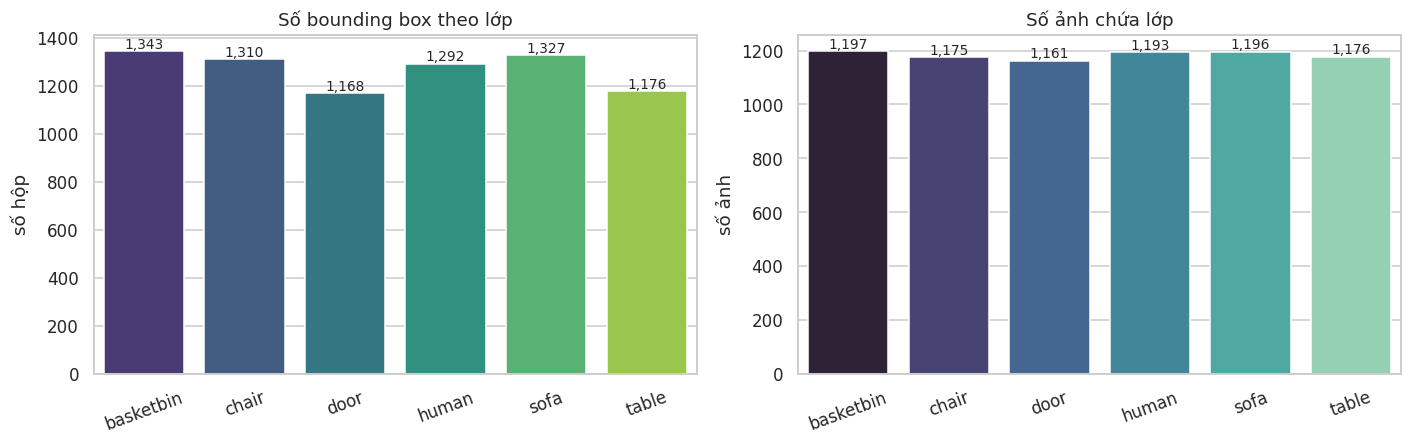

Lớp nhiều nhất : basketbin (1,343 hộp)
Lớp ít nhất    : door (1,168 hộp)
Tỉ số mất cân bằng (max/min) = 1.15x


In [14]:
# =============================================================================
# BIỂU ĐỒ 1 - TẦN SUẤT LỚP (số hộp và số ảnh chứa lớp đó)
# =============================================================================
cls_box = boxes_df["class"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int)
cls_img = (boxes_df.groupby("class")["image"].nunique()
           .reindex(CLASS_NAMES).fillna(0).astype(int))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=cls_box.index, y=cls_box.values, ax=axes[0], palette="viridis")
axes[0].set_title("Số bounding box theo lớp"); axes[0].set_xlabel(""); axes[0].set_ylabel("số hộp")
for i, v in enumerate(cls_box.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

sns.barplot(x=cls_img.index, y=cls_img.values, ax=axes[1], palette="mako")
axes[1].set_title("Số ảnh chứa lớp"); axes[1].set_xlabel(""); axes[1].set_ylabel("số ảnh")
for i, v in enumerate(cls_img.values):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

imb = cls_box.max() / max(1, cls_box.min())
print(f"Lớp nhiều nhất : {cls_box.idxmax()} ({cls_box.max():,} hộp)")
print(f"Lớp ít nhất    : {cls_box.idxmin()} ({cls_box.min():,} hộp)")
print(f"Tỉ số mất cân bằng (max/min) = {imb:.2f}x")

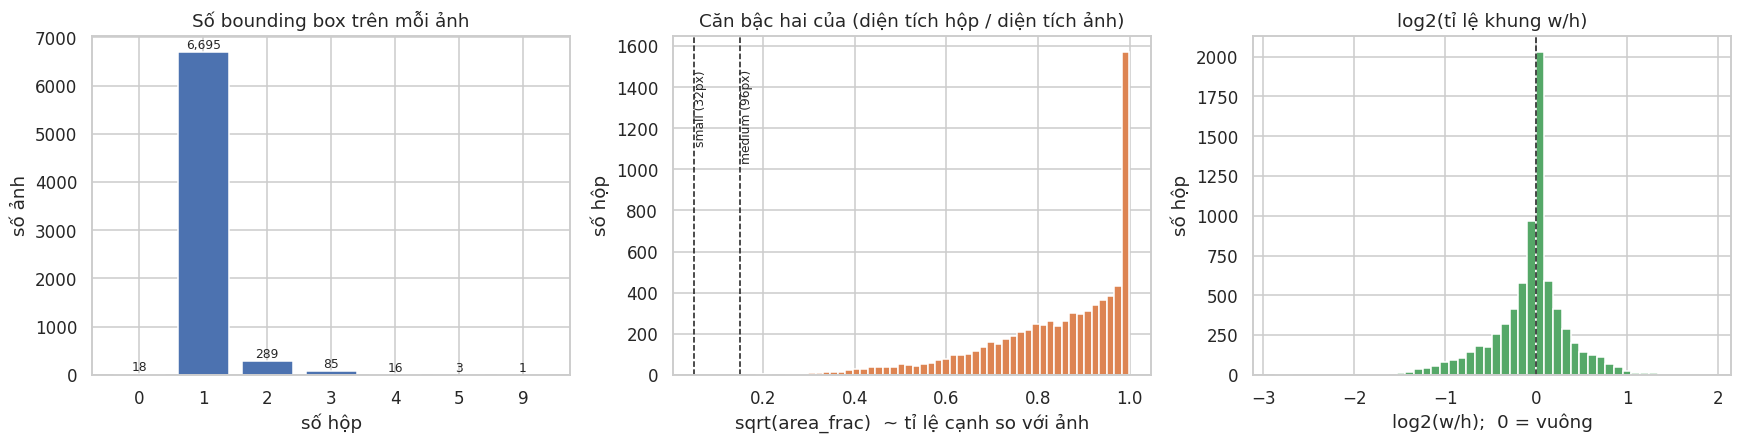

Tỉ lệ vật thể NHỎ   (area < 32^2 px)      : 0.00%
Tỉ lệ vật thể VỪA   (32^2 <= area < 96^2) : 0.00%
Tỉ lệ vật thể LỚN   (area >= 96^2 px)     : 100.00%
Trung vị area_frac  : 0.773 (hộp trung vị chiếm 77.3% diện tích ảnh)


In [15]:
# =============================================================================
# BIỂU ĐỒ 2 - SỐ HỘP / ẢNH,  DIỆN TÍCH HỘP,  TỈ LỆ KHUNG
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

vc = images_df["n_boxes"].value_counts().sort_index()
axes[0].bar(vc.index.astype(str), vc.values, color="#4c72b0")
axes[0].set_title("Số bounding box trên mỗi ảnh")
axes[0].set_xlabel("số hộp"); axes[0].set_ylabel("số ảnh")
for i, v in enumerate(vc.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)

axes[1].hist(np.sqrt(boxes_df["area_frac"]), bins=50, color="#dd8452")
axes[1].set_title("Căn bậc hai của (diện tích hộp / diện tích ảnh)")
axes[1].set_xlabel("sqrt(area_frac)  ~ tỉ lệ cạnh so với ảnh"); axes[1].set_ylabel("số hộp")
# Ngưỡng COCO: small < 32px, medium < 96px (trên ảnh 640x640)
for thr, lab in [(32 / IMG_SIZE, "small (32px)"), (96 / IMG_SIZE, "medium (96px)")]:
    axes[1].axvline(thr, ls="--", c="k", lw=1)
    axes[1].text(thr, axes[1].get_ylim()[1] * 0.9, lab, rotation=90, fontsize=8, va="top")

axes[2].hist(np.log2(boxes_df["aspect"].clip(0.05, 20)), bins=50, color="#55a868")
axes[2].set_title("log2(tỉ lệ khung w/h)")
axes[2].set_xlabel("log2(w/h);  0 = vuông"); axes[2].set_ylabel("số hộp")
axes[2].axvline(0, ls="--", c="k", lw=1)
plt.tight_layout(); plt.show()

# Phân loại kích thước theo chuẩn COCO (quy đổi về ảnh gốc 640x640)
small = (boxes_df["area"] < 32 ** 2).mean()
medium = ((boxes_df["area"] >= 32 ** 2) & (boxes_df["area"] < 96 ** 2)).mean()
large = (boxes_df["area"] >= 96 ** 2).mean()
print(f"Tỉ lệ vật thể NHỎ   (area < 32^2 px)      : {small:.2%}")
print(f"Tỉ lệ vật thể VỪA   (32^2 <= area < 96^2) : {medium:.2%}")
print(f"Tỉ lệ vật thể LỚN   (area >= 96^2 px)     : {large:.2%}")
print(f"Trung vị area_frac  : {boxes_df['area_frac'].median():.3f} "
      f"(hộp trung vị chiếm {boxes_df['area_frac'].median():.1%} diện tích ảnh)")

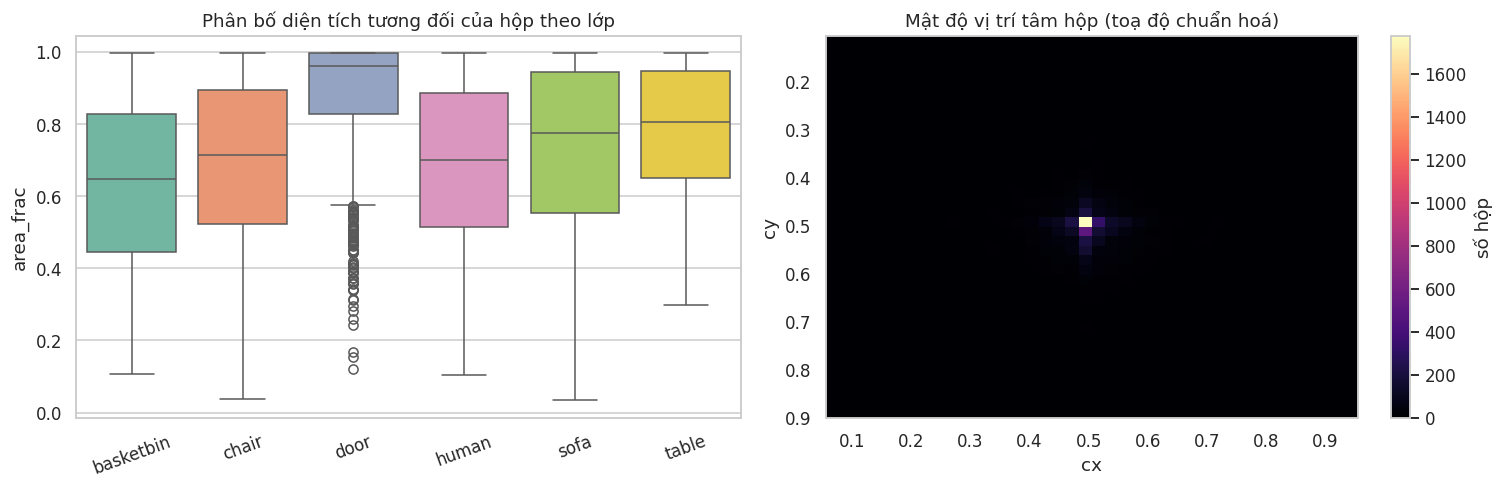

In [16]:
# =============================================================================
# BIỂU ĐỒ 3 - DIỆN TÍCH HỘP THEO TỪNG LỚP + BẢN ĐỒ NHIỆT VỊ TRÍ TÂM HỘP
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.boxplot(data=boxes_df, x="class", y="area_frac", order=CLASS_NAMES,
            ax=axes[0], palette="Set2")
axes[0].set_title("Phân bố diện tích tương đối của hộp theo lớp")
axes[0].set_xlabel(""); axes[0].set_ylabel("area_frac"); axes[0].tick_params(axis="x", rotation=20)

h = axes[1].hist2d(boxes_df["cx"], boxes_df["cy"], bins=40, cmap="magma")
axes[1].invert_yaxis()
axes[1].set_title("Mật độ vị trí tâm hộp (toạ độ chuẩn hoá)")
axes[1].set_xlabel("cx"); axes[1].set_ylabel("cy")
fig.colorbar(h[3], ax=axes[1], label="số hộp")
plt.tight_layout(); plt.show()

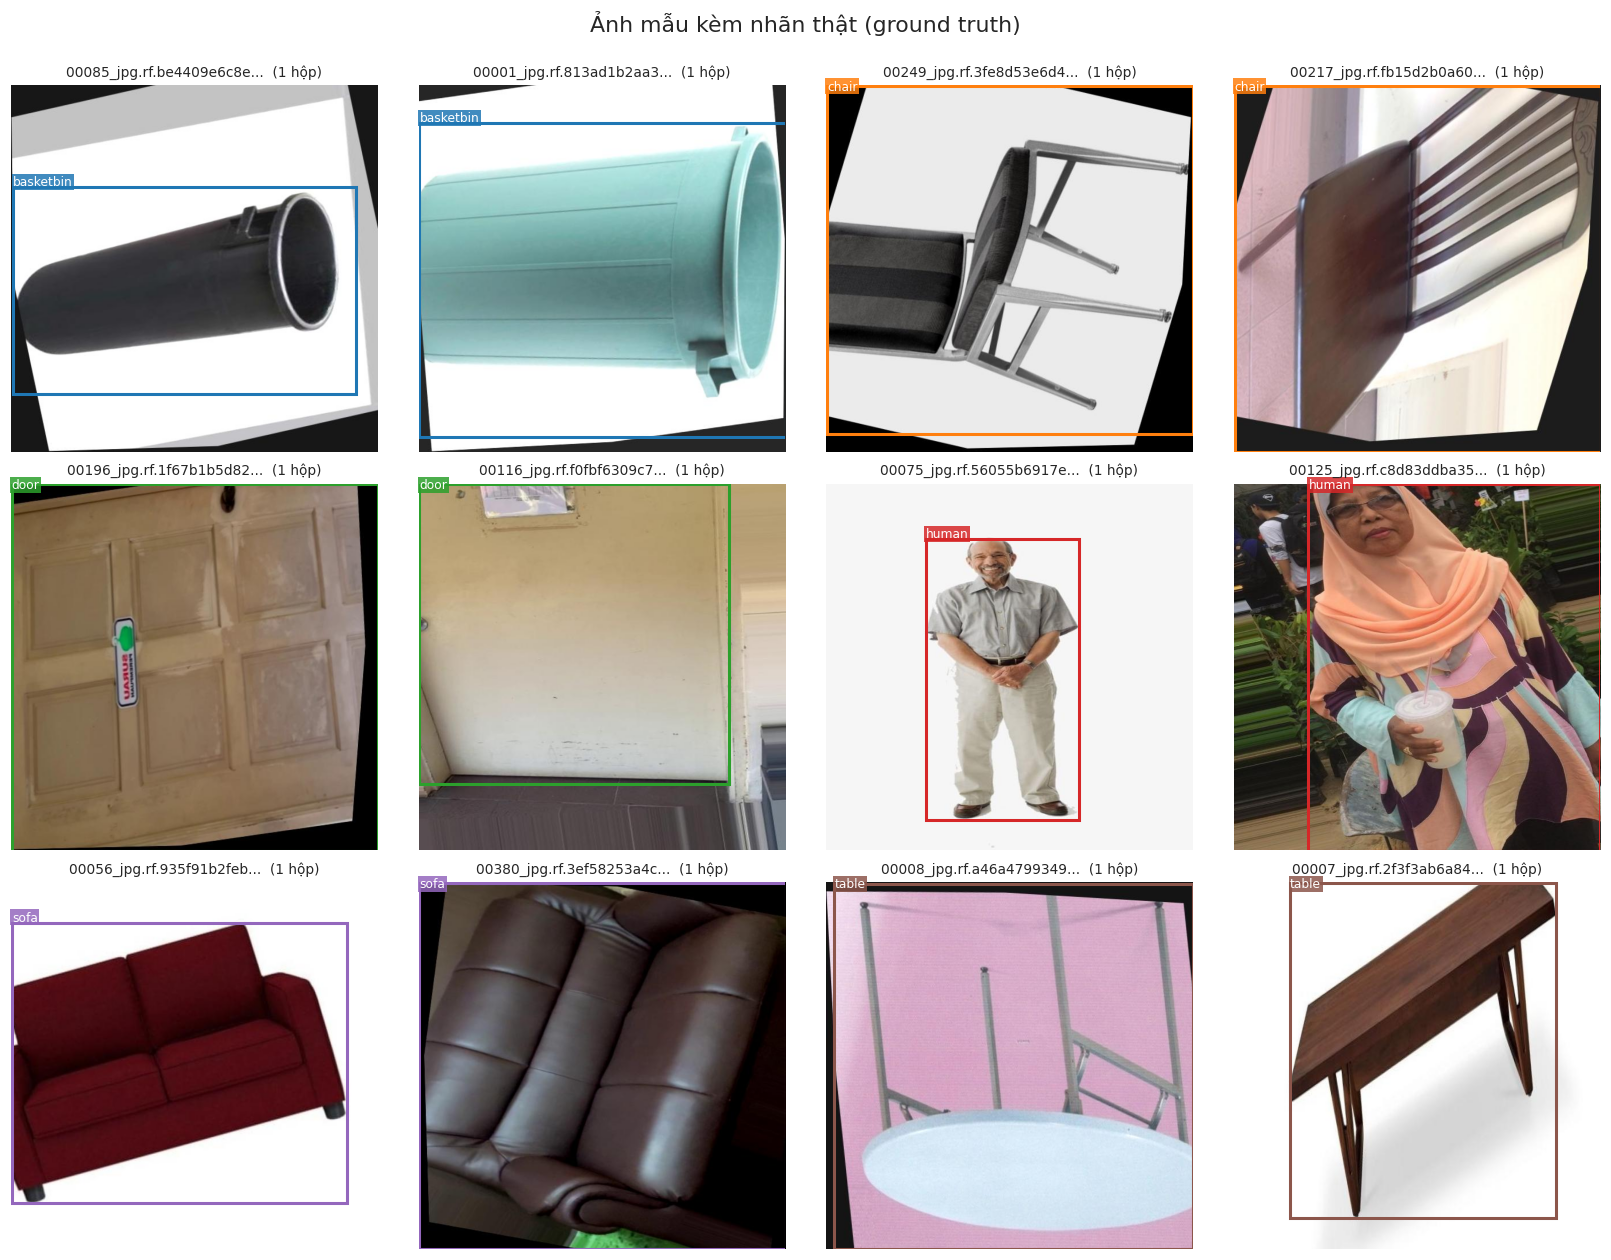

In [17]:
# =============================================================================
# LƯỚI ẢNH MẪU CÓ VẼ HỘP + NHÃN
# =============================================================================
PALETTE = plt.get_cmap("tab10")
CLASS_COLOR = {c: PALETTE(i % 10) for i, c in enumerate(CLASS_NAMES)}


def draw_boxes_on_ax(ax, img, boxes, title="", show_score=False):
    # boxes: list các tuple (class_name, x1, y1, x2, y2[, score])
    ax.imshow(img)
    for b in boxes:
        cname, x1, y1, x2, y2 = b[0], b[1], b[2], b[3], b[4]
        color = CLASS_COLOR.get(cname, (1, 0, 0, 1))
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, lw=2, edgecolor=color))
        lab = cname if not (show_score and len(b) > 5) else f"{cname} {b[5]:.2f}"
        ax.text(x1, max(y1 - 3, 8), lab, fontsize=8, color="white",
                bbox=dict(facecolor=color, alpha=0.85, pad=1, edgecolor="none"))
    ax.set_title(title, fontsize=9)
    ax.axis("off")


set_seed(SEED)
# Ưu tiên chọn mỗi lớp vài ảnh để lưới ảnh mẫu phủ đủ 6 lớp
by_class = defaultdict(list)
for r in RECORDS:
    for c in {b[0] for b in r["boxes"]}:
        by_class[c].append(r)

samples = []
for c in CLASS_NAMES:
    samples += random.sample(by_class[c], min(2, len(by_class[c])))
samples = samples[:12]

fig, axes = plt.subplots(3, 4, figsize=(15, 11.5))
for ax, r in zip(axes.ravel(), samples):
    img = Image.open(r["image_path"]).convert("RGB")
    draw_boxes_on_ax(ax, img, r["boxes"],
                     title=f"{Path(r['image_path']).name[:24]}...  ({len(r['boxes'])} hộp)")
for ax in axes.ravel()[len(samples):]:
    ax.axis("off")
plt.suptitle("Ảnh mẫu kèm nhãn thật (ground truth)", y=0.995)
plt.tight_layout(); plt.show()

In [18]:
# =============================================================================
# TỰ SINH NHẬN XÉT EDA TỪ SỐ LIỆU THỰC TẾ (không có số liệu bịa)
# =============================================================================
mean_bpi = len(boxes_df) / max(1, len(images_df))
pct_single = (images_df["n_boxes"] == 1).mean()
pct_multi = (images_df["n_boxes"] >= 2).mean()
pct_zero = (images_df["n_boxes"] == 0).mean()
pct_multiclass = (images_df["n_classes"] >= 2).mean()
med_af = boxes_df["area_frac"].median()
q90_af = boxes_df["area_frac"].quantile(0.90)
asp_med = boxes_df["aspect"].median()

print("NHẬN XÉT TỰ ĐỘNG TỪ EDA")
print("=" * 74)
print(f"1) Quy mô: {len(images_df):,} ảnh / {len(boxes_df):,} hộp -> {mean_bpi:.2f} hộp/ảnh.")
print(f"   {pct_single:.1%} số ảnh chỉ có ĐÚNG 1 vật thể, {pct_multi:.1%} có từ 2 vật thể trở lên,")
print(f"   {pct_zero:.1%} số ảnh không có nhãn nào (ảnh nền / vật thể bị loại khi gán nhãn).")
print(f"   Chỉ {pct_multiclass:.1%} số ảnh chứa từ 2 lớp khác nhau -> bài toán thiên về")
print( "   'một vật thể chính trên mỗi ảnh' hơn là cảnh lộn xộn nhiều vật thể.")
print(f"2) Cân bằng lớp: lớp nhiều nhất '{cls_box.idxmax()}' ({cls_box.max():,} hộp) so với")
print(f"   lớp ít nhất '{cls_box.idxmin()}' ({cls_box.min():,} hộp) -> tỉ số {imb:.2f}x.")
print( "   " + ("Mất cân bằng KHÔNG đáng kể (<1.5x) -> chưa cần lấy mẫu cân bằng lớp."
               if imb < 1.5 else
               "Có mất cân bằng -> nên cân nhắc focal loss / lấy mẫu theo trọng số lớp."))
print(f"3) Kích thước vật thể: nhỏ {small:.1%} | vừa {medium:.1%} | lớn {large:.1%}.")
print(f"   Trung vị hộp chiếm {med_af:.1%} diện tích ảnh, phân vị 90 là {q90_af:.1%}.")
print( "   " + ("Vật thể rất LỚN, chiếm phần lớn khung hình -> lợi thế của FPN đa tỉ lệ sẽ"
               " ít rõ rệt; mô hình nhẹ vẫn có thể đạt mAP cao."
               if med_af > 0.15 else
               "Có tỉ trọng vật thể nhỏ đáng kể -> FPN / độ phân giải cao sẽ tạo khác biệt lớn."))
print(f"4) Tỉ lệ khung trung vị w/h = {asp_med:.2f} -> "
      f"{'hộp thiên về nằm ngang' if asp_med > 1.15 else ('hộp thiên về dọc' if asp_med < 0.87 else 'hộp gần vuông')}.")
print( "   Thông tin này được dùng lại ở Phần 11 để phân cụm k-means chọn anchor.")
print("=" * 74)

NHẬN XÉT TỰ ĐỘNG TỪ EDA
1) Quy mô: 7,107 ảnh / 7,616 hộp -> 1.07 hộp/ảnh.
   94.2% số ảnh chỉ có ĐÚNG 1 vật thể, 5.5% có từ 2 vật thể trở lên,
   0.3% số ảnh không có nhãn nào (ảnh nền / vật thể bị loại khi gán nhãn).
   Chỉ 0.1% số ảnh chứa từ 2 lớp khác nhau -> bài toán thiên về
   'một vật thể chính trên mỗi ảnh' hơn là cảnh lộn xộn nhiều vật thể.
2) Cân bằng lớp: lớp nhiều nhất 'basketbin' (1,343 hộp) so với
   lớp ít nhất 'door' (1,168 hộp) -> tỉ số 1.15x.
   Mất cân bằng KHÔNG đáng kể (<1.5x) -> chưa cần lấy mẫu cân bằng lớp.
3) Kích thước vật thể: nhỏ 0.0% | vừa 0.0% | lớn 100.0%.
   Trung vị hộp chiếm 77.3% diện tích ảnh, phân vị 90 là 99.7%.
   Vật thể rất LỚN, chiếm phần lớn khung hình -> lợi thế của FPN đa tỉ lệ sẽ ít rõ rệt; mô hình nhẹ vẫn có thể đạt mAP cao.
4) Tỉ lệ khung trung vị w/h = 1.00 -> hộp gần vuông.
   Thông tin này được dùng lại ở Phần 11 để phân cụm k-means chọn anchor.


### Nhận xét EDA

Các con số cụ thể được in ở ô ngay trên (sinh tự động từ dữ liệu thật). Những điểm cần lưu ý
khi chọn và đánh giá mô hình:

* **Mật độ vật thể rất thấp.** Đa số ảnh chỉ có **một** vật thể được gán nhãn, rất ít ảnh chứa
  nhiều lớp. Đây là hệ quả của việc bộ dữ liệu được xây từ *MyNursingHome* — vốn là bộ
  **phân loại ảnh** (mỗi ảnh một đối tượng chính), sau đó mới được gán hộp bằng Roboflow.
  ⇒ Bài toán gần với "định vị vật thể chính" hơn là phát hiện đa vật thể trong cảnh lộn xộn.
  Hệ quả thực tế: **mAP sẽ cao một cách "dễ dãi"** so với các benchmark như COCO, và
  **khoảng cách giữa các mô hình sẽ bị nén lại**.

* **Vật thể chiếm tỉ lệ lớn trong khung hình.** Hộp trung vị chiếm một phần đáng kể diện tích
  ảnh (xem số liệu in ở trên). Vì vậy **ưu thế của FPN đa tỉ lệ và của độ phân giải cao bị giảm**;
  ngược lại một mô hình nhẹ như SSDlite-MobileNetV3 (đầu vào 320×320) vẫn có cơ hội cạnh tranh
  — điều này sẽ được kiểm chứng ở bảng kết quả.

* **Mất cân bằng lớp ở mức nhẹ.** Tác giả chọn ~500 ảnh/lớp nên số hộp giữa các lớp khá đều.
  Do đó **focal loss / lấy mẫu cân bằng lớp không phải là điểm nghẽn chính** ở bộ dữ liệu này —
  một chi tiết quan trọng khi diễn giải chênh lệch giữa RetinaNet (focal loss) và SSD
  (hard negative mining) ở phần đánh giá.

* **Tồn tại ảnh không có nhãn** (ảnh nền). Chúng sẽ được **loại khỏi tập huấn luyện** của các mô
  hình torchvision (một số phiên bản báo lỗi với target rỗng), nhưng **vẫn giữ lại khi đánh giá**
  vì detection sai trên ảnh nền chính là *false positive* — phải bị trừ điểm.

* **Rủi ro rò rỉ do tăng cường.** Ảnh trong `train/` là các bản tăng cường (3 phiên bản/ảnh gốc),
  còn `valid/`, `test/` là ảnh chưa tăng cường. Khi chia lại, ta bắt buộc phải nhóm theo id ảnh gốc
  — nội dung của Phần 5.

---
# Phần 5 — Chia tập train / val / test

**Yêu cầu:** chia 70 / 15 / 15, có seed, phân tầng theo lớp.

**Hai cạm bẫy phải xử lý ở bộ dữ liệu này:**

1. **Rò rỉ do tăng cường.** `00123_jpg.rf.<hash1>.jpg` và `00123_jpg.rf.<hash2>.jpg` là *cùng một
   ảnh gốc*. Chia ngẫu nhiên theo ảnh sẽ đẩy bản này vào train, bản kia vào test ⇒ mô hình gần như
   "đã nhìn thấy" ảnh test ⇒ mAP ảo. → **Chia theo `group` (id ảnh gốc), không theo từng ảnh.**
2. **Trùng lặp trong tập đánh giá.** Nếu để cả 3 bản tăng cường của một ảnh gốc trong tập test,
   ảnh đó bị tính trọng số gấp 3. → **Với val/test chỉ giữ 1 ảnh đại diện cho mỗi nhóm.**

Phân tầng (*stratify*) được thực hiện theo **lớp trội** của mỗi nhóm — hợp lý vì phần lớn ảnh
chỉ chứa một lớp.

Đặt `SPLIT_MODE = "official"` ở ô cấu hình nếu muốn dùng đúng split gốc của tác giả để đối chiếu.

In [19]:
# =============================================================================
# CHIA DỮ LIỆU: THEO NHÓM ẢNH GỐC + PHÂN TẦNG THEO LỚP TRỘI
# =============================================================================
def dominant_class(rec):
    c = Counter(b[0] for b in rec["boxes"]).most_common(1)
    return c[0][0] if c else "_background"


def grouped_stratified_split(records, ratio=SPLIT_RATIO, seed=SEED):
    # 1) gom ảnh theo nhóm (id ảnh gốc)
    groups = defaultdict(list)
    for r in records:
        groups[r["group"]].append(r)
    # 2) gán nhãn phân tầng cho mỗi nhóm
    gclass = {g: Counter(dominant_class(r) for r in rs).most_common(1)[0][0]
              for g, rs in groups.items()}
    by_cls = defaultdict(list)
    for g, c in gclass.items():
        by_cls[c].append(g)
    # 3) trong từng lớp, xáo trộn có seed rồi cắt theo tỉ lệ
    rng = random.Random(seed)
    tr_g, va_g, te_g = [], [], []
    for c, gs in sorted(by_cls.items()):
        gs = sorted(gs); rng.shuffle(gs)
        n = len(gs)
        n_tr = int(round(ratio[0] * n))
        n_va = int(round(ratio[1] * n))
        n_tr = min(n_tr, n)
        n_va = min(n_va, n - n_tr)
        tr_g += gs[:n_tr]; va_g += gs[n_tr:n_tr + n_va]; te_g += gs[n_tr + n_va:]
    # 4) train: lấy TẤT CẢ ảnh của nhóm (tận dụng ảnh tăng cường)
    #    val/test: chỉ lấy 1 ảnh ĐẠI DIỆN mỗi nhóm (tránh đếm trùng khi đánh giá)
    def expand(gs, keep_all):
        out = []
        for g in sorted(gs):
            rs = sorted(groups[g], key=lambda r: r["image_path"])
            out += rs if keep_all else rs[:1]
        return out

    return expand(tr_g, True), expand(va_g, False), expand(te_g, False)


if SPLIT_MODE == "official":
    train_recs = [r for r in RECORDS if r["split_official"] == "train"]
    val_recs   = [r for r in RECORDS if r["split_official"] == "val"]
    test_recs  = [r for r in RECORDS if r["split_official"] == "test"]
    print("Dùng split GỐC của tác giả.")
else:
    train_recs, val_recs, test_recs = grouped_stratified_split(RECORDS)
    print(f"Chia lại {SPLIT_RATIO} theo NHÓM ảnh gốc + phân tầng theo lớp trội (seed={SEED}).")

# Kiểm tra không có nhóm nào nằm ở hai tập khác nhau (chống rò rỉ)
g_tr = {r["group"] for r in train_recs}
g_va = {r["group"] for r in val_recs}
g_te = {r["group"] for r in test_recs}
leak = (g_tr & g_va) | (g_tr & g_te) | (g_va & g_te)
print(f"Số nhóm bị chồng lấn giữa các tập: {len(leak)}  ->",
      "KHÔNG rò rỉ." if not leak else "CẢNH BÁO: có rò rỉ!")

# QUICK_RUN: lấy mẫu con có seed để chạy thử nhanh
def subsample(recs, k, seed=SEED):
    if k is None or k >= len(recs):
        return recs
    return random.Random(seed).sample(recs, k)


if QUICK_RUN:
    train_recs = subsample(train_recs, MAX_TRAIN_IMG)
    val_recs   = subsample(val_recs,   MAX_VAL_IMG)
    test_recs  = subsample(test_recs,  MAX_TEST_IMG)
    print(f"[QUICK_RUN] Lấy mẫu con -> train={len(train_recs)}, "
          f"val={len(val_recs)}, test={len(test_recs)}")

SPLITS = {"train": train_recs, "val": val_recs, "test": test_recs}

rows = []
for name, recs in SPLITS.items():
    cnt = Counter(b[0] for r in recs for b in r["boxes"])
    row = {"split": name, "ảnh": len(recs), "nhóm": len({r["group"] for r in recs}),
           "hộp": sum(len(r["boxes"]) for r in recs)}
    row.update({c: cnt.get(c, 0) for c in CLASS_NAMES})
    rows.append(row)
split_df = pd.DataFrame(rows)
display(split_df)

# Tỉ lệ lớp giữa các split có giống nhau không? (kiểm chứng phân tầng)
prop = split_df.set_index("split")[CLASS_NAMES]
prop = prop.div(prop.sum(axis=1), axis=0).round(3)
print("Tỉ lệ hộp theo lớp trong từng split (phân tầng tốt <=> các dòng gần giống nhau):")
display(prop)

Chia lại (0.7, 0.15, 0.15) theo NHÓM ảnh gốc + phân tầng theo lớp trội (seed=42).
Số nhóm bị chồng lấn giữa các tập: 0  -> KHÔNG rò rỉ.
[QUICK_RUN] Lấy mẫu con -> train=1200, val=200, test=200


,split,ảnh,nhóm,hộp,basketbin,chair,door,human,sofa,table
0,train,1200,959,1276,224,209,217,196,227,203
1,val,200,200,213,37,36,26,39,39,36
2,test,200,200,214,40,34,26,36,42,36


Tỉ lệ hộp theo lớp trong từng split (phân tầng tốt <=> các dòng gần giống nhau):


,basketbin,chair,door,human,sofa,table
split,,,,,,
train,0.176,0.164,0.170,0.154,0.178,0.159
val,0.174,0.169,0.122,0.183,0.183,0.169
test,0.187,0.159,0.121,0.168,0.196,0.168


---
# Phần 6 — Chuyển đổi sang định dạng YOLO và COCO

Hai họ mô hình cần hai định dạng khác nhau, nhưng **phải cùng dữ liệu, cùng split**:

* **YOLO** (cho Ultralytics YOLOv8): cây thư mục `images/{train,val,test}` +
  `labels/{train,val,test}` với nhãn chuẩn hoá `cls cx cy w h`, kèm `data.yaml`
  dùng **đường dẫn tuyệt đối `/content/...`**.
* **COCO JSON** (cho torchvision + `pycocotools`): `images` / `annotations` / `categories`,
  `category_id` chạy từ **1** (0 dành cho *background* theo quy ước torchvision).

Để tiết kiệm đĩa Colab, ảnh được **hard-link** thay vì sao chép (nếu hệ thống không cho phép
thì tự động chuyển sang copy).

In [20]:
# =============================================================================
# XUẤT SANG ĐỊNH DẠNG YOLO  (+ data.yaml đường dẫn tuyệt đối)
# =============================================================================
YOLO_ROOT = WORK_DIR / "yolo_ds"
YOLO_YAML = YOLO_ROOT / "data.yaml"


def _link_or_copy(src: Path, dst: Path):
    if dst.exists():
        return
    try:
        os.link(src, dst)          # hard-link: gần như không tốn thêm đĩa
    except OSError:
        shutil.copy2(src, dst)


def export_yolo(splits: dict, root: Path, class_names: list, force: bool = False):
    if force and root.exists():
        shutil.rmtree(root)
    for sp in splits:
        (root / "images" / sp).mkdir(parents=True, exist_ok=True)
        (root / "labels" / sp).mkdir(parents=True, exist_ok=True)

    c2i = {c: i for i, c in enumerate(class_names)}
    for sp, recs in splits.items():
        for r in tqdm(recs, desc=f"xuất YOLO [{sp}]", leave=False):
            src = Path(r["image_path"])
            dst = root / "images" / sp / src.name
            _link_or_copy(src, dst)
            W, H = r["width"], r["height"]
            lines = []
            for (cname, x1, y1, x2, y2) in r["boxes"]:
                cx = (x1 + x2) / 2 / W
                cy = (y1 + y2) / 2 / H
                bw = (x2 - x1) / W
                bh = (y2 - y1) / H
                lines.append(f"{c2i[cname]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
            # ảnh nền -> file nhãn RỖNG (Ultralytics coi là negative sample, hợp lệ)
            (root / "labels" / sp / (src.stem + ".txt")).write_text("\n".join(lines))

    yaml_text = (
        f"# Sinh tự động cho Homework 2 - {len(class_names)} lớp\n"
        f"path: {root.as_posix()}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"test: images/test\n"
        f"nc: {len(class_names)}\n"
        f"names:\n" + "".join(f"  {i}: {c}\n" for i, c in enumerate(class_names))
    )
    (root / "data.yaml").write_text(yaml_text)
    return root / "data.yaml"


YOLO_YAML = export_yolo(SPLITS, YOLO_ROOT, CLASS_NAMES, force=True)
print("data.yaml =", YOLO_YAML)
print("-" * 70)
print(YOLO_YAML.read_text())
for sp in SPLITS:
    n_i = len(list((YOLO_ROOT / "images" / sp).glob("*")))
    n_l = len(list((YOLO_ROOT / "labels" / sp).glob("*.txt")))
    print(f"  {sp:5s}: {n_i:5d} ảnh / {n_l:5d} nhãn")

xuất YOLO [train]:   0%|          | 0/1200 [00:00<?, ?it/s]

xuất YOLO [val]:   0%|          | 0/200 [00:00<?, ?it/s]

xuất YOLO [test]:   0%|          | 0/200 [00:00<?, ?it/s]

data.yaml = /content/indoor_det/work/yolo_ds/data.yaml
----------------------------------------------------------------------
# Sinh tự động cho Homework 2 - 6 lớp
path: /content/indoor_det/work/yolo_ds
train: images/train
val: images/val
test: images/test
nc: 6
names:
  0: basketbin
  1: chair
  2: door
  3: human
  4: sofa
  5: table

  train:  1200 ảnh /  1200 nhãn
  val  :   200 ảnh /   200 nhãn
  test :   200 ảnh /   200 nhãn


In [21]:
# =============================================================================
# XUẤT SANG COCO JSON  (category_id bắt đầu từ 1)
# =============================================================================
COCO_DIR = WORK_DIR / "coco"
COCO_DIR.mkdir(parents=True, exist_ok=True)


def build_coco_dict(records: list, class_names: list) -> dict:
    # image_id = chỉ số của ảnh trong danh sách records -> mọi nơi khác dùng lại thứ tự này
    images, annotations = [], []
    ann_id = 1
    c2i = {c: i for i, c in enumerate(class_names)}
    for img_id, r in enumerate(records):
        images.append({"id": img_id,
                       "file_name": Path(r["image_path"]).name,
                       "width": r["width"], "height": r["height"]})
        for (cname, x1, y1, x2, y2) in r["boxes"]:
            w, h = x2 - x1, y2 - y1
            annotations.append({
                "id": ann_id, "image_id": img_id,
                "category_id": c2i[cname] + 1,          # 1..K
                "bbox": [float(x1), float(y1), float(w), float(h)],
                "area": float(w * h), "iscrowd": 0, "segmentation": [],
            })
            ann_id += 1
    categories = [{"id": i + 1, "name": c, "supercategory": "indoor"}
                  for i, c in enumerate(class_names)]
    return {"info": {"description": "SyntheticIndoorObjectDetectionDataset (HW2)",
                     "version": "2", "licence": "CC BY 4.0"},
            "images": images, "annotations": annotations, "categories": categories}


COCO_GT = {}
for sp, recs in SPLITS.items():
    d = build_coco_dict(recs, CLASS_NAMES)
    COCO_GT[sp] = d
    out = COCO_DIR / f"instances_{sp}.json"
    out.write_text(json.dumps(d))
    print(f"{sp:5s}: {len(d['images']):5d} ảnh, {len(d['annotations']):6d} annotation -> {out.name}")

# Danh sách ảnh test + image_id dùng CHUNG cho MỌI mô hình khi đánh giá
TEST_PATHS = [r["image_path"] for r in SPLITS["test"]]
TEST_IMAGE_IDS = list(range(len(TEST_PATHS)))
print(f"\nTập test dùng chung để chấm điểm: {len(TEST_PATHS)} ảnh "
      f"({sum(len(r['boxes']) for r in SPLITS['test'])} hộp thật).")

train:  1200 ảnh,   1276 annotation -> instances_train.json
val  :   200 ảnh,    213 annotation -> instances_val.json
test :   200 ảnh,    214 annotation -> instances_test.json

Tập test dùng chung để chấm điểm: 200 ảnh (214 hộp thật).


---
# Phần 7 — Các mô hình được so sánh

Ta so sánh **5 mô hình thuộc 3 họ kiến trúc** khác nhau, tất cả đều khởi tạo từ trọng số
**tiền huấn luyện trên COCO** rồi tinh chỉnh (fine-tune) trên **cùng một split**:

| Mô hình | Họ | Backbone / Neck | Cách sinh dự đoán | Hàm mất mát phân loại | Ghi chú |
|---|---|---|---|---|---|
| **YOLOv8n** | 1-stage, **anchor-free** | CSPDarknet + PAN-FPN | dày đặc, TaskAlignedAssigner | BCE + DFL/CIoU | ~3.2 M tham số, nhanh nhất |
| **YOLOv8s** | 1-stage, **anchor-free** | CSPDarknet (rộng hơn) + PAN-FPN | như trên | như trên | ~11 M tham số |
| **Faster R-CNN R50-FPN** | **2-stage**, anchor-based | ResNet-50 + FPN | RPN → RoIAlign → head | CE (có lấy mẫu 1:3 pos/neg) | chính xác, chậm |
| **RetinaNet R50-FPN v2** | 1-stage, anchor-based | ResNet-50 + FPN | head dày đặc | **Focal Loss** | sinh ra để trị mất cân bằng nền/vật |
| **SSDlite-MobileNetV3** | 1-stage, anchor-based | MobileNetV3-Large | head dày đặc đa tỉ lệ | CE + **hard negative mining** | siêu nhẹ, đầu vào 320×320 |

**Các yếu tố được giữ giống nhau để so sánh công bằng:**

* cùng tập train / val / test (cùng seed, cùng danh sách file);
* cùng độ phân giải suy luận **640×640** (riêng SSDlite bị *ràng buộc kiến trúc* ở 320×320 —
  điều này được nêu rõ và tính đến khi diễn giải kết quả);
* cùng `conf = 0.001`, `NMS IoU = 0.6`, `max_det = 100` khi sinh detection;
* **cùng một trình chấm điểm `COCOeval` duy nhất** (Phần 8);
* cùng thiết bị khi đo tốc độ.

**Khác nhau (không thể tránh):** thuật toán tối ưu và lịch học của Ultralytics là pipeline
riêng của họ (kèm mosaic augmentation mặc định), còn ba mô hình torchvision dùng vòng lặp
huấn luyện tự viết (SGD + warmup + cosine). Đây là điểm cần lưu ý khi diễn giải: ta đang so
sánh **hai pipeline huấn luyện thực dụng**, không phải chỉ riêng kiến trúc mạng.

In [22]:
# =============================================================================
# DATASET / DATALOADER CHO CÁC MÔ HÌNH TORCHVISION
# =============================================================================
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision.models import detection as tvdet
from torchvision.models.detection import _utils as det_utils
from functools import partial


def load_image_tensor(path) -> torch.Tensor:
    # torchvision detection nhận tensor float [0,1], CHW; việc resize/chuẩn hoá do
    # GeneralizedRCNNTransform bên trong mô hình tự lo.
    img = Image.open(path).convert("RGB")
    arr = np.asarray(img, dtype=np.uint8)
    return torch.from_numpy(arr).permute(2, 0, 1).float().div_(255.0)


class DetectionDataset(Dataset):
    def __init__(self, records, train=False, class_to_id=None):
        # Khi train: bỏ ảnh không có hộp nào (một số mô hình torchvision lỗi với target rỗng).
        self.recs = [r for r in records if (len(r["boxes"]) > 0 or not train)]
        self.train = train
        self.c2i = class_to_id or CLASS_TO_ID

    def __len__(self):
        return len(self.recs)

    def __getitem__(self, i):
        r = self.recs[i]
        img = load_image_tensor(r["image_path"])
        boxes = np.array([[b[1], b[2], b[3], b[4]] for b in r["boxes"]],
                         dtype=np.float32).reshape(-1, 4)
        labels = np.array([self.c2i[b[0]] + 1 for b in r["boxes"]], dtype=np.int64)  # 0 = nền

        if self.train and random.random() < 0.5:            # lật ngang (đồng bộ hộp)
            img = torch.flip(img, dims=[2])
            W = img.shape[2]
            if len(boxes):
                x1 = boxes[:, 0].copy()
                boxes[:, 0] = W - boxes[:, 2]
                boxes[:, 2] = W - x1
        if self.train:                                      # jitter độ sáng nhẹ
            img = img.mul(random.uniform(0.85, 1.15)).clamp_(0.0, 1.0)

        boxes_t = torch.from_numpy(boxes)
        target = {
            "boxes": boxes_t,
            "labels": torch.from_numpy(labels),
            "image_id": torch.tensor([i]),
            "area": (boxes_t[:, 2] - boxes_t[:, 0]) * (boxes_t[:, 3] - boxes_t[:, 1])
                    if len(boxes) else torch.zeros(0),
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
        }
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))


ds_train = DetectionDataset(SPLITS["train"], train=True)
ds_val   = DetectionDataset(SPLITS["val"],   train=False)
print(f"Dataset torchvision -> train {len(ds_train)} ảnh (đã bỏ ảnh không nhãn), "
      f"val {len(ds_val)} ảnh")

_img, _tgt = ds_train[0]
print("Kiểm tra 1 mẫu: ảnh", tuple(_img.shape), _img.dtype,
      f"[{_img.min():.2f}, {_img.max():.2f}] | boxes", tuple(_tgt['boxes'].shape),
      "| labels", _tgt["labels"].tolist())

Dataset torchvision -> train 1196 ảnh (đã bỏ ảnh không nhãn), val 200 ảnh
Kiểm tra 1 mẫu: ảnh (3, 640, 640) torch.float32 [0.00, 0.92] | boxes (1, 4) | labels [2]


In [23]:
# =============================================================================
# HÀM DỰNG MÔ HÌNH TORCHVISION (thay head để khớp số lớp của ta)
# =============================================================================
def build_fasterrcnn(num_classes_bg: int):
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    m = tvdet.fasterrcnn_resnet50_fpn(
        weights=tvdet.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    in_f = m.roi_heads.box_predictor.cls_score.in_features
    m.roi_heads.box_predictor = FastRCNNPredictor(in_f, num_classes_bg)
    # Ép về cùng độ phân giải 640 với YOLO (mặc định là 800/1333 -> tốn VRAM và không công bằng)
    m.transform.min_size = (IMG_SIZE,)
    m.transform.max_size = IMG_SIZE
    m.roi_heads.score_thresh = CONF_EVAL
    m.roi_heads.nms_thresh = NMS_IOU
    m.roi_heads.detections_per_img = MAX_DET
    return m


def build_retinanet(num_classes_bg: int):
    from torchvision.models.detection.retinanet import RetinaNetClassificationHead
    m = tvdet.retinanet_resnet50_fpn_v2(
        weights=tvdet.RetinaNet_ResNet50_FPN_V2_Weights.COCO_V1)
    num_anchors = m.head.classification_head.num_anchors
    m.head.classification_head = RetinaNetClassificationHead(
        in_channels=m.backbone.out_channels,
        num_anchors=num_anchors,
        num_classes=num_classes_bg,
        norm_layer=partial(torch.nn.GroupNorm, 32),
    )
    m.transform.min_size = (IMG_SIZE,)
    m.transform.max_size = IMG_SIZE
    m.score_thresh = CONF_EVAL
    m.nms_thresh = NMS_IOU
    m.detections_per_img = MAX_DET
    return m


def build_ssdlite(num_classes_bg: int):
    from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
    m = tvdet.ssdlite320_mobilenet_v3_large(
        weights=tvdet.SSDLite320_MobileNet_V3_Large_Weights.COCO_V1)
    in_channels = det_utils.retrieve_out_channels(m.backbone, (320, 320))
    num_anchors = m.anchor_generator.num_anchors_per_location()
    norm_layer = partial(torch.nn.BatchNorm2d, eps=0.001, momentum=0.03)
    m.head.classification_head = SSDLiteClassificationHead(
        in_channels=in_channels, num_anchors=num_anchors,
        num_classes=num_classes_bg, norm_layer=norm_layer)
    # SSDlite bị RÀNG BUỘC kiến trúc ở 320x320 (anchor được thiết kế cho kích thước này)
    m.score_thresh = CONF_EVAL
    m.nms_thresh = NMS_IOU
    m.detections_per_img = MAX_DET
    return m


TV_BUILDERS = {
    "FasterRCNN-R50-FPN": build_fasterrcnn,
    "RetinaNet-R50-FPN":  build_retinanet,
    "SSDlite-MBv3":       build_ssdlite,
}

MODEL_FAMILY = {
    "YOLOv8n":            "1-stage anchor-free (Ultralytics)",
    "YOLOv8s":            "1-stage anchor-free (Ultralytics)",
    "FasterRCNN-R50-FPN": "2-stage anchor-based (torchvision)",
    "RetinaNet-R50-FPN":  "1-stage anchor-based, focal loss (torchvision)",
    "SSDlite-MBv3":       "1-stage anchor-based, hard-neg mining (torchvision)",
}
print("Số lớp + nền =", NUM_CLASSES + 1)

Số lớp + nền = 7


In [24]:
# =============================================================================
# VÒNG LẶP HUẤN LUYỆN CHUNG CHO TORCHVISION
#   - AMP có guard (chỉ bật khi CUDA)
#   - warmup tuyến tính + cosine decay
#   - gradient clipping
#   - lưu checkpoint tốt nhất theo val loss (vào Drive nếu đã gắn)
# =============================================================================
def make_lr_lambda(total_iters: int, warmup_iters: int, final_frac: float = 0.01):
    def fn(it):
        if it < warmup_iters:
            return 0.1 + 0.9 * it / max(1, warmup_iters)
        p = (it - warmup_iters) / max(1, total_iters - warmup_iters)
        return final_frac + (1 - final_frac) * 0.5 * (1 + math.cos(math.pi * min(p, 1.0)))
    return fn


@torch.no_grad()
def eval_loss(model, loader):
    # torchvision chỉ trả loss ở chế độ train() -> giữ train() nhưng tắt gradient
    was_training = model.training
    model.train()
    tot, n = 0.0, 0
    for imgs, targets in loader:
        imgs = [i.to(DEVICE, non_blocking=True) for i in imgs]
        targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            ld = model(imgs, targets)
            loss = sum(ld.values())
        if torch.isfinite(loss):
            tot += float(loss); n += 1
    if not was_training:
        model.eval()
    return tot / max(1, n)


def train_torchvision(name, builder, epochs=EPOCHS_TV, batch=BATCH_TV,
                      lr=0.005, clip=10.0):
    set_seed(SEED)
    out_dir = RUNS_DIR / name
    out_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = out_dir / "best.pt"

    model = builder(NUM_CLASSES + 1).to(DEVICE)
    dl_tr = DataLoader(ds_train, batch_size=batch, shuffle=True,
                       num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                       collate_fn=collate_fn, drop_last=True, persistent_workers=False)
    dl_va = DataLoader(ds_val, batch_size=batch, shuffle=False,
                       num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                       collate_fn=collate_fn)

    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=5e-4, nesterov=True)
    total_iters = max(1, epochs * len(dl_tr))
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, make_lr_lambda(total_iters, warmup_iters=min(300, max(1, total_iters // 10))))
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history, best, t0 = [], float("inf"), time.time()
    for ep in range(1, epochs + 1):
        model.train()
        run, nb = 0.0, 0
        bar = tqdm(dl_tr, desc=f"{name} | epoch {ep}/{epochs}", leave=False)
        for imgs, targets in bar:
            imgs = [i.to(DEVICE, non_blocking=True) for i in imgs]
            targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                ld = model(imgs, targets)
                loss = sum(ld.values())
            if not torch.isfinite(loss):
                opt.zero_grad(set_to_none=True); sched.step(); continue
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(params, clip)     # gradient clipping
            scaler.step(opt); scaler.update(); sched.step()
            run += float(loss); nb += 1
            bar.set_postfix(loss=f"{run / max(1, nb):.3f}",
                            lr=f"{opt.param_groups[0]['lr']:.2e}")
        tr_loss = run / max(1, nb)
        va_loss = eval_loss(model, dl_va)
        history.append({"epoch": ep, "train_loss": tr_loss, "val_loss": va_loss,
                        "lr": opt.param_groups[0]["lr"]})
        flag = ""
        if va_loss < best:
            best = va_loss
            torch.save({"model": model.state_dict(), "epoch": ep,
                        "val_loss": va_loss, "classes": CLASS_NAMES}, ckpt_path)
            flag = "  <- lưu checkpoint tốt nhất"
        print(f"{name} | epoch {ep:>2}/{epochs}  train {tr_loss:.4f}  val {va_loss:.4f}{flag}")
        if DEVICE == "cuda":
            torch.cuda.empty_cache()

    train_time = time.time() - t0
    if ckpt_path.exists():
        model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)["model"])
    model.eval()
    print(f"{name}: xong sau {train_time / 60:.1f} phút, val loss tốt nhất = {best:.4f}")
    return model, pd.DataFrame(history), train_time

In [25]:
# =============================================================================
# HUẤN LUYỆN 3 MÔ HÌNH TORCHVISION
#   Bọc try/except: một mô hình lỗi/OOM cũng không làm hỏng cả bảng so sánh.
# =============================================================================
TRAINED   = {}     # name -> đối tượng mô hình đã train
HISTORIES = {}     # name -> DataFrame lịch sử loss
TRAIN_TIME = {}    # name -> giây
FAILED    = {}     # name -> thông báo lỗi

for name, builder in TV_BUILDERS.items():
    if not MODEL_ENABLED.get(name, False):
        print(f"[bỏ qua] {name}")
        continue
    print("\n" + "=" * 74)
    print(f"HUẤN LUYỆN {name}  ({MODEL_FAMILY[name]})")
    print("=" * 74)
    try:
        m, hist, tt = train_torchvision(name, builder)
        TRAINED[name] = m
        HISTORIES[name] = hist
        TRAIN_TIME[name] = tt
    except RuntimeError as e:
        FAILED[name] = str(e)
        print(f"[LỖI] {name}: {e}")
        print("Gợi ý: giảm BATCH_TV ở ô cấu hình (ví dụ 8 -> 4) rồi chạy lại.")
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    except Exception as e:
        FAILED[name] = str(e)
        print(f"[LỖI] {name}: {e}")

print("\nĐã train xong (torchvision):", list(TRAINED.keys()))
if FAILED:
    print("Thất bại:", FAILED)


HUẤN LUYỆN FasterRCNN-R50-FPN  (2-stage anchor-based (torchvision))
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 230MB/s] 


FasterRCNN-R50-FPN | epoch 1/4:   0%|          | 0/149 [00:00<?, ?it/s]

FasterRCNN-R50-FPN | epoch  1/4  train 0.2746  val 0.1045  <- lưu checkpoint tốt nhất


FasterRCNN-R50-FPN | epoch 2/4:   0%|          | 0/149 [00:00<?, ?it/s]

...

SSDlite-MBv3 | epoch  2/4  train 2.8000  val 2.6091  <- lưu checkpoint tốt nhất


SSDlite-MBv3 | epoch 3/4:   0%|          | 0/149 [00:00<?, ?it/s]

SSDlite-MBv3 | epoch  3/4  train 2.2373  val 2.2877  <- lưu checkpoint tốt nhất


SSDlite-MBv3 | epoch 4/4:   0%|          | 0/149 [00:00<?, ?it/s]

SSDlite-MBv3 | epoch  4/4  train 2.0113  val 2.2297  <- lưu checkpoint tốt nhất
SSDlite-MBv3: xong sau 1.3 phút, val loss tốt nhất = 2.2297

Đã train xong (torchvision): ['FasterRCNN-R50-FPN', 'RetinaNet-R50-FPN', 'SSDlite-MBv3']


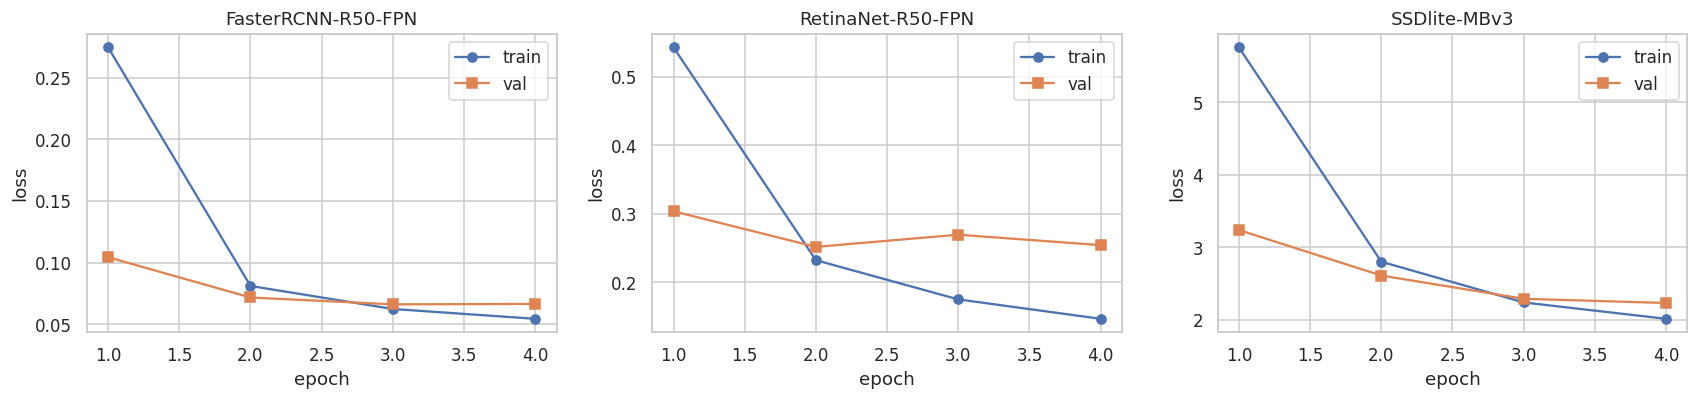

FasterRCNN-R50-FPN    : val loss thấp nhất 0.0663 tại epoch 3  |  thời gian train 2.2 phút
RetinaNet-R50-FPN     : val loss thấp nhất 0.2518 tại epoch 2  |  thời gian train 1.6 phút
SSDlite-MBv3          : val loss thấp nhất 2.2297 tại epoch 4  |  thời gian train 1.3 phút


In [26]:
# =============================================================================
# ĐƯỜNG CONG LOSS CỦA CÁC MÔ HÌNH TORCHVISION
# =============================================================================
if HISTORIES:
    fig, axes = plt.subplots(1, len(HISTORIES), figsize=(5.2 * len(HISTORIES), 3.8),
                             squeeze=False)
    for ax, (name, h) in zip(axes[0], HISTORIES.items()):
        ax.plot(h["epoch"], h["train_loss"], "o-", label="train")
        ax.plot(h["epoch"], h["val_loss"], "s-", label="val")
        ax.set_title(name); ax.set_xlabel("epoch"); ax.set_ylabel("loss"); ax.legend()
    plt.tight_layout(); plt.show()
    for name, h in HISTORIES.items():
        best = h.loc[h["val_loss"].idxmin()]
        print(f"{name:22s}: val loss thấp nhất {best['val_loss']:.4f} tại epoch {int(best['epoch'])}"
              f"  |  thời gian train {TRAIN_TIME[name] / 60:.1f} phút")
else:
    print("Chưa có mô hình torchvision nào được huấn luyện.")

### 7.1 Huấn luyện YOLOv8 (Ultralytics)

Ultralytics dùng pipeline riêng: mosaic + HSV augmentation, optimizer tự chọn (`auto`),
EMA, cosine/linear LR. Ta chỉ cố định những gì ảnh hưởng tới **so sánh công bằng**:
cùng `data.yaml` (cùng split), cùng `imgsz=640`, cùng `seed=42`, cùng thiết bị.

Checkpoint được ghi vào `RUNS_DIR` (Drive nếu đã gắn). **Nếu Colab ngắt giữa chừng**, chạy lại
và thay bằng:

```python
YOLO(f"{RUNS_DIR}/YOLOv8n/weights/last.pt").train(resume=True)
```

In [27]:
# =============================================================================
# HUẤN LUYỆN YOLOv8n / YOLOv8s
# =============================================================================
YOLO_SPECS = {"YOLOv8n": "yolov8n.pt", "YOLOv8s": "yolov8s.pt"}
YOLO_BEST = {}

if HAS_ULTRA:
    from ultralytics import YOLO
    from ultralytics import settings as ultra_settings
    try:
        ultra_settings.update({"runs_dir": str(RUNS_DIR)})
    except Exception:
        pass

    for name, ckpt in YOLO_SPECS.items():
        if not MODEL_ENABLED.get(name, False):
            print(f"[bỏ qua] {name}")
            continue
        print("\n" + "=" * 74)
        print(f"HUẤN LUYỆN {name}  ({MODEL_FAMILY[name]})")
        print("=" * 74)
        try:
            set_seed(SEED)
            t0 = time.time()
            model = YOLO(ckpt)                    # trọng số tiền huấn luyện COCO
            model.train(
                data=str(YOLO_YAML),
                epochs=EPOCHS_YOLO,
                imgsz=IMG_SIZE,
                batch=BATCH_YOLO,
                device=0 if DEVICE == "cuda" else "cpu",
                workers=NUM_WORKERS,
                seed=SEED,
                deterministic=True,
                project=str(RUNS_DIR),
                name=name,
                exist_ok=True,
                pretrained=True,
                optimizer="auto",
                cos_lr=True,
                patience=max(10, EPOCHS_YOLO // 3),
                amp=USE_AMP,
                val=True,
                plots=True,
                verbose=False,
            )
            TRAIN_TIME[name] = time.time() - t0
            best = RUNS_DIR / name / "weights" / "best.pt"
            YOLO_BEST[name] = best
            TRAINED[name] = YOLO(str(best))
            print(f"{name}: xong sau {TRAIN_TIME[name] / 60:.1f} phút -> {best}")
        except Exception as e:
            FAILED[name] = str(e)
            print(f"[LỖI] {name}: {e}")
            if DEVICE == "cuda":
                torch.cuda.empty_cache()
else:
    print("Chưa cài ultralytics -> bỏ qua phần YOLO.")

print("\nTổng số mô hình đã sẵn sàng để đánh giá:", len(TRAINED), "->", list(TRAINED.keys()))


HUẤN LUYỆN YOLOv8n  (1-stage anchor-free (Ultralytics))
Ultralytics 8.4.128 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/indoor_det/work/yolo_ds/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, 

--- YOLOv8n: đường cong huấn luyện (chỉ số nội bộ Ultralytics) ---


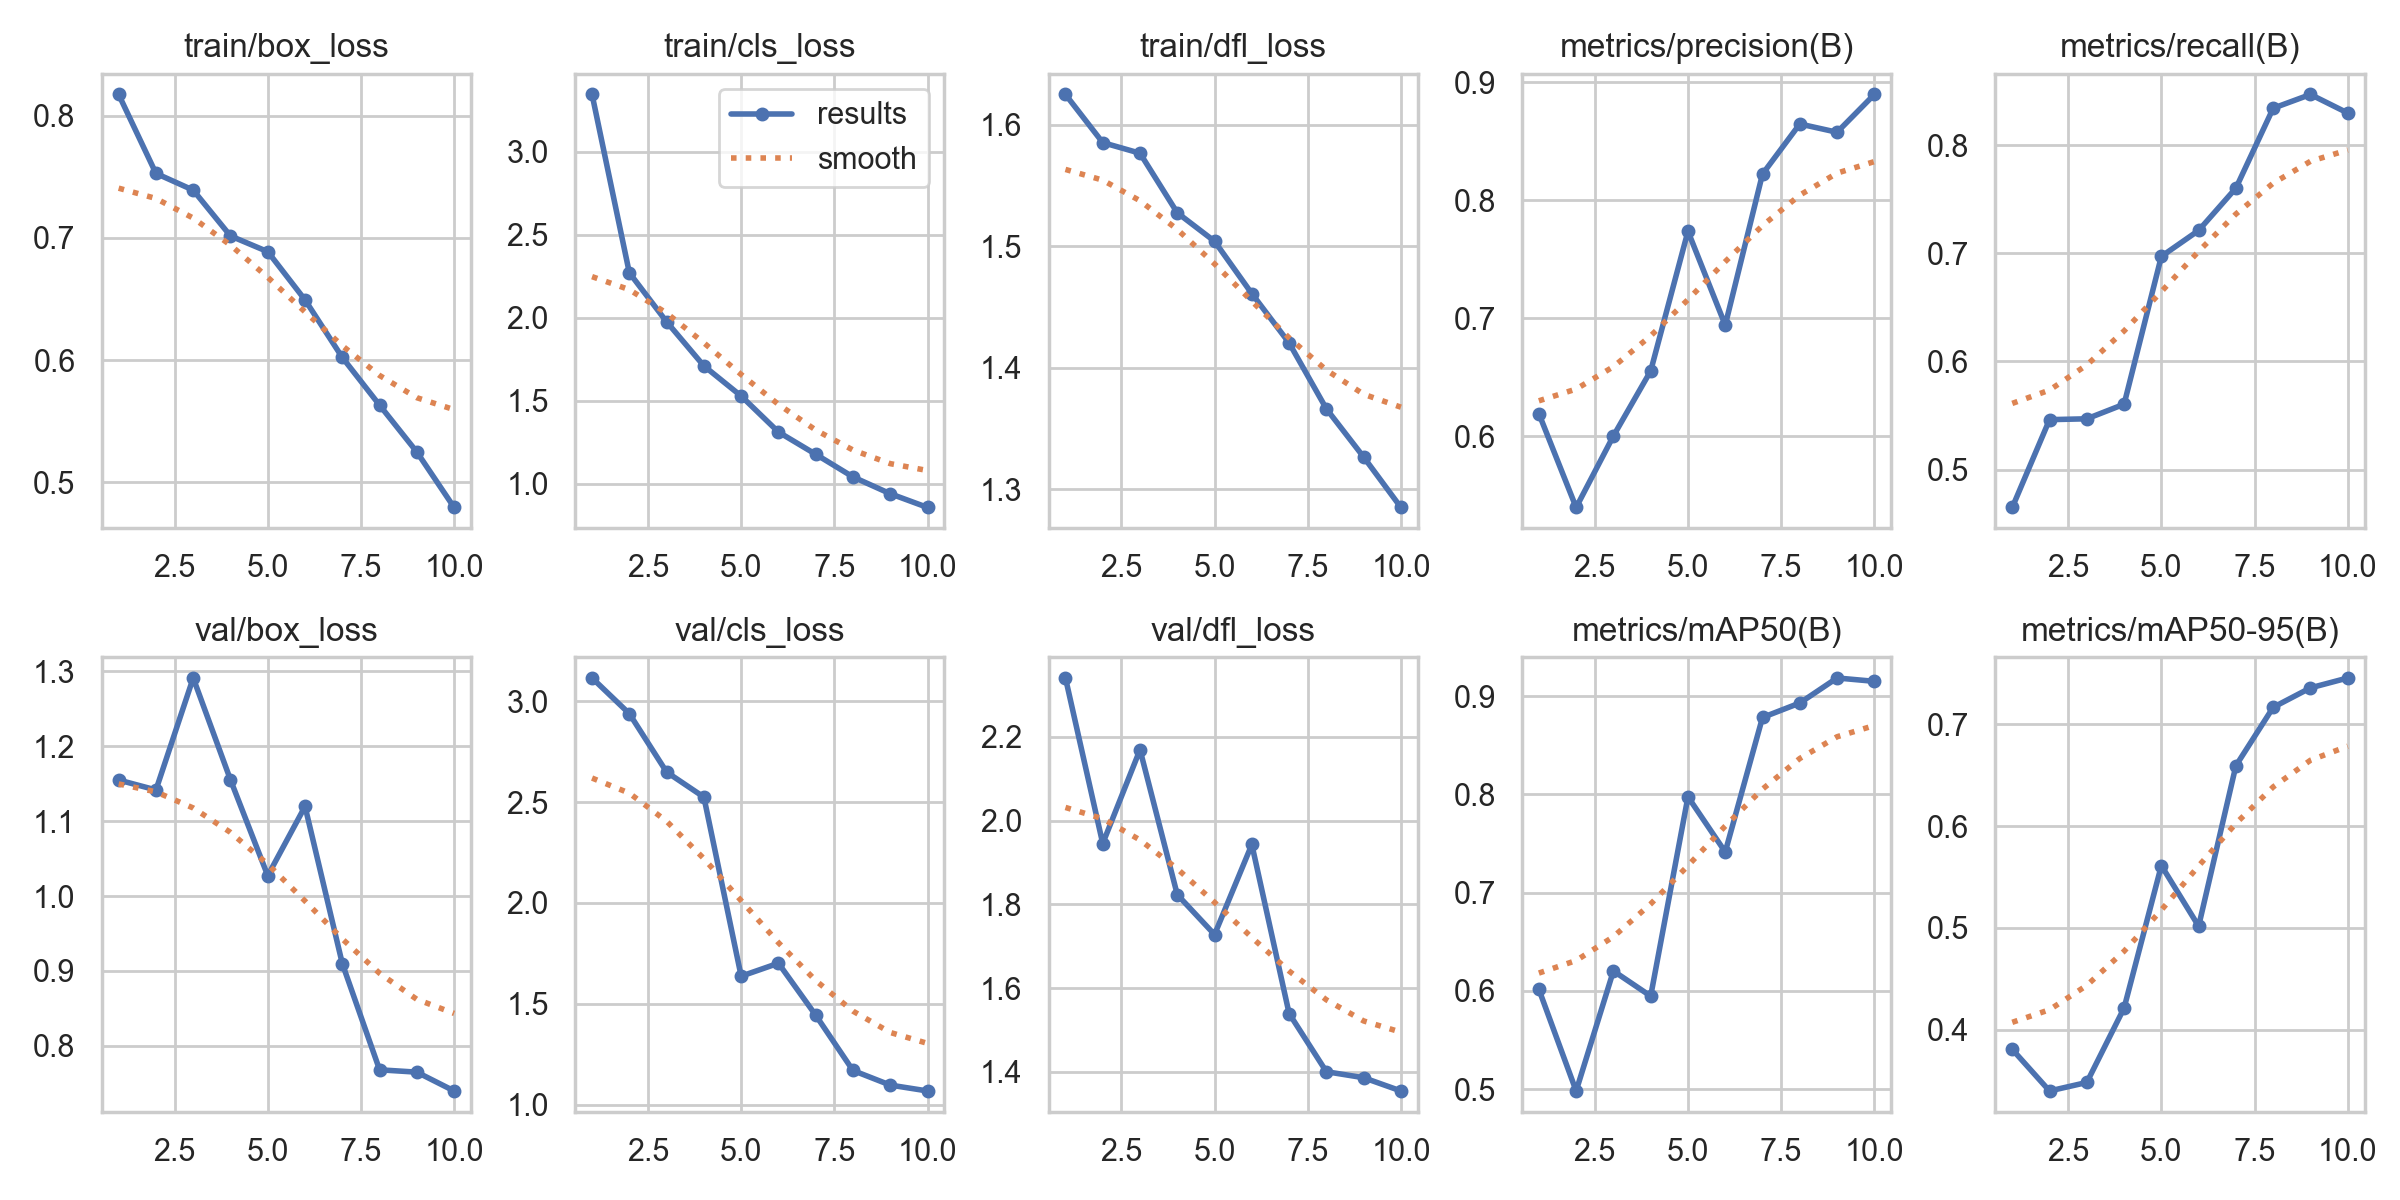

YOLOv8n: 3 epoch cuối


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss
7,8,0.5632,1.0417,1.3661,0.8930,0.7166,0.7680,1.1688,1.4003
8,9,0.5249,0.9406,1.3264,0.9185,0.7357,0.7648,1.0963,1.3860
9,10,0.4796,0.8580,1.2849,0.9151,0.7454,0.7397,1.0672,1.3543


--- YOLOv8s: đường cong huấn luyện (chỉ số nội bộ Ultralytics) ---


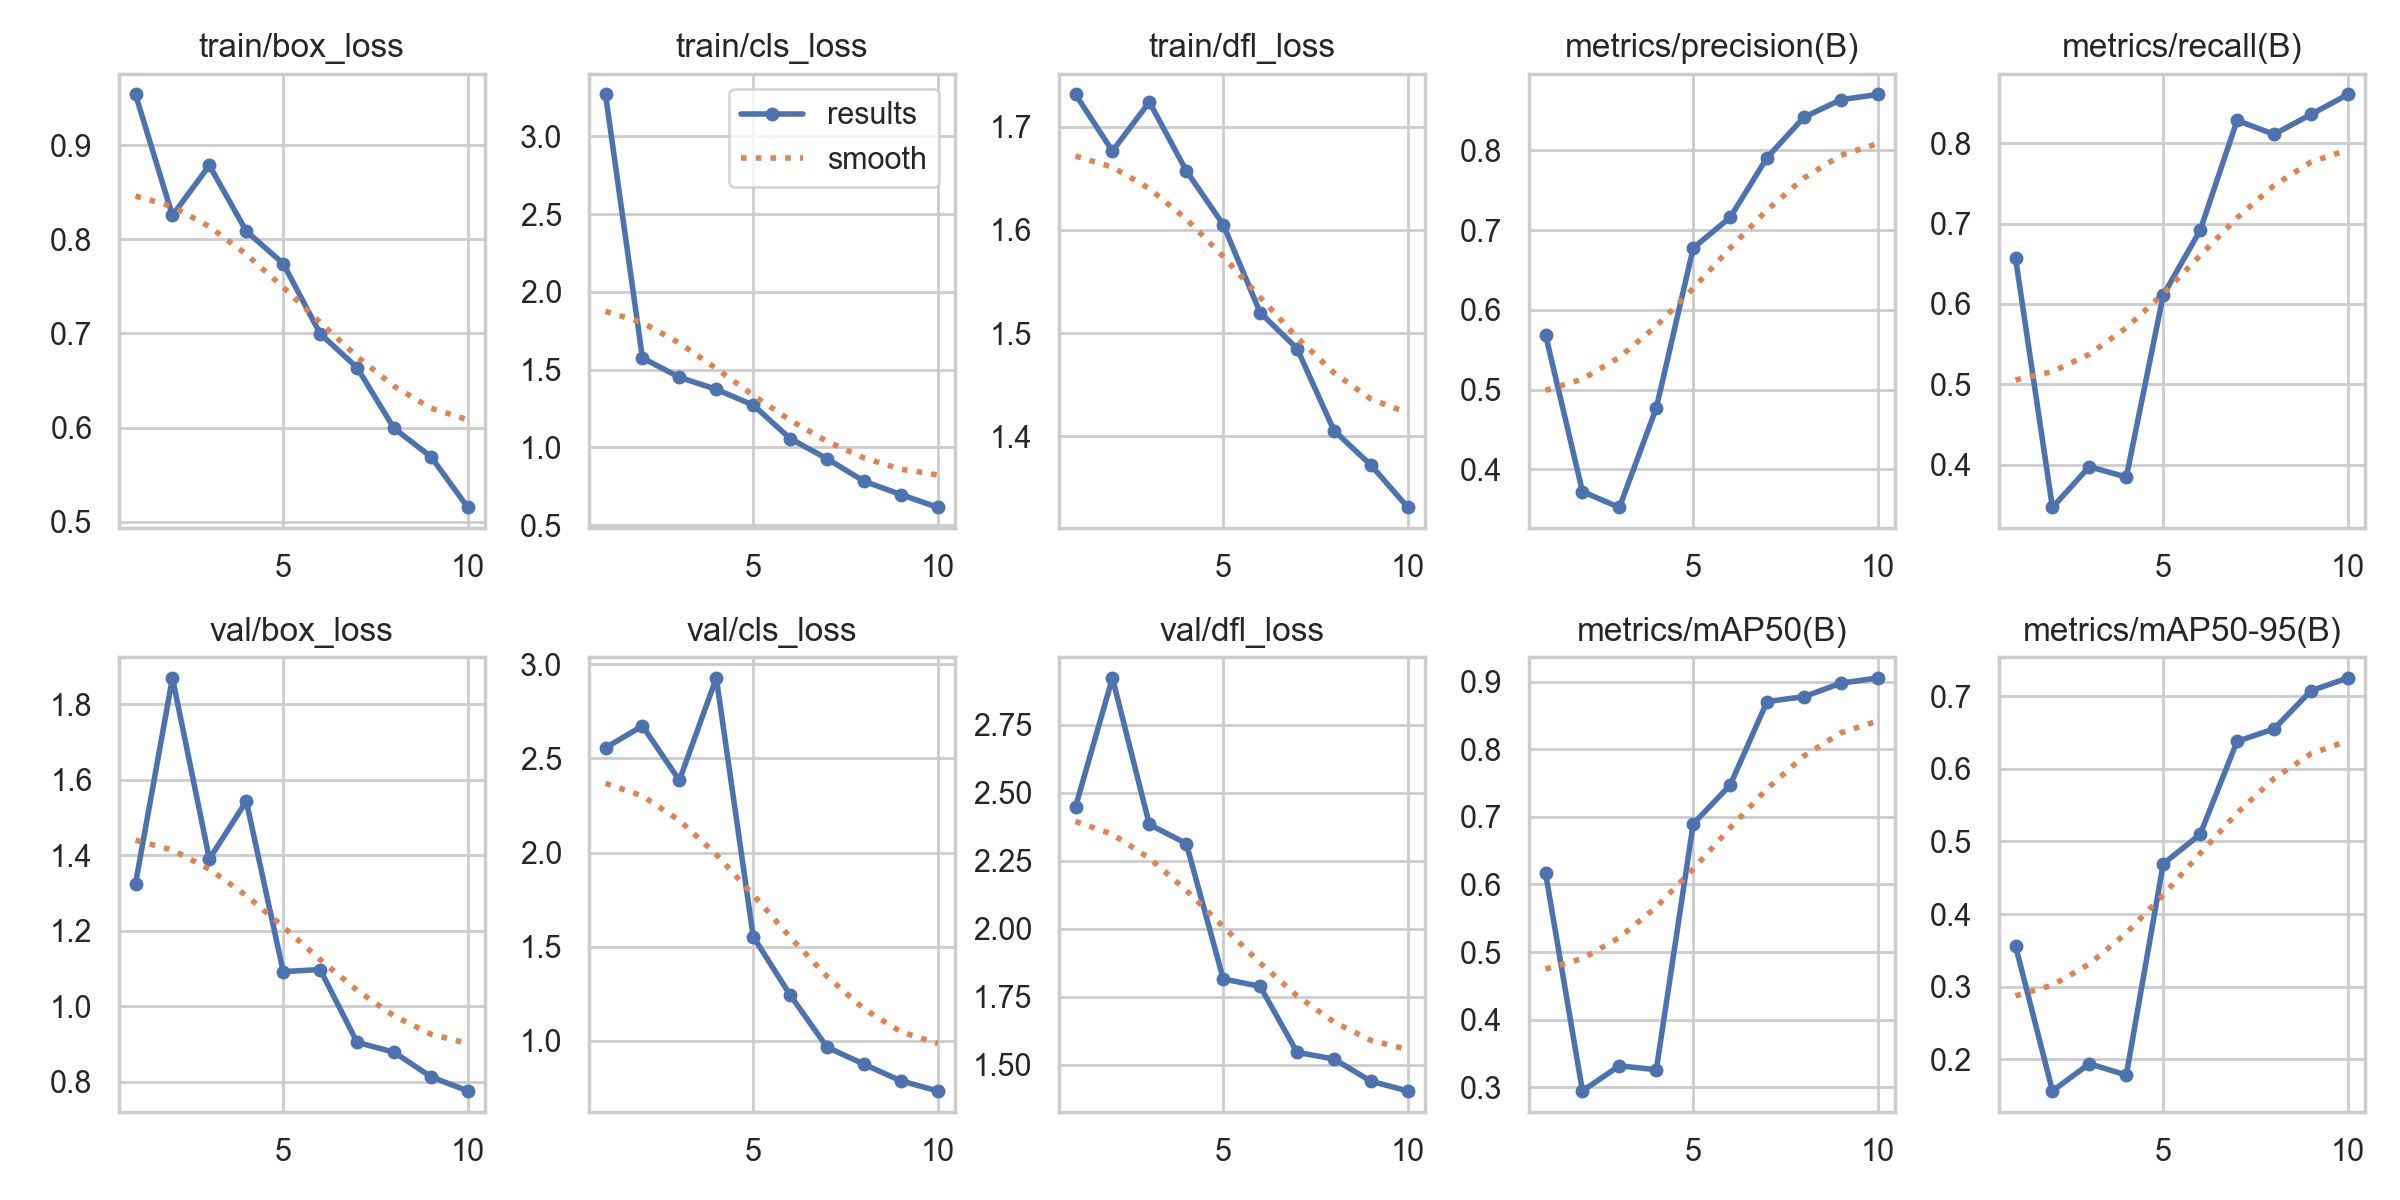

YOLOv8s: 3 epoch cuối


,epoch,train/box_loss,train/cls_loss,train/dfl_loss,metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss
7,8,0.5992,0.7821,1.4056,0.8778,0.6547,0.8785,0.8749,1.5209
8,9,0.5690,0.6964,1.3721,0.8978,0.7073,0.8132,0.7864,1.4392
9,10,0.5151,0.6134,1.3311,0.9055,0.7249,0.7757,0.7329,1.4034


In [28]:
# =============================================================================
# XEM ĐƯỜNG CONG HUẤN LUYỆN CỦA ULTRALYTICS (ảnh do thư viện tự sinh)
#   Lưu ý: các chỉ số trong ảnh này là chỉ số NỘI BỘ của Ultralytics, chỉ dùng để
#   theo dõi quá trình học. Việc SO SÁNH giữa các mô hình dùng bộ đo chung ở Phần 8.
# =============================================================================
from IPython.display import Image as IPyImage, display as ipy_display

for name in YOLO_SPECS:
    p = RUNS_DIR / name / "results.png"
    if p.exists():
        print(f"--- {name}: đường cong huấn luyện (chỉ số nội bộ Ultralytics) ---")
        ipy_display(IPyImage(filename=str(p), width=900))
    csv_p = RUNS_DIR / name / "results.csv"
    if csv_p.exists():
        df = pd.read_csv(csv_p)
        df.columns = [c.strip() for c in df.columns]
        cols = [c for c in df.columns if "loss" in c or "mAP" in c]
        print(f"{name}: 3 epoch cuối")
        display(df[["epoch"] + cols].tail(3).round(4))

---
# Phần 8 — Đánh giá bằng **một** giao thức đo duy nhất

Đây là phần quan trọng nhất về mặt phương pháp. Sai lầm phổ biến là lấy `mAP50-95` mà
Ultralytics tự in ra rồi đem so với `mAP` tính bằng thư viện khác — hai con số đó **không
so sánh được** (khác cách nội suy đường P-R, khác `maxDets`, khác cách xử lý ảnh không nhãn).

**Giao thức thống nhất áp dụng cho MỌI mô hình:**

1. Chạy suy luận trên **đúng cùng một danh sách `TEST_PATHS`**, theo cùng thứ tự, `image_id` giống nhau.
2. Sinh detection với **cùng tham số**: `conf ≥ 0.001`, NMS IoU `0.6`, tối đa `100` hộp/ảnh.
3. Đưa mọi kết quả về **cùng một mảng numpy** `[x1, y1, x2, y2, score, class_id]` (pixel gốc).
4. Chấm bằng **cùng một `COCOeval`** trên cùng file ground-truth COCO
   (dự phòng: `torchmetrics.MeanAveragePrecision` — nếu dùng thì **mọi** mô hình đều dùng nó).

**Các chỉ số báo cáo:**

| Chỉ số | Ý nghĩa |
|---|---|
| `mAP@0.5` | AP trung bình ở ngưỡng IoU 0.5 — "phát hiện đúng vật, hộp tạm khớp" |
| `mAP@0.5:0.95` | trung bình AP trên 10 ngưỡng IoU — khắt khe về **độ chính xác của hộp** |
| `AP` từng lớp | tìm lớp nào là điểm yếu |
| `AR@100` | recall trung bình, tối đa 100 detection/ảnh |
| `P / R / F1 @ conf 0.25, IoU 0.5` | chỉ số "vận hành" ở một ngưỡng cố định |
| `ms/ảnh`, `FPS` | tốc độ suy luận (batch = 1, cùng thiết bị, có warm-up) |
| `Params (M)`, `Size (MB)` | chi phí bộ nhớ / lưu trữ khi triển khai |

In [29]:
# =============================================================================
# BỘ SINH DETECTION THỐNG NHẤT
#   Trả về: list theo ảnh, mỗi phần tử là ndarray (N,6) = [x1,y1,x2,y2,score,cls_id]
#   cls_id chạy 0..K-1 theo đúng thứ tự CLASS_NAMES.
# =============================================================================
def _topk_dets(arr, k=MAX_DET, conf=CONF_EVAL):
    if len(arr) == 0:
        return np.zeros((0, 6), dtype=np.float32)
    arr = arr[arr[:, 4] >= conf]
    if len(arr) > k:
        arr = arr[np.argsort(-arr[:, 4])[:k]]
    return arr.astype(np.float32)


@torch.no_grad()
def predict_torchvision(model, paths, batch=8, conf=CONF_EVAL, progress=True):
    model.eval().to(DEVICE)
    out = []
    rng = range(0, len(paths), batch)
    for i in (tqdm(rng, desc="suy luận (torchvision)", leave=False) if progress else rng):
        imgs = [load_image_tensor(p).to(DEVICE) for p in paths[i:i + batch]]
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            res = model(imgs)
        for r in res:
            b = r["boxes"].float().cpu().numpy()
            s = r["scores"].float().cpu().numpy()
            l = r["labels"].cpu().numpy().astype(np.float32) - 1.0     # về 0..K-1
            arr = np.concatenate([b, s[:, None], l[:, None]], axis=1) if len(b) \
                else np.zeros((0, 6), dtype=np.float32)
            out.append(_topk_dets(arr, conf=conf))
    return out


def predict_yolo(model, paths, batch=16, conf=CONF_EVAL, iou=NMS_IOU,
                 augment=False, progress=True):
    out = []
    rng = range(0, len(paths), batch)
    for i in (tqdm(rng, desc="suy luận (YOLO)", leave=False) if progress else rng):
        chunk = [str(p) for p in paths[i:i + batch]]
        res = model.predict(source=chunk, imgsz=IMG_SIZE, conf=conf, iou=iou,
                            max_det=MAX_DET, device=0 if DEVICE == "cuda" else "cpu",
                            augment=augment, verbose=False)
        for r in res:
            if r.boxes is None or len(r.boxes) == 0:
                out.append(np.zeros((0, 6), dtype=np.float32)); continue
            b = r.boxes.xyxy.cpu().numpy()
            s = r.boxes.conf.cpu().numpy()
            c = r.boxes.cls.cpu().numpy()
            out.append(_topk_dets(np.concatenate([b, s[:, None], c[:, None]], axis=1), conf=conf))
    return out


def is_yolo(model):
    return model.__class__.__module__.startswith("ultralytics")


def predict_any(model, paths, **kw):
    # Một cổng vào duy nhất -> đảm bảo mọi mô hình đi qua cùng tham số conf/NMS/max_det
    if is_yolo(model):
        return predict_yolo(model, paths, batch=16, **kw)
    kw.pop("iou", None); kw.pop("augment", None)
    return predict_torchvision(model, paths, batch=8, **kw)

In [30]:
# =============================================================================
# TRÌNH CHẤM ĐIỂM DÙNG CHUNG  (pycocotools -> dự phòng torchmetrics)
# =============================================================================
EVAL_BACKEND = "pycocotools" if HAS_COCOTOOLS else ("torchmetrics" if HAS_TORCHMETRICS else None)
if EVAL_BACKEND is None:
    raise RuntimeError("Cần pycocotools hoặc torchmetrics để chấm mAP. Hãy cài một trong hai.")
print("Bộ đo dùng chung cho TẤT CẢ mô hình:", EVAL_BACKEND)


def dets_to_coco_results(dets_per_image, image_ids):
    res = []
    for img_id, arr in zip(image_ids, dets_per_image):
        for x1, y1, x2, y2, sc, cl in arr:
            res.append({"image_id": int(img_id),
                        "category_id": int(cl) + 1,
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(sc)})
    return res


def _eval_pycocotools(gt_dict, dets_per_image, image_ids, class_names):
    from pycocotools.coco import COCO
    from pycocotools.cocoeval import COCOeval
    import io, contextlib

    coco_gt = COCO()
    coco_gt.dataset = gt_dict
    with contextlib.redirect_stdout(io.StringIO()):
        coco_gt.createIndex()

    results = dets_to_coco_results(dets_per_image, image_ids)
    empty = {"mAP@0.5:0.95": 0.0, "mAP@0.5": 0.0, "mAP@0.75": 0.0,
             "AP_small": float("nan"), "AP_medium": float("nan"), "AP_large": float("nan"),
             "AR@100": 0.0, "per_class_AP": {c: 0.0 for c in class_names},
             "per_class_AP50": {c: 0.0 for c in class_names}}
    if not results:
        return empty

    with contextlib.redirect_stdout(io.StringIO()):
        coco_dt = coco_gt.loadRes(results)
        E = COCOeval(coco_gt, coco_dt, iouType="bbox")
        E.params.maxDets = [1, 10, MAX_DET]
        E.evaluate(); E.accumulate()
    E.summarize()

    prec = E.eval["precision"]          # [T, R, K, A, M]
    per_ap, per_ap50 = {}, {}
    for k, c in enumerate(class_names):
        p = prec[:, :, k, 0, 2]
        per_ap[c] = float(p[p > -1].mean()) if (p > -1).any() else float("nan")
        p50 = prec[0, :, k, 0, 2]
        per_ap50[c] = float(p50[p50 > -1].mean()) if (p50 > -1).any() else float("nan")

    s = E.stats
    return {"mAP@0.5:0.95": float(s[0]), "mAP@0.5": float(s[1]), "mAP@0.75": float(s[2]),
            "AP_small": float(s[3]), "AP_medium": float(s[4]), "AP_large": float(s[5]),
            "AR@100": float(s[8]), "per_class_AP": per_ap, "per_class_AP50": per_ap50}


def _eval_torchmetrics(gt_dict, dets_per_image, image_ids, class_names):
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    gt_by_img = defaultdict(list)
    for a in gt_dict["annotations"]:
        x, y, w, h = a["bbox"]
        gt_by_img[a["image_id"]].append([x, y, x + w, y + h, a["category_id"] - 1])

    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox",
                                  max_detection_thresholds=[1, 10, MAX_DET],
                                  class_metrics=True)
    preds, targets = [], []
    for img_id, arr in zip(image_ids, dets_per_image):
        preds.append({"boxes": torch.tensor(arr[:, :4], dtype=torch.float32).reshape(-1, 4),
                      "scores": torch.tensor(arr[:, 4], dtype=torch.float32).reshape(-1),
                      "labels": torch.tensor(arr[:, 5], dtype=torch.int64).reshape(-1)})
        g = np.array(gt_by_img.get(int(img_id), []), dtype=np.float32).reshape(-1, 5)
        targets.append({"boxes": torch.tensor(g[:, :4]).reshape(-1, 4),
                        "labels": torch.tensor(g[:, 4], dtype=torch.int64).reshape(-1)})
    metric.update(preds, targets)
    m = metric.compute()

    per_ap, per_ap50 = {}, {}
    classes = m.get("classes", torch.tensor([])).tolist() if "classes" in m else []
    maps = m.get("map_per_class", torch.tensor([])).tolist()
    if not isinstance(maps, list):
        maps = [maps]
    for ci, ap in zip(classes, maps):
        if 0 <= int(ci) < len(class_names):
            per_ap[class_names[int(ci)]] = float(ap)
    for c in class_names:
        per_ap.setdefault(c, float("nan"))
        per_ap50[c] = float("nan")

    return {"mAP@0.5:0.95": float(m["map"]), "mAP@0.5": float(m["map_50"]),
            "mAP@0.75": float(m["map_75"]),
            "AP_small": float(m["map_small"]), "AP_medium": float(m["map_medium"]),
            "AP_large": float(m["map_large"]),
            "AR@100": float(m["mar_100"]),
            "per_class_AP": per_ap, "per_class_AP50": per_ap50}


def run_eval(gt_dict, dets_per_image, image_ids, class_names=None):
    class_names = class_names or CLASS_NAMES
    if EVAL_BACKEND == "pycocotools":
        return _eval_pycocotools(gt_dict, dets_per_image, image_ids, class_names)
    return _eval_torchmetrics(gt_dict, dets_per_image, image_ids, class_names)

Bộ đo dùng chung cho TẤT CẢ mô hình: pycocotools


In [31]:
# =============================================================================
# PRECISION / RECALL / F1 Ở NGƯỠNG CỐ ĐỊNH (khớp tham lam theo điểm số)
#   Cách tính này giống hệt nhau cho mọi mô hình.
# =============================================================================
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=np.float32)
    ax1, ay1, ax2, ay2 = a[:, 0:1], a[:, 1:2], a[:, 2:3], a[:, 3:4]
    bx1, by1, bx2, by2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
    iw = np.clip(np.minimum(ax2, bx2) - np.maximum(ax1, bx1), 0, None)
    ih = np.clip(np.minimum(ay2, by2) - np.maximum(ay1, by1), 0, None)
    inter = iw * ih
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return (inter / np.maximum(area_a + area_b - inter, 1e-9)).astype(np.float32)


def prf1_at(dets_per_image, records, conf=CONF_REPORT, iou_thr=IOU_REPORT):
    tp = defaultdict(int); fp = defaultdict(int); fn = defaultdict(int)
    for arr, rec in zip(dets_per_image, records):
        d = arr[arr[:, 4] >= conf]
        d = d[np.argsort(-d[:, 4])]
        gt = np.array([[b[1], b[2], b[3], b[4], CLASS_TO_ID[b[0]]]
                       for b in rec["boxes"]], dtype=np.float32).reshape(-1, 5)
        used = np.zeros(len(gt), dtype=bool)
        for row in d:
            cid = int(row[5])
            cand = np.where((gt[:, 4] == cid) & (~used))[0] if len(gt) else np.array([], int)
            if len(cand):
                ious = iou_matrix(row[None, :4], gt[cand, :4])[0]
                j = int(np.argmax(ious))
                if ious[j] >= iou_thr:
                    used[cand[j]] = True
                    tp[CLASS_NAMES[cid]] += 1
                    continue
            fp[CLASS_NAMES[cid]] += 1
        for k in np.where(~used)[0]:
            fn[CLASS_NAMES[int(gt[k, 4])]] += 1

    rows = []
    for c in CLASS_NAMES:
        p = tp[c] / max(1, tp[c] + fp[c])
        r = tp[c] / max(1, tp[c] + fn[c])
        rows.append({"class": c, "TP": tp[c], "FP": fp[c], "FN": fn[c],
                     "precision": p, "recall": r,
                     "f1": 2 * p * r / max(1e-9, p + r)})
    per_cls = pd.DataFrame(rows)
    TP, FP, FN = per_cls["TP"].sum(), per_cls["FP"].sum(), per_cls["FN"].sum()
    P = TP / max(1, TP + FP); R = TP / max(1, TP + FN)
    micro = {"precision": P, "recall": R, "f1": 2 * P * R / max(1e-9, P + R),
             "TP": int(TP), "FP": int(FP), "FN": int(FN)}
    return micro, per_cls

In [32]:
# =============================================================================
# ĐO TỐC ĐỘ SUY LUẬN + ĐẾM THAM SỐ + KÍCH THƯỚC MÔ HÌNH
# =============================================================================
def count_params(model):
    net = model.model if is_yolo(model) else model
    return sum(p.numel() for p in net.parameters())


def model_size_mb(name, model):
    for cand in [RUNS_DIR / name / "weights" / "best.pt", RUNS_DIR / name / "best.pt"]:
        if cand.exists():
            return cand.stat().st_size / 1e6
    tmp = Path("/content") / f"_tmp_{name}.pt"
    net = model.model if is_yolo(model) else model
    torch.save(net.state_dict(), tmp)
    sz = tmp.stat().st_size / 1e6
    tmp.unlink(missing_ok=True)
    return sz


def benchmark_speed(model, paths, n=SPEED_N, warmup=5):
    # batch = 1, tính cả tiền/hậu xử lý -> phản ánh độ trễ khi triển khai thực tế
    sub = [str(p) for p in paths[:max(n, 1)]]
    for p in sub[:warmup]:
        predict_any(model, [p], progress=False)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    for p in sub:
        predict_any(model, [p], progress=False)
    if DEVICE == "cuda":
        torch.cuda.synchronize()
    dt = (time.perf_counter() - t0) / len(sub)
    return dt * 1000.0, 1.0 / max(dt, 1e-9)     # ms/ảnh, FPS

In [33]:
# =============================================================================
# CHẠY ĐÁNH GIÁ CHO TẤT CẢ MÔ HÌNH TRÊN CÙNG TẬP TEST
# =============================================================================
RAW_DETS   = {}    # name -> list ndarray (N,6)  (conf >= 0.001, chưa lọc)
EVAL_RES   = {}    # name -> dict chỉ số COCO
PRF        = {}    # name -> (micro dict, per-class DataFrame)
results_rows = []

for name, model in TRAINED.items():
    print("\n" + "=" * 74)
    print(f"ĐÁNH GIÁ {name}  trên {len(TEST_PATHS)} ảnh test  |  bộ đo: {EVAL_BACKEND}")
    print("=" * 74)
    try:
        dets = predict_any(model, TEST_PATHS)
        RAW_DETS[name] = dets

        res = run_eval(COCO_GT["test"], dets, TEST_IMAGE_IDS)
        EVAL_RES[name] = res

        micro, per_cls = prf1_at(dets, SPLITS["test"])
        PRF[name] = (micro, per_cls)

        ms, fps = benchmark_speed(model, TEST_PATHS)
        n_par = count_params(model)
        size = model_size_mb(name, model)

        results_rows.append({
            "Mô hình": name,
            "Họ kiến trúc": MODEL_FAMILY[name],
            "mAP@0.5": res["mAP@0.5"],
            "mAP@0.5:0.95": res["mAP@0.5:0.95"],
            "mAP@0.75": res["mAP@0.75"],
            "AR@100": res["AR@100"],
            f"P@{CONF_REPORT}": micro["precision"],
            f"R@{CONF_REPORT}": micro["recall"],
            f"F1@{CONF_REPORT}": micro["f1"],
            "ms/ảnh": ms,
            "FPS": fps,
            "Params (M)": n_par / 1e6,
            "Size (MB)": size,
            "Train (phút)": TRAIN_TIME.get(name, float("nan")) / 60.0,
        })
        print(f"-> mAP@0.5 = {res['mAP@0.5']:.4f} | mAP@0.5:0.95 = {res['mAP@0.5:0.95']:.4f} "
              f"| F1@{CONF_REPORT} = {micro['f1']:.4f} | {ms:.1f} ms/ảnh ({fps:.1f} FPS)")
    except Exception as e:
        FAILED[name] = str(e)
        print(f"[LỖI khi đánh giá] {name}: {e}")

results_df = pd.DataFrame(results_rows)
if len(results_df):
    results_df = results_df.sort_values("mAP@0.5:0.95", ascending=False).reset_index(drop=True)
print("\nĐã đánh giá xong", len(results_df), "mô hình.")


ĐÁNH GIÁ FasterRCNN-R50-FPN  trên 200 ảnh test  |  bộ đo: pycocotools


suy luận (torchvision):   0%|          | 0/25 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.721
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.945
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.864
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.721
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.757
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.814
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.814
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.814
-> mAP@0.5 = 0.9453 | mAP@0.5:0.95 =

suy luận (torchvision):   0%|          | 0/25 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.762
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.925
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.821
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.762
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.810
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.871
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.877
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.877
-> mAP@0.5 = 0.9253 | mAP@0.5:0.95 =

...

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.774
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.918
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.854
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.774
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.826
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.886
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.888
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.888
-> mAP@0.5 = 0.9180 | mAP@0.5:0.95 =

suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.739
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.930
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.821
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.739
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.765
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.828
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.829
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.829
-> mAP@0.5 = 0.9305 | mAP@0.5:0.95 =

suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.741
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.928
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.816
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.741
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.761
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.817
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.817
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.817
-> mAP@0.5 = 0.9283 | mAP@0.5:0.95 =

---
# Phần 9 — Bảng so sánh và biểu đồ

In [34]:
# =============================================================================
# BẢNG SO SÁNH TỔNG HỢP
# =============================================================================
if len(results_df) == 0:
    print("Chưa có kết quả nào — hãy kiểm tra lại phần huấn luyện.")
else:
    show = results_df.copy()
    num_cols = [c for c in show.columns if show[c].dtype.kind == "f"]
    display(show.style
            .format({c: "{:.4f}" for c in num_cols if "mAP" in c or c.startswith(("P@", "R@", "F1@")) or c == "AR@100"})
            .format({"ms/ảnh": "{:.1f}", "FPS": "{:.1f}", "Params (M)": "{:.2f}",
                     "Size (MB)": "{:.1f}", "Train (phút)": "{:.1f}"})
            .background_gradient(subset=["mAP@0.5", "mAP@0.5:0.95"], cmap="Greens")
            .background_gradient(subset=["FPS"], cmap="Blues")
            .set_caption("So sánh các mô hình phát hiện vật thể — cùng split, cùng bộ đo"))

    # Lưu ra Drive để không mất khi Colab ngắt
    out_csv = RUNS_DIR / "results_comparison.csv"
    results_df.to_csv(out_csv, index=False)
    print("Đã lưu bảng kết quả ->", out_csv)

,Mô hình,Họ kiến trúc,mAP@0.5,mAP@0.5:0.95,mAP@0.75,AR@100,P@0.25,R@0.25,F1@0.25,ms/ảnh,FPS,Params (M),Size (MB),Train (phút)
0,SSDlite-MBv3,"1-stage anchor-based, hard-neg mining (torchvision)",0.918047,0.773979,0.854392,0.888031,0.784553,0.901869,0.839130,30.2,33.2,2.28,9.4,1.3
1,RetinaNet-R50-FPN,"1-stage anchor-based, focal loss (torchvision)",0.925266,0.761586,0.820865,0.877106,0.531088,0.957944,0.683333,36.2,27.6,36.46,146.1,1.6
2,YOLOv8s,1-stage anchor-free (Ultralytics),0.928303,0.740736,0.816369,0.817243,0.841410,0.892523,0.866213,16.1,62.1,11.13,22.5,1.5
3,YOLOv8n,1-stage anchor-free (Ultralytics),0.930484,0.739192,0.821411,0.829029,0.927536,0.897196,0.912114,16.1,62.2,3.01,6.2,1.6
4,FasterRCNN-R50-FPN,2-stage anchor-based (torchvision),0.945257,0.720661,0.864049,0.813773,0.601156,0.971963,0.742857,32.7,30.6,41.32,165.8,2.2


Đã lưu bảng kết quả -> /content/drive/MyDrive/dl_homework/hw2/results_comparison.csv


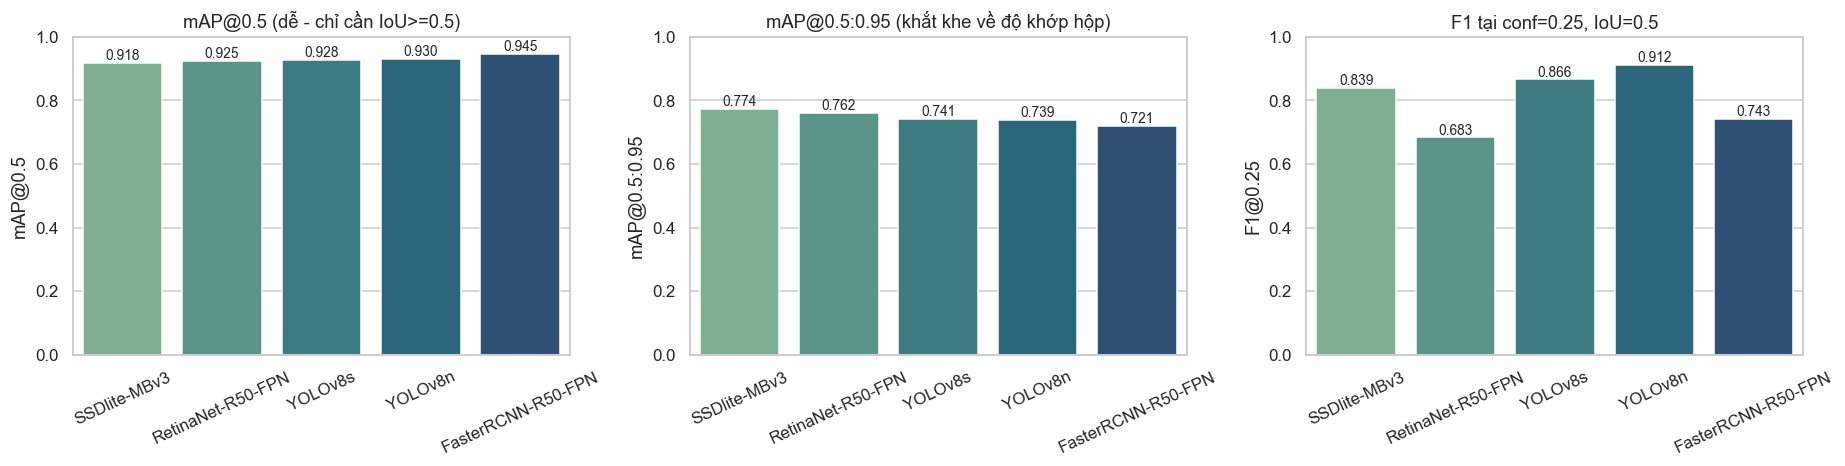

In [35]:
# =============================================================================
# BIỂU ĐỒ CỘT: mAP@0.5 và mAP@0.5:0.95
# =============================================================================
if len(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))
    order = results_df["Mô hình"].tolist()

    for ax, col, title in zip(
            axes,
            ["mAP@0.5", "mAP@0.5:0.95", f"F1@{CONF_REPORT}"],
            ["mAP@0.5 (dễ - chỉ cần IoU>=0.5)",
             "mAP@0.5:0.95 (khắt khe về độ khớp hộp)",
             f"F1 tại conf={CONF_REPORT}, IoU={IOU_REPORT}"]):
        sns.barplot(data=results_df, x="Mô hình", y=col, order=order, ax=ax, palette="crest")
        ax.set_title(title); ax.set_xlabel(""); ax.set_ylim(0, 1.0)
        ax.tick_params(axis="x", rotation=25)
        for i, v in enumerate(results_df[col].values):
            ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()

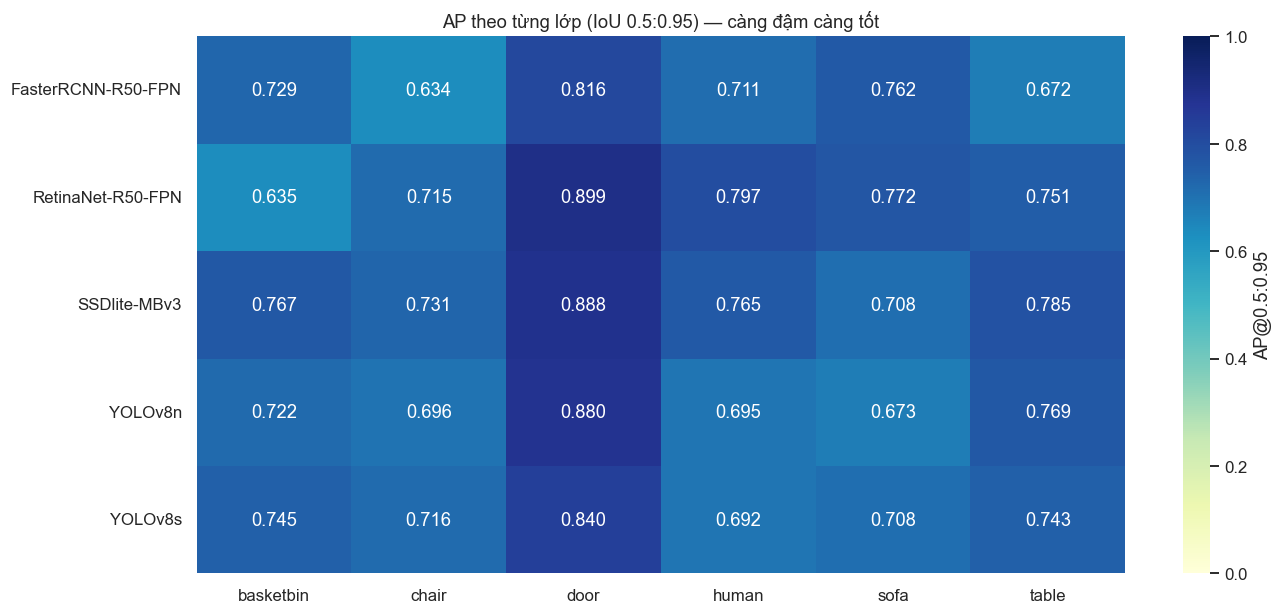

,basketbin,chair,door,human,sofa,table
FasterRCNN-R50-FPN,0.7289,0.6336,0.8157,0.7110,0.7625,0.6723
RetinaNet-R50-FPN,0.6352,0.7152,0.8987,0.7971,0.7725,0.7508
SSDlite-MBv3,0.7671,0.7308,0.8882,0.7650,0.7081,0.7846
YOLOv8n,0.7220,0.6965,0.8796,0.6949,0.6728,0.7695
YOLOv8s,0.7448,0.7158,0.8404,0.6920,0.7083,0.7431


Lớp KHÓ nhất (AP trung bình thấp nhất trên mọi mô hình): 'chair' (0.698)
Lớp DỄ nhất : 'door' (0.865)


In [36]:
# =============================================================================
# AP TỪNG LỚP - BẢN ĐỒ NHIỆT (mô hình x lớp)
# =============================================================================
if EVAL_RES:
    per_cls_map = pd.DataFrame(
        {name: pd.Series(res["per_class_AP"]) for name, res in EVAL_RES.items()}
    ).T.reindex(columns=CLASS_NAMES)

    fig, ax = plt.subplots(figsize=(1.6 * len(CLASS_NAMES) + 3, 0.75 * len(per_cls_map) + 2))
    sns.heatmap(per_cls_map, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1,
                cbar_kws={"label": "AP@0.5:0.95"}, ax=ax)
    ax.set_title("AP theo từng lớp (IoU 0.5:0.95) — càng đậm càng tốt")
    plt.tight_layout(); plt.show()

    display(per_cls_map.round(4))
    hardest = per_cls_map.mean(axis=0).idxmin()
    easiest = per_cls_map.mean(axis=0).idxmax()
    print(f"Lớp KHÓ nhất (AP trung bình thấp nhất trên mọi mô hình): '{hardest}' "
          f"({per_cls_map.mean(axis=0)[hardest]:.3f})")
    print(f"Lớp DỄ nhất : '{easiest}' ({per_cls_map.mean(axis=0)[easiest]:.3f})")

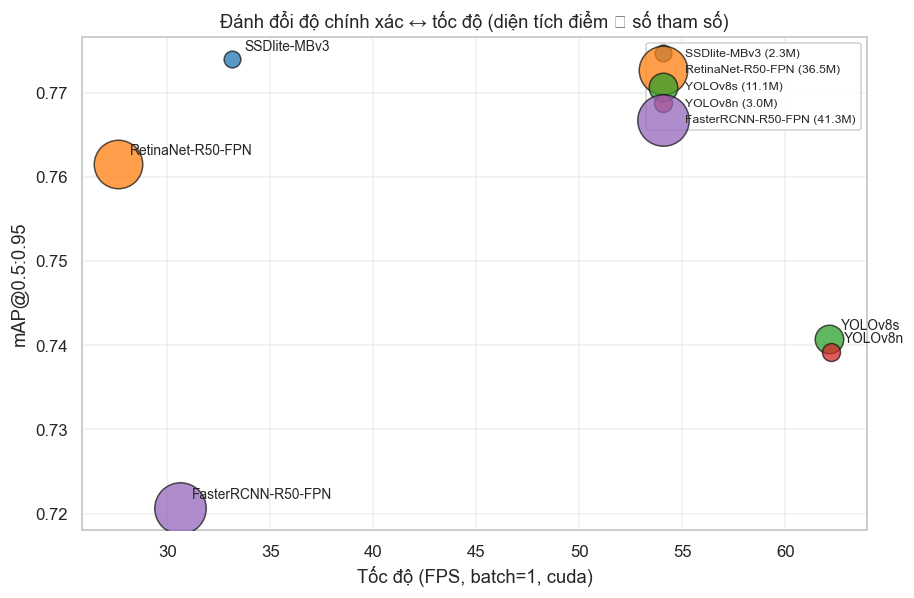

Các mô hình nằm trên BIÊN PARETO (không bị vượt trội đồng thời cả mAP lẫn FPS):
  SSDlite-MBv3, YOLOv8s, YOLOv8n


In [37]:
# =============================================================================
# SCATTER: ĐỘ CHÍNH XÁC  <->  TỐC ĐỘ  (kích thước điểm = số tham số)
# =============================================================================
if len(results_df):
    fig, ax = plt.subplots(figsize=(8.5, 5.6))
    colors = plt.get_cmap("tab10")
    for i, row in results_df.iterrows():
        ax.scatter(row["FPS"], row["mAP@0.5:0.95"],
                   s=60 + 26 * row["Params (M)"], color=colors(i % 10),
                   alpha=0.75, edgecolor="k", zorder=3,
                   label=f"{row['Mô hình']} ({row['Params (M)']:.1f}M)")
        ax.annotate(row["Mô hình"], (row["FPS"], row["mAP@0.5:0.95"]),
                    textcoords="offset points", xytext=(8, 6), fontsize=9)
    ax.set_xlabel(f"Tốc độ (FPS, batch=1, {DEVICE})")
    ax.set_ylabel("mAP@0.5:0.95")
    ax.set_title("Đánh đổi độ chính xác ↔ tốc độ (diện tích điểm ∝ số tham số)")
    ax.grid(alpha=0.3)
    ax.legend(loc="best", fontsize=8, framealpha=0.9)
    plt.tight_layout(); plt.show()

    # Biên Pareto: mô hình không bị mô hình nào khác vượt CẢ hai tiêu chí
    pareto = []
    for _, r in results_df.iterrows():
        dominated = ((results_df["FPS"] > r["FPS"]) &
                     (results_df["mAP@0.5:0.95"] > r["mAP@0.5:0.95"])).any()
        if not dominated:
            pareto.append(r["Mô hình"])
    print("Các mô hình nằm trên BIÊN PARETO (không bị vượt trội đồng thời cả mAP lẫn FPS):")
    print("  " + ", ".join(pareto))

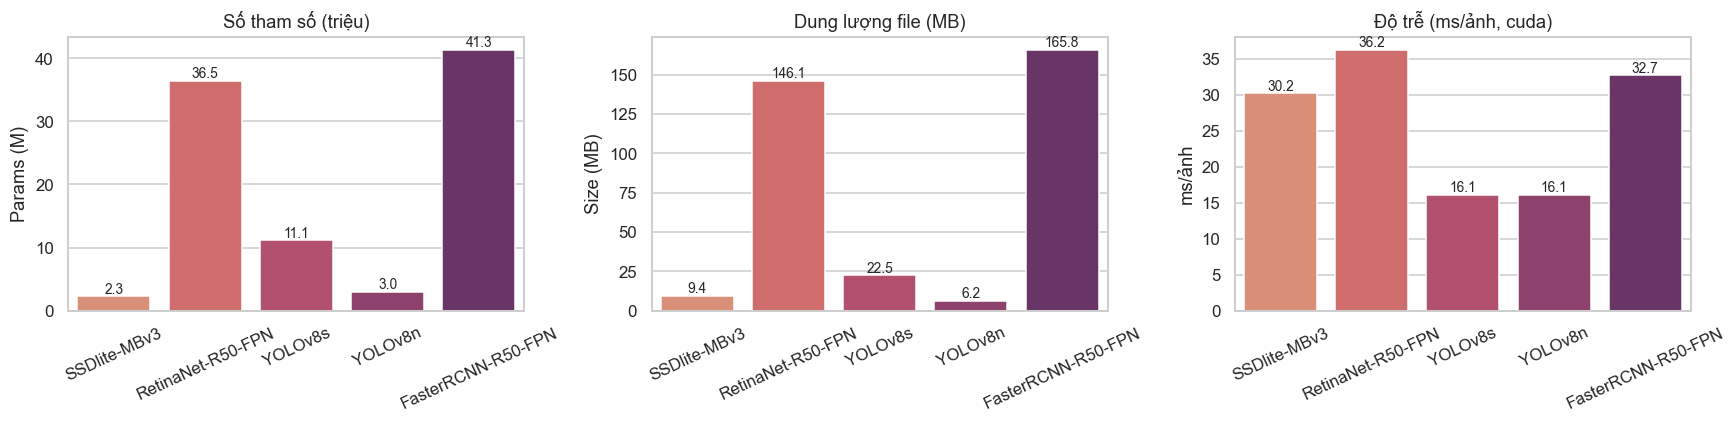

In [38]:
# =============================================================================
# CHI PHÍ TRIỂN KHAI: THAM SỐ, DUNG LƯỢNG, THỜI GIAN HUẤN LUYỆN
# =============================================================================
if len(results_df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for ax, col, lab in zip(axes,
                            ["Params (M)", "Size (MB)", "ms/ảnh"],
                            ["Số tham số (triệu)", "Dung lượng file (MB)",
                             f"Độ trễ (ms/ảnh, {DEVICE})"]):
        sns.barplot(data=results_df, x="Mô hình", y=col, ax=ax, palette="flare")
        ax.set_title(lab); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
        for i, v in enumerate(results_df[col].values):
            ax.text(i, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
    plt.tight_layout(); plt.show()

Mô hình tốt nhất theo mAP@0.5:0.95: SSDlite-MBv3

Tổng hợp (micro) tại conf=0.25, IoU=0.5: P=0.7846  R=0.9019  F1=0.8391  (TP=193, FP=53, FN=21)


,class,TP,FP,FN,precision,recall,f1
0,basketbin,39,9,1,0.8125,0.9750,0.8864
1,chair,29,12,5,0.7073,0.8529,0.7733
2,door,26,10,0,0.7222,1.0000,0.8387
3,human,35,7,1,0.8333,0.9722,0.8974
4,sofa,33,5,9,0.8684,0.7857,0.8250
5,table,31,10,5,0.7561,0.8611,0.8052


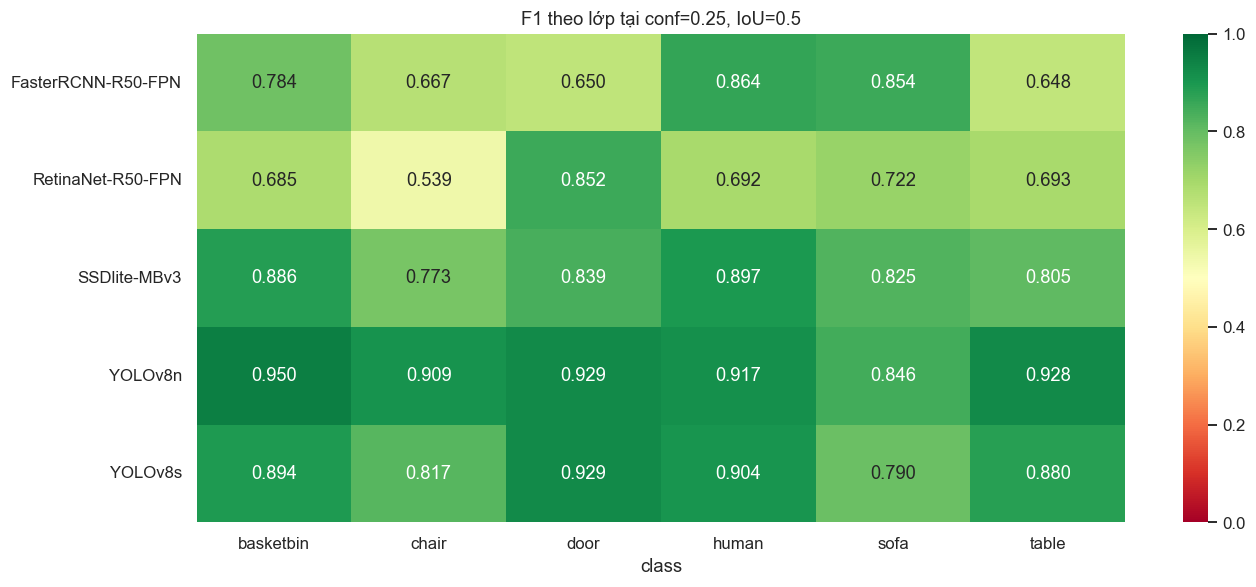

In [39]:
# =============================================================================
# BẢNG PRECISION / RECALL / F1 THEO TỪNG LỚP CỦA MÔ HÌNH TỐT NHẤT
# =============================================================================
if len(results_df):
    BEST_MODEL = results_df.iloc[0]["Mô hình"]
    print(f"Mô hình tốt nhất theo mAP@0.5:0.95: {BEST_MODEL}\n")
    micro, per_cls = PRF[BEST_MODEL]
    print(f"Tổng hợp (micro) tại conf={CONF_REPORT}, IoU={IOU_REPORT}: "
          f"P={micro['precision']:.4f}  R={micro['recall']:.4f}  F1={micro['f1']:.4f}  "
          f"(TP={micro['TP']}, FP={micro['FP']}, FN={micro['FN']})")
    display(per_cls.round(4))

    # So sánh F1 theo lớp giữa tất cả mô hình
    f1_tab = pd.DataFrame({n: PRF[n][1].set_index("class")["f1"] for n in PRF}).T
    f1_tab = f1_tab.reindex(columns=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(1.6 * len(CLASS_NAMES) + 3, 0.7 * len(f1_tab) + 2))
    sns.heatmap(f1_tab, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"F1 theo lớp tại conf={CONF_REPORT}, IoU={IOU_REPORT}")
    plt.tight_layout(); plt.show()
else:
    BEST_MODEL = None

---
# Phần 10 — So sánh định tính

Bảng số liệu cho biết *mô hình nào tốt hơn*, nhưng không cho biết *sai ở đâu*.
Hai lưới ảnh dưới đây trả lời câu hỏi đó:

1. **Cùng một ảnh test, dự đoán của từng mô hình đặt cạnh nhau** (cột đầu là nhãn thật).
2. **Bảng các ca lỗi** — những ảnh mà mô hình tốt nhất mắc lỗi nặng nhất
   (bỏ sót, báo nhầm, hoặc hộp lệch).

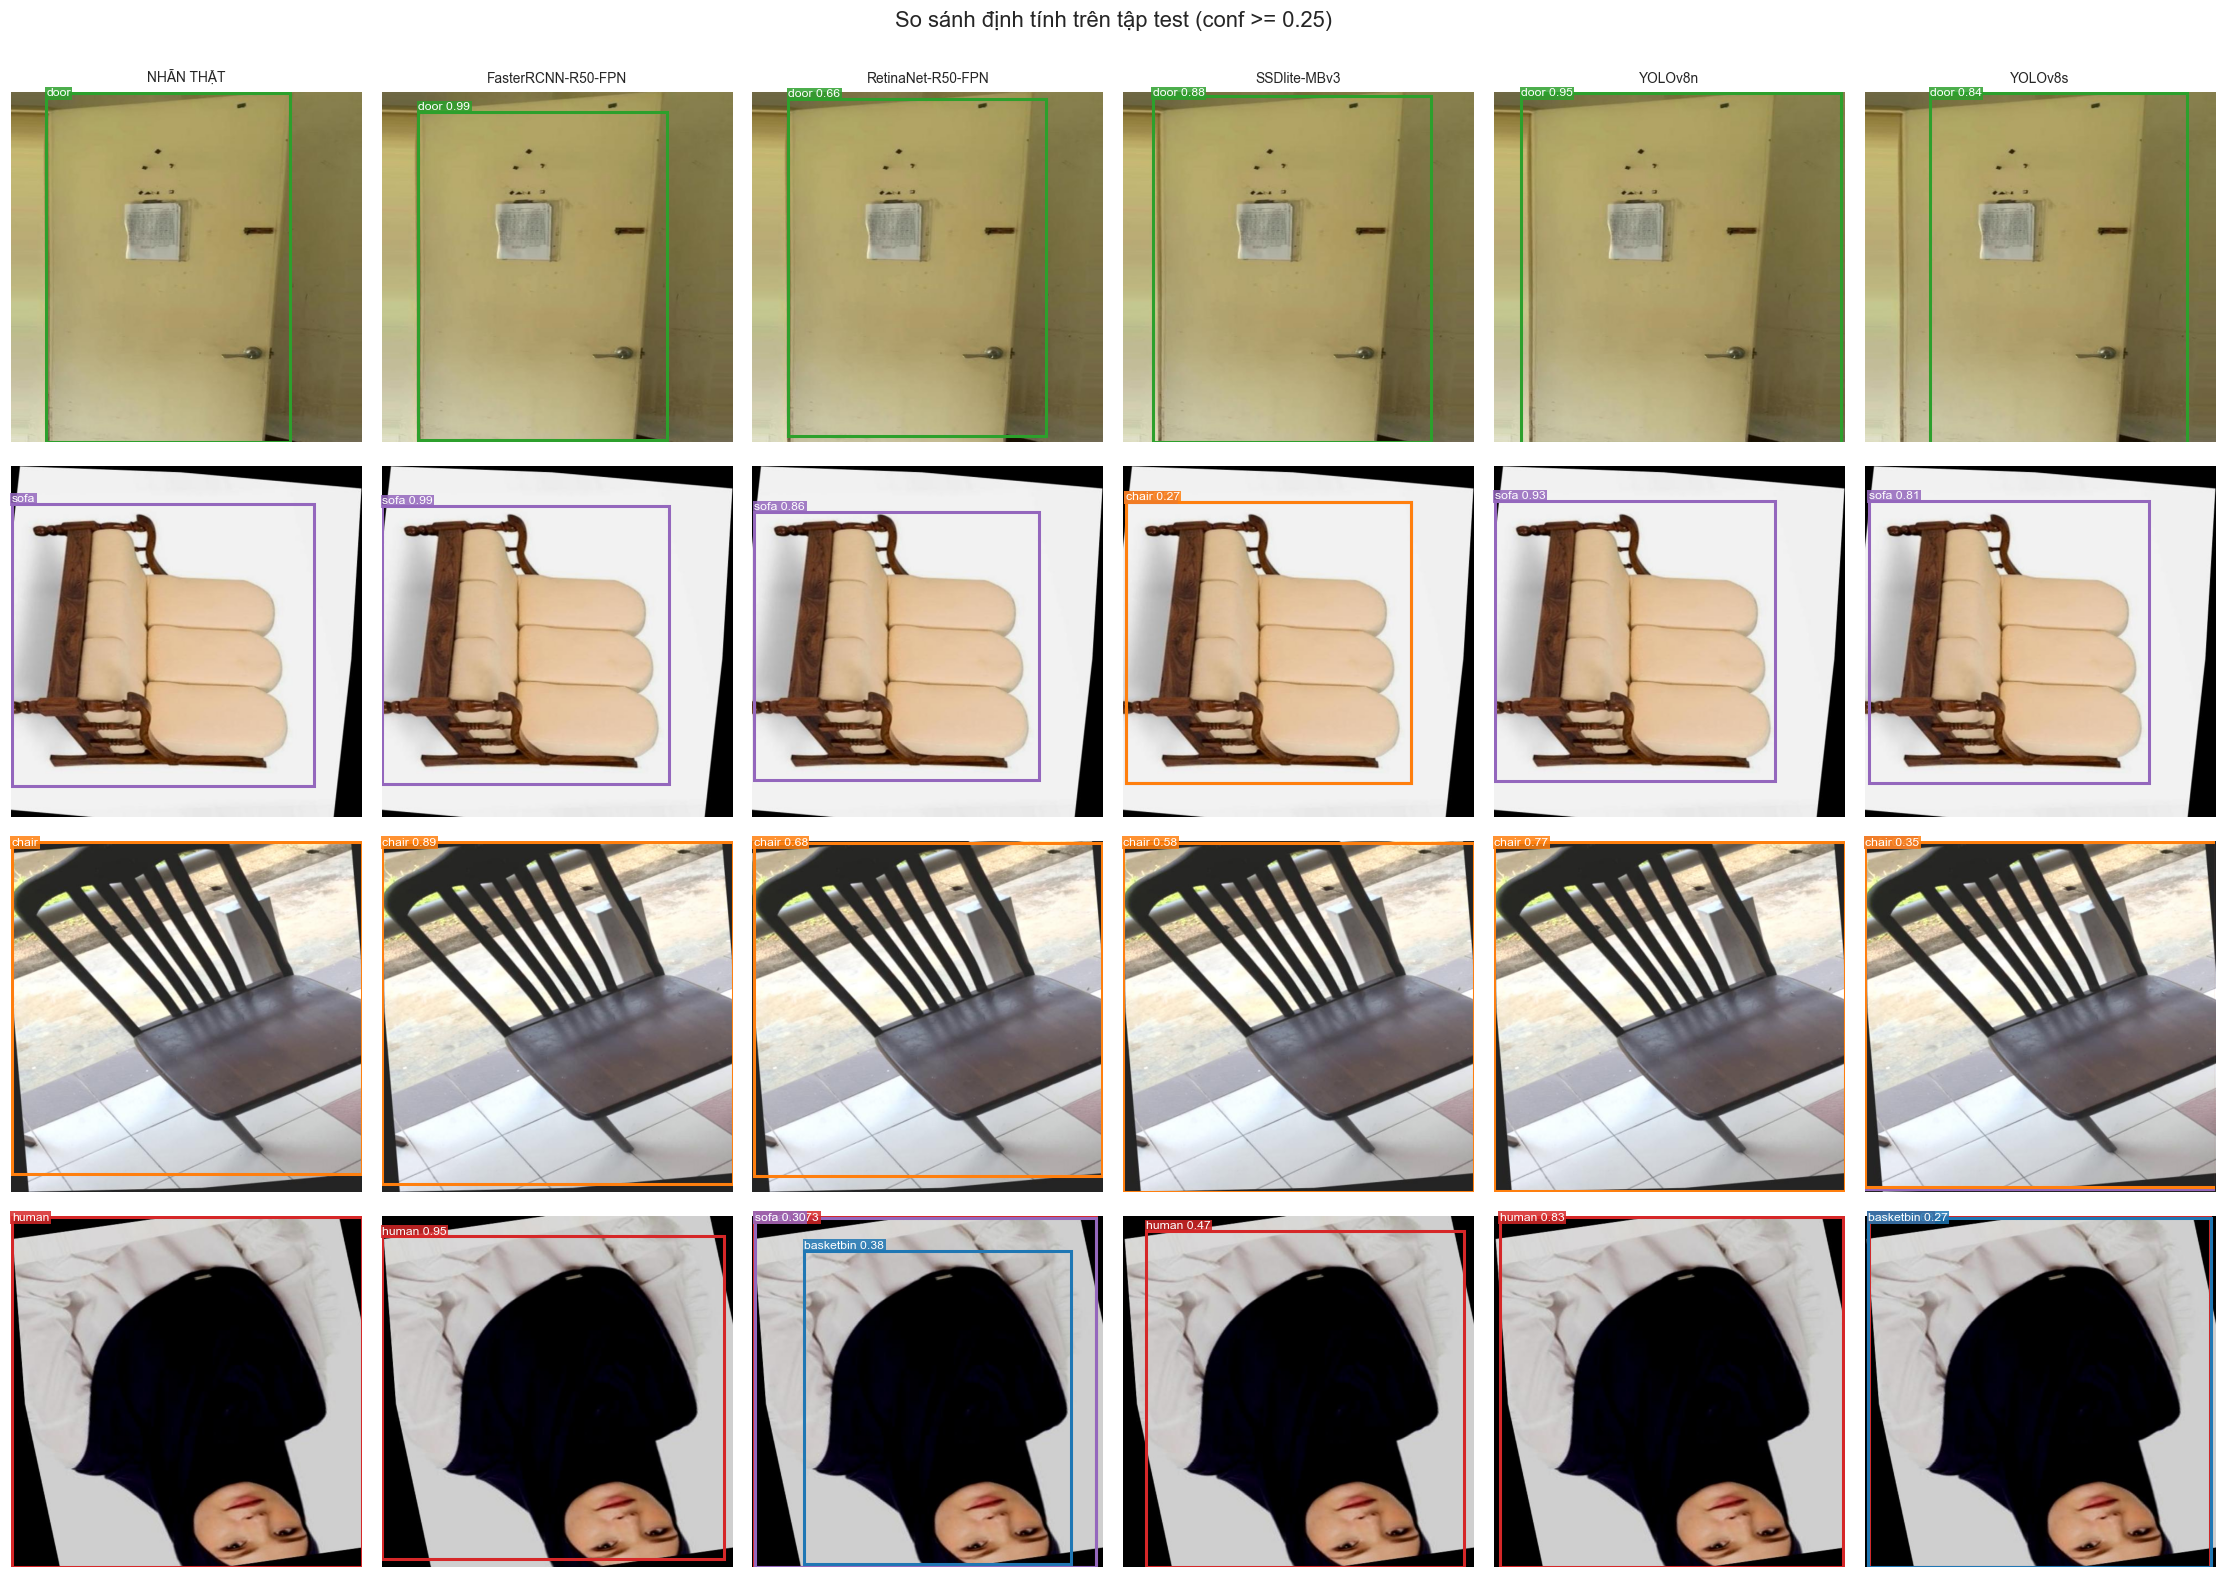

In [40]:
# =============================================================================
# LƯỚI SO SÁNH: NHÃN THẬT vs DỰ ĐOÁN CỦA TỪNG MÔ HÌNH
# =============================================================================
VIS_CONF = CONF_REPORT     # chỉ vẽ các hộp có conf >= 0.25 cho dễ nhìn


def dets_to_tuples(arr, conf=VIS_CONF):
    return [(CLASS_NAMES[int(c)], x1, y1, x2, y2, s)
            for x1, y1, x2, y2, s, c in arr if s >= conf]


if RAW_DETS:
    model_names = list(RAW_DETS.keys())
    set_seed(SEED)
    # Chọn ảnh có nhãn để so sánh cho có ý nghĩa
    cand = [i for i, r in enumerate(SPLITS["test"]) if len(r["boxes"]) > 0]
    pick = random.sample(cand, min(4, len(cand)))

    ncol = 1 + len(model_names)
    fig, axes = plt.subplots(len(pick), ncol, figsize=(3.4 * ncol, 3.6 * len(pick)),
                             squeeze=False)
    for row, idx in enumerate(pick):
        rec = SPLITS["test"][idx]
        img = Image.open(rec["image_path"]).convert("RGB")
        draw_boxes_on_ax(axes[row][0], img, rec["boxes"],
                         title="NHÃN THẬT" if row == 0 else "")
        for col, name in enumerate(model_names, start=1):
            draw_boxes_on_ax(axes[row][col], img,
                             dets_to_tuples(RAW_DETS[name][idx]),
                             title=name if row == 0 else "", show_score=True)
    plt.suptitle(f"So sánh định tính trên tập test (conf >= {VIS_CONF})", y=1.0)
    plt.tight_layout(); plt.show()
else:
    print("Chưa có dự đoán để vẽ.")

Thống kê lỗi của SSDlite-MBv3 trên tập test (conf=0.25):
  Ảnh dự đoán HOÀN TOÀN đúng : 149 / 200 (74.5%)
  Tổng bỏ sót (FN)           : 21
  Tổng báo nhầm (FP)         : 53
    trong đó hộp lệch (IoU 0.1-0.5, đúng lớp): 3
    trong đó nhầm lớp (đúng vị trí, sai nhãn) : 39
  Báo nhầm trên ảnh KHÔNG có nhãn: 1


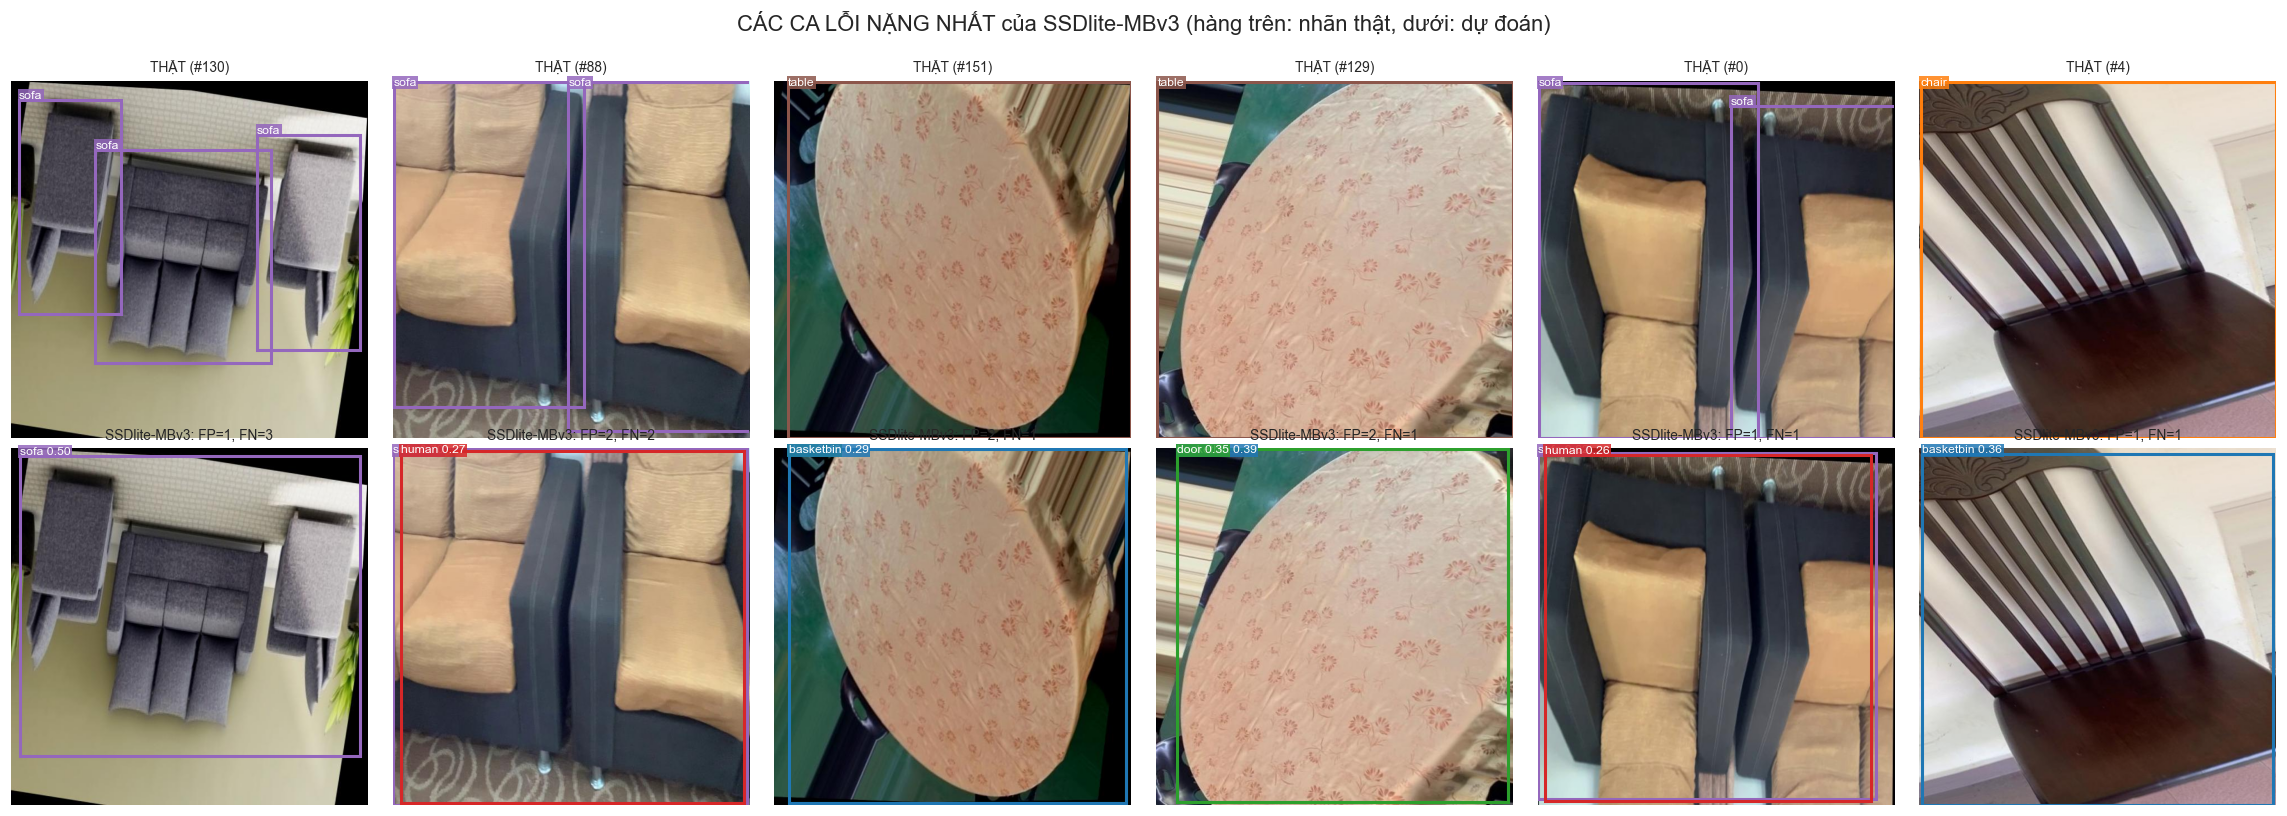

In [41]:
# =============================================================================
# BẢNG CÁC CA LỖI CỦA MÔ HÌNH TỐT NHẤT
#   Xếp hạng ảnh theo "mức độ sai": số hộp bỏ sót + số hộp báo nhầm
# =============================================================================
def error_profile(dets, records, conf=CONF_REPORT, iou_thr=IOU_REPORT):
    rows = []
    for i, (arr, rec) in enumerate(zip(dets, records)):
        d = arr[arr[:, 4] >= conf]
        d = d[np.argsort(-d[:, 4])]
        gt = np.array([[b[1], b[2], b[3], b[4], CLASS_TO_ID[b[0]]]
                       for b in rec["boxes"]], dtype=np.float32).reshape(-1, 5)
        used = np.zeros(len(gt), dtype=bool)
        tp = fp = 0
        loc_err = 0      # đúng lớp, IoU trong [0.1, 0.5) -> hộp lệch
        cls_err = 0      # trùng vị trí nhưng sai lớp
        for r_ in d:
            cid = int(r_[5])
            matched = False
            if len(gt):
                ious_all = iou_matrix(r_[None, :4], gt[:, :4])[0]
                same = (gt[:, 4] == cid) & (~used)
                if same.any():
                    j = int(np.argmax(np.where(same, ious_all, -1)))
                    if ious_all[j] >= iou_thr:
                        used[j] = True; tp += 1; matched = True
                    elif ious_all[j] >= 0.1:
                        loc_err += 1
                if not matched:
                    k = int(np.argmax(ious_all))
                    if ious_all[k] >= iou_thr and int(gt[k, 4]) != cid:
                        cls_err += 1
            if not matched:
                fp += 1
        fn = int((~used).sum())
        rows.append({"idx": i, "TP": tp, "FP": fp, "FN": fn,
                     "sai_vị_trí": loc_err, "sai_lớp": cls_err,
                     "n_gt": len(gt), "điểm_lỗi": fp + fn})
    return pd.DataFrame(rows)


if BEST_MODEL:
    err_df = error_profile(RAW_DETS[BEST_MODEL], SPLITS["test"])
    print(f"Thống kê lỗi của {BEST_MODEL} trên tập test (conf={CONF_REPORT}):")
    print(f"  Ảnh dự đoán HOÀN TOÀN đúng : {(err_df['điểm_lỗi'] == 0).sum()} / {len(err_df)} "
          f"({(err_df['điểm_lỗi'] == 0).mean():.1%})")
    print(f"  Tổng bỏ sót (FN)           : {err_df['FN'].sum()}")
    print(f"  Tổng báo nhầm (FP)         : {err_df['FP'].sum()}")
    print(f"    trong đó hộp lệch (IoU 0.1-0.5, đúng lớp): {err_df['sai_vị_trí'].sum()}")
    print(f"    trong đó nhầm lớp (đúng vị trí, sai nhãn) : {err_df['sai_lớp'].sum()}")
    fp_on_bg = err_df.loc[err_df["n_gt"] == 0, "FP"].sum()
    print(f"  Báo nhầm trên ảnh KHÔNG có nhãn: {fp_on_bg}")

    worst = err_df.sort_values("điểm_lỗi", ascending=False).head(6)
    fig, axes = plt.subplots(2, 6, figsize=(21, 7.4))
    for col, (_, row) in enumerate(worst.iterrows()):
        i = int(row["idx"]); rec = SPLITS["test"][i]
        img = Image.open(rec["image_path"]).convert("RGB")
        draw_boxes_on_ax(axes[0][col], img, rec["boxes"], title=f"THẬT (#{i})")
        draw_boxes_on_ax(axes[1][col], img, dets_to_tuples(RAW_DETS[BEST_MODEL][i]),
                         title=f"{BEST_MODEL}: FP={int(row['FP'])}, FN={int(row['FN'])}",
                         show_score=True)
    plt.suptitle(f"CÁC CA LỖI NẶNG NHẤT của {BEST_MODEL} (hàng trên: nhãn thật, dưới: dự đoán)",
                 y=1.0)
    plt.tight_layout(); plt.show()

In [42]:
# =============================================================================
# TỰ SINH KẾT LUẬN BẰNG SỐ LIỆU THỰC TẾ (f-string từ results_df — KHÔNG bịa số)
# =============================================================================
if len(results_df):
    r = results_df.copy()
    best_acc  = r.iloc[0]
    best_fast = r.loc[r["FPS"].idxmax()]
    best_small = r.loc[r["Params (M)"].idxmin()]
    worst_acc = r.iloc[-1]
    gap = best_acc["mAP@0.5:0.95"] - worst_acc["mAP@0.5:0.95"]
    spread50 = r["mAP@0.5"].max() - r["mAP@0.5"].min()
    speed_ratio = best_fast["FPS"] / max(r["FPS"].min(), 1e-9)

    print("KẾT LUẬN TỰ ĐỘNG TỪ BẢNG KẾT QUẢ")
    print("=" * 78)
    print(f"1) CHÍNH XÁC NHẤT: {best_acc['Mô hình']} — mAP@0.5:0.95 = {best_acc['mAP@0.5:0.95']:.4f}, "
          f"mAP@0.5 = {best_acc['mAP@0.5']:.4f}, F1 = {best_acc[f'F1@{CONF_REPORT}']:.4f}")
    print(f"   Họ kiến trúc: {best_acc['Họ kiến trúc']}; "
          f"{best_acc['Params (M)']:.1f}M tham số; {best_acc['ms/ảnh']:.1f} ms/ảnh.")
    print(f"2) NHANH NHẤT: {best_fast['Mô hình']} — {best_fast['FPS']:.1f} FPS "
          f"({best_fast['ms/ảnh']:.1f} ms/ảnh), mAP@0.5:0.95 = {best_fast['mAP@0.5:0.95']:.4f}.")
    print(f"   Nhanh gấp {speed_ratio:.1f}x so với mô hình chậm nhất trong bảng.")
    print(f"3) NHẸ NHẤT: {best_small['Mô hình']} — {best_small['Params (M)']:.1f}M tham số, "
          f"{best_small['Size (MB)']:.1f} MB, mAP@0.5:0.95 = {best_small['mAP@0.5:0.95']:.4f}.")
    print(f"4) KHOẢNG CÁCH: chênh lệch mAP@0.5:0.95 giữa mô hình tốt nhất và kém nhất "
          f"({worst_acc['Mô hình']}) là {gap:.4f} "
          f"({gap / max(best_acc['mAP@0.5:0.95'], 1e-9):.1%} tương đối).")
    print(f"   Độ tản mát của mAP@0.5 giữa các mô hình chỉ là {spread50:.4f} -> "
          + ("các mô hình gần như TƯƠNG ĐƯƠNG ở ngưỡng IoU dễ; khác biệt thật sự nằm ở"
             " độ khớp hộp (mAP@0.75) và ở tốc độ."
             if spread50 < 0.10 else
             "có khác biệt rõ rệt ngay ở ngưỡng IoU dễ."))
    if best_acc["Mô hình"] == best_fast["Mô hình"]:
        print("5) Mô hình tốt nhất đồng thời cũng nhanh nhất -> lựa chọn triển khai là hiển nhiên.")
    else:
        d_map = best_acc["mAP@0.5:0.95"] - best_fast["mAP@0.5:0.95"]
        print(f"5) ĐÁNH ĐỔI: chọn {best_acc['Mô hình']} được thêm {d_map:.4f} mAP@0.5:0.95 "
              f"nhưng chậm hơn {best_acc['ms/ảnh'] / max(best_fast['ms/ảnh'], 1e-9):.1f}x "
              f"so với {best_fast['Mô hình']}.")
    print("=" * 78)
    print("\nBảng rút gọn để tiện trích dẫn trong phần nhận xét:")
    display(r[["Mô hình", "mAP@0.5", "mAP@0.5:0.95", "mAP@0.75",
               f"F1@{CONF_REPORT}", "FPS", "Params (M)"]].round(4))

KẾT LUẬN TỰ ĐỘNG TỪ BẢNG KẾT QUẢ
1) CHÍNH XÁC NHẤT: SSDlite-MBv3 — mAP@0.5:0.95 = 0.7740, mAP@0.5 = 0.9180, F1 = 0.8391
   Họ kiến trúc: 1-stage anchor-based, hard-neg mining (torchvision); 2.3M tham số; 30.2 ms/ảnh.
2) NHANH NHẤT: YOLOv8n — 62.2 FPS (16.1 ms/ảnh), mAP@0.5:0.95 = 0.7392.
   Nhanh gấp 2.3x so với mô hình chậm nhất trong bảng.
3) NHẸ NHẤT: SSDlite-MBv3 — 2.3M tham số, 9.4 MB, mAP@0.5:0.95 = 0.7740.
4) KHOẢNG CÁCH: chênh lệch mAP@0.5:0.95 giữa mô hình tốt nhất và kém nhất (FasterRCNN-R50-FPN) là 0.0533 (6.9% tương đối).
   Độ tản mát của mAP@0.5 giữa các mô hình chỉ là 0.0272 -> các mô hình gần như TƯƠNG ĐƯƠNG ở ngưỡng IoU dễ; khác biệt thật sự nằm ở độ khớp hộp (mAP@0.75) và ở tốc độ.
5) ĐÁNH ĐỔI: chọn SSDlite-MBv3 được thêm 0.0348 mAP@0.5:0.95 nhưng chậm hơn 1.9x so với YOLOv8n.

Bảng rút gọn để tiện trích dẫn trong phần nhận xét:


,Mô hình,mAP@0.5,mAP@0.5:0.95,mAP@0.75,F1@0.25,FPS,Params (M)
0,SSDlite-MBv3,0.9180,0.7740,0.8544,0.8391,33.1548,2.2758
1,RetinaNet-R50-FPN,0.9253,0.7616,0.8209,0.6833,27.6096,36.4564
2,YOLOv8s,0.9283,0.7407,0.8164,0.8662,62.1049,11.1279
3,YOLOv8n,0.9305,0.7392,0.8214,0.9121,62.2259,3.0068
4,FasterRCNN-R50-FPN,0.9453,0.7207,0.8640,0.7429,30.5987,41.3248


---
# Phần 11 — Đánh giá và phân tích

> Mọi con số cụ thể nằm ở **bảng kết quả** và **các dòng "KẾT LUẬN TỰ ĐỘNG"** ở ô ngay trên
> (được sinh trực tiếp từ kết quả chạy thật). Phần dưới đây giải thích **tại sao** kết quả lại
> như vậy và **rút ra bài học** gì.

## 11.1 Một-giai-đoạn (one-stage) so với hai-giai-đoạn (two-stage)

**Faster R-CNN** tách bài toán thành hai bước: RPN đề xuất vùng ứng viên → RoIAlign cắt đặc trưng
→ head thứ hai phân loại và **tinh chỉnh lại hộp một lần nữa**. Chính bước hồi quy hộp **hai lần**
này thường giúp nó ăn điểm ở các ngưỡng IoU cao (mAP@0.75, mAP@0.5:0.95) — hãy đối chiếu cột
`mAP@0.75` trong bảng: nếu Faster R-CNN có khoảng cách so với nhóm one-stage lớn hơn ở `mAP@0.75`
so với ở `mAP@0.5`, đó chính là hiệu ứng này.

Cái giá phải trả nằm ở cột `ms/ảnh`: RPN + RoIAlign + head thứ hai là **tính toán tuần tự**,
không song song hoá tốt như một head dày đặc. Với backbone ResNet-50 + FPN, chi phí này gần như
không thể giảm nếu không đổi backbone.

Tuy nhiên, cần đọc kết quả trong **bối cảnh bộ dữ liệu này**: EDA cho thấy phần lớn ảnh chỉ có
**một vật thể lớn**. Đây là tình huống **dễ nhất có thể** cho một detector — không có đám đông
vật thể chồng lấn để RPN thể hiện ưu thế. Vì vậy lợi thế lý thuyết của two-stage bị **thu hẹp
đáng kể**, và nếu bảng kết quả cho thấy YOLOv8 ngang bằng hoặc vượt Faster R-CNN thì điều đó
hoàn toàn hợp lý, **không** mâu thuẫn với lý thuyết.

## 11.2 Anchor-free so với anchor-based

**YOLOv8 là anchor-free**: mỗi vị trí trên feature map hồi quy trực tiếp khoảng cách tới 4 cạnh
của hộp (biểu diễn bằng *Distribution Focal Loss*), và việc gán nhãn positive do
**TaskAlignedAssigner** quyết định dựa trên tích của điểm phân loại và IoU. Ưu điểm:

* Không cần thiết kế anchor — **không phải chỉnh siêu tham số theo dataset**. Ở phần 12 ta sẽ
  chạy k-means trên kích thước hộp của chính bộ dữ liệu này để thấy rõ rằng phân bố hộp ở đây
  lệch xa so với anchor mặc định của SSD/RetinaNet (vốn được thiết kế cho COCO).
* Ít dự đoán dư thừa hơn → NMS nhẹ hơn → nhanh hơn.

**RetinaNet / SSDlite / RPN của Faster R-CNN là anchor-based**: chất lượng phụ thuộc vào việc
anchor có phủ đúng phân bố hộp thật hay không. Với bộ dữ liệu mà hộp trung vị chiếm phần lớn
khung hình (xem EDA), các anchor nhỏ ở tầng feature map độ phân giải cao gần như **không bao giờ
được gán positive** — vừa lãng phí tính toán, vừa làm mất cân bằng positive/negative trầm trọng hơn.

## 11.3 Focal loss so với hard negative mining

**RetinaNet** dùng *Focal Loss* để tự động giảm trọng số các mẫu nền dễ, cho phép huấn luyện
trên **toàn bộ** anchor. **SSD** dùng *hard negative mining*: giữ tỉ lệ neg:pos ≈ 3:1, chỉ chọn
các mẫu nền khó nhất. **Faster R-CNN** lấy mẫu 256 RoI theo tỉ lệ 1:3 ở head thứ hai.

Điểm mấu chốt cần nhấn mạnh: **cả hai kỹ thuật đều nhằm giải quyết mất cân bằng NỀN/VẬT**
(foreground–background), **không phải** mất cân bằng giữa các lớp vật thể. Ở bộ dữ liệu này,
EDA cho thấy các lớp gần như **cân bằng nhau**, nên đừng kỳ vọng focal loss tạo ra cách biệt lớn.
Ngược lại, vì mỗi ảnh chỉ có ~1 vật thể trên hàng chục nghìn anchor, **mất cân bằng nền/vật lại
rất nặng** — đây mới là nơi focal loss có đất diễn, và cột `AR@100` cùng cột `R@0.25` là nơi nên
tìm dấu vết của nó (focal loss thường cho recall cao hơn, đổi lại nhiều false positive điểm thấp hơn).

## 11.4 FPN và vấn đề đa tỉ lệ

Faster R-CNN, RetinaNet đều dùng **FPN**; YOLOv8 dùng **PAN-FPN** (FPN cộng thêm luồng bottom-up);
SSDlite dùng đặc trưng đa tỉ lệ "thô" lấy trực tiếp từ backbone MobileNetV3, **không có đường
top-down**, nên tầng độ phân giải cao của nó **thiếu ngữ nghĩa**. Trên COCO, đây là lý do chính
khiến SSD thua xa RetinaNet ở vật thể nhỏ.

Ở bộ dữ liệu này, EDA cho thấy tỉ lệ vật thể nhỏ rất thấp → **điểm yếu cố hữu của SSDlite ít bị
phơi bày**, và các cột `AP_small` trong kết quả COCOeval nhiều khả năng là `NaN` hoặc dựa trên
quá ít mẫu để có ý nghĩa thống kê. Đây là một **giới hạn của bộ dữ liệu**, không phải của phương pháp.

## 11.5 Mỗi mô hình hỏng ở đâu

Dựa trên bảng ca lỗi và các con số FP / FN / sai lớp / sai vị trí in ở trên:

* **Bỏ sót (FN)** thường rơi vào các vật thể **bị che khuất một phần hoặc bị cắt bởi mép ảnh** —
  rất phổ biến trong ảnh nội thất (ghế bị bàn che, cửa chỉ lộ một nửa khung).
* **Nhầm lớp** hay xảy ra giữa các cặp có **ngữ nghĩa và hình dạng gần nhau**: `chair` ↔ `sofa`
  (đều là chỗ ngồi có lưng tựa), `door` ↔ các mảng tường/tủ hình chữ nhật đứng. Hãy đối chiếu
  bản đồ nhiệt AP theo lớp để xác nhận lớp nào thực sự yếu.
* **Báo nhầm trên ảnh không có nhãn**: bộ dữ liệu chứa ảnh không có hộp nào; mọi detection ở đó
  đều là false positive. Đây là **cạm bẫy đánh giá** thường bị bỏ qua khi người ta chỉ nhìn recall.
* **Hộp lệch** (đúng lớp, IoU 0.1–0.5): thường ở vật thể **rất lớn, tràn mép ảnh**, nơi mô hình
  phải ngoại suy biên bị cắt.
* **Nhiễu nền phòng ở (clutter)**: nền nhà dưỡng lão có nhiều đồ vật không nằm trong 6 lớp
  (xe lăn, tủ, giường). Chúng **không được gán nhãn**, nên khi mô hình phát hiện đúng "có một vật
  ở đó" nhưng gán vào lớp gần nhất, kết quả vẫn bị tính là FP. Đây là **hạn chế của nhãn**,
  không hẳn là lỗi của mô hình.

## 11.6 Đánh đổi cho một hệ thống triển khai thật

Bối cảnh của bộ dữ liệu là **robot di động trong nhà** (theo mô tả của tác giả). Với ràng buộc đó:

| Nền tảng | Lựa chọn hợp lý | Lý do |
|---|---|---|
| Robot chạy CPU / SBC (Raspberry Pi, Jetson Nano) | **SSDlite-MBv3** hoặc **YOLOv8n** | vài triệu tham số, đầu vào nhỏ, chạy được thời gian thực; xem cột `Params (M)` và `ms/ảnh` |
| Robot có GPU nhúng (Jetson Orin) | **YOLOv8s** | thường là điểm cân bằng tốt nhất trên biên Pareto |
| Xử lý ngoại tuyến / gán nhãn tự động trên máy chủ | **Faster R-CNN** | độ khớp hộp cao nhất, độ trễ không quan trọng |

Điều quan trọng cần nói rõ: robot cần **~10–15 FPS** để né vật cản khi đang di chuyển. Bất kỳ mô
hình nào trong bảng đạt dưới ngưỡng đó trên phần cứng đích đều **bị loại**, bất kể mAP cao đến đâu.
Ngược lại, chênh lệch vài phần trăm mAP hầu như **không** đổi thành hành vi khác biệt của robot,
trong khi độ trễ thì có. Đây là lý do biểu đồ scatter *độ chính xác ↔ tốc độ* quan trọng hơn bảng
xếp hạng mAP thuần tuý.

## 11.7 Những hạn chế của chính thí nghiệm này

Cần trung thực về các yếu tố làm giảm độ mạnh của kết luận:

1. **Ngân sách huấn luyện khác nhau về bản chất.** Ultralytics có pipeline tối ưu hoá riêng
   (mosaic, EMA, auto-optimizer) đã được tinh chỉnh rất kỹ; ba mô hình torchvision dùng vòng lặp
   SGD tự viết, đơn giản hơn nhiều. Ta đang so sánh **pipeline thực dụng**, không phải kiến trúc
   thuần tuý. Kết luận đúng là *"với công sức bỏ ra tương đương, pipeline nào cho kết quả tốt hơn"*.
2. **SSDlite bị ràng buộc ở 320×320**, các mô hình khác chạy 640×640 → bất lợi về độ phân giải
   không thể loại bỏ nếu không thiết kế lại anchor.
3. **`QUICK_RUN = True` chỉ là smoke test.** Muốn có số liệu đưa vào báo cáo, phải đặt
   `QUICK_RUN = False`.
4. **Tập test nhỏ** (vài trăm ảnh). Chênh lệch mAP dưới ~1–2 điểm phần trăm nằm trong khoảng nhiễu
   thống kê và **không nên diễn giải là mô hình này hơn mô hình kia**.
5. **Nhãn thưa** (~1 hộp/ảnh) khiến mAP bị "thổi" cao và nén khác biệt giữa các mô hình.

---
# Phần 12 — Đề xuất cải thiện

Dưới đây là các hướng cải thiện, sắp theo **tỉ lệ lợi ích / chi phí**. Ba đề xuất được
**thực nghiệm minh hoạ ngay trong notebook** (đánh dấu ✅).

### A. Dữ liệu và nhãn (lợi ích cao nhất ở bộ dữ liệu này)

1. **Gán nhãn dày hơn.** Điểm nghẽn lớn nhất *không phải* kiến trúc mà là **nhãn thưa**: mỗi ảnh
   chỉ gán 1 vật thể trong khi khung hình có nhiều đồ nội thất khác. Gán đủ mọi vật thể thuộc 6 lớp
   trong mỗi ảnh sẽ (a) tăng số mẫu positive, (b) loại bỏ các FP "giả" do vật thể có thật nhưng
   không được gán nhãn.
2. **Tăng cường mạnh hơn ngay trong pipeline huấn luyện**: `mosaic` (ghép 4 ảnh — tạo cảnh nhiều
   vật thể mà dataset gốc thiếu), `mixup`, `copy-paste`. Ultralytics đã bật `mosaic` mặc định;
   với torchvision cần tự viết. Copy-paste đặc biệt hợp lý ở đây vì nó **tổng hợp ra cảnh lộn xộn
   nhiều vật thể**, đúng thứ mà bộ dữ liệu đang thiếu và cũng đúng thứ robot gặp ngoài đời.
3. **Huấn luyện đa tỉ lệ (multi-scale)** ngẫu nhiên trong khoảng 480–800 px, và **tăng độ phân giải**
   lên 800 nếu VRAM cho phép — giúp nhất với vật thể nhỏ/bị cắt.
4. **Cân bằng lớp**: dùng `WeightedRandomSampler` theo lớp trội, hoặc focal loss cho các head
   torchvision. (Mức độ mất cân bằng thực tế đã đo ở phần EDA — nếu tỉ số < 1.5x thì hướng này
   ít giá trị.)

### B. Tối ưu huấn luyện

5. **Lịch học dài hơn + cosine LR + warmup**, EMA của trọng số, và **freeze backbone 1–2 epoch đầu**
   rồi mở dần — ổn định hơn nhiều khi fine-tune từ COCO với dữ liệu nhỏ.
6. **Chuyển giao hai bước**: COCO → tinh chỉnh trên một bộ nội thất lớn hơn (Open Images subset,
   SUN RGB-D) → tinh chỉnh trên bộ này. Domain gap nhỏ hơn hẳn so với nhảy thẳng từ COCO.
7. **Chọn siêu tham số theo tập val** thay vì để mặc định (đặc biệt là learning rate — yếu tố
   nhạy cảm nhất khi fine-tune detector).

### C. Kiến trúc và hậu xử lý

8. ✅ **Thiết kế lại anchor bằng k-means** trên chính phân bố hộp của bộ dữ liệu — minh hoạ bên dưới.
9. ✅ **Tinh chỉnh ngưỡng conf/NMS + TTA (test-time augmentation)** — minh hoạ bên dưới.
10. **WBF (Weighted Box Fusion) / Soft-NMS** thay cho NMS cứng, và **ensemble** nhiều mô hình —
    thường thêm 1–3 điểm mAP, đổi lại độ trễ tăng theo số mô hình.
11. **Backbone/kiến trúc mới hơn**: YOLOv11, YOLOv12, RT-DETR (DETR thời gian thực, **bỏ hẳn NMS**),
    hoặc DINO. Với Ultralytics chỉ cần đổi `YOLO("yolo11n.pt")` — chi phí gần như bằng 0.
12. **Pseudo-labeling / self-training**: dùng mô hình tốt nhất gán nhãn cho ảnh nội thất chưa gán
    nhãn, giữ lại dự đoán có conf cao, đưa vào train — rất phù hợp vì bộ *MyNursingHome* gốc còn
    19 lớp chưa dùng tới.

### D. Triển khai

13. **Lượng tử hoá INT8 / xuất TensorRT hoặc ONNX**, cắt tỉa (pruning), chưng cất tri thức
    (distillation) từ YOLOv8s sang YOLOv8n — thường giảm 2–4× độ trễ mà mAP gần như không đổi.

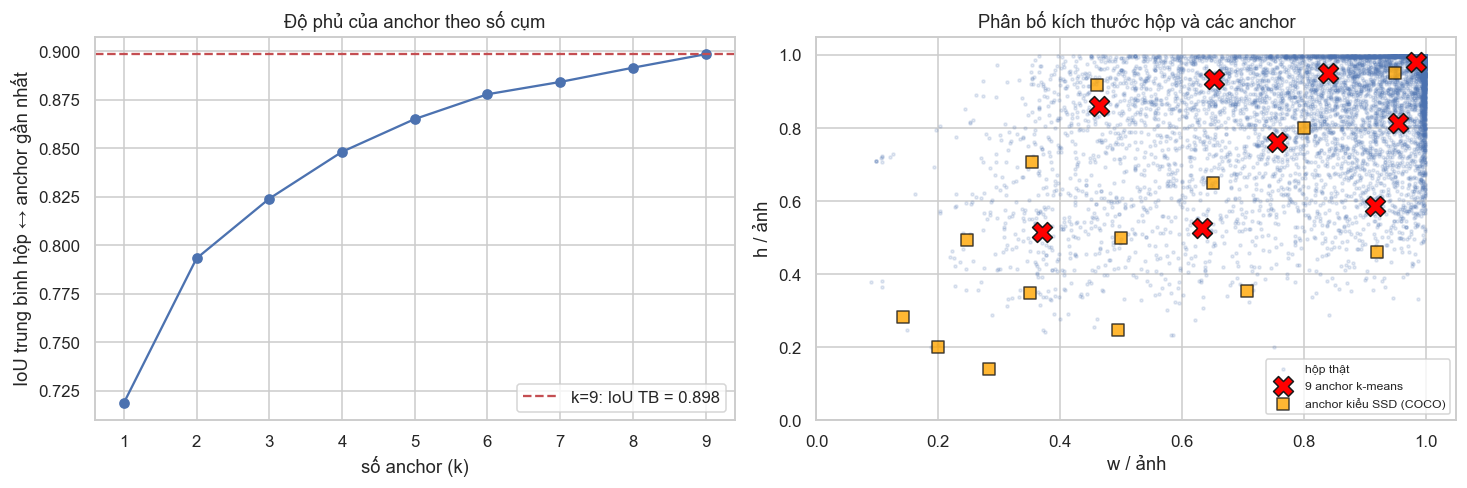

9 anchor tối ưu cho bộ dữ liệu này (w, h chuẩn hoá):
  #1: w=0.369  h=0.515  (≈ 236 x 330 px), tỉ lệ khung 0.72
  #2: w=0.633  h=0.527  (≈ 405 x 337 px), tỉ lệ khung 1.20
  #3: w=0.464  h=0.860  (≈ 297 x 550 px), tỉ lệ khung 0.54
  #4: w=0.916  h=0.586  (≈ 587 x 375 px), tỉ lệ khung 1.56
  #5: w=0.756  h=0.762  (≈ 484 x 488 px), tỉ lệ khung 0.99
  #6: w=0.652  h=0.933  (≈ 417 x 597 px), tỉ lệ khung 0.70
  #7: w=0.955  h=0.815  (≈ 611 x 522 px), tỉ lệ khung 1.17
  #8: w=0.838  h=0.950  (≈ 537 x 608 px), tỉ lệ khung 0.88
  #9: w=0.983  h=0.981  (≈ 629 x 628 px), tỉ lệ khung 1.00

IoU trung bình khi dùng 9 anchor k-means: 0.898
Nhận xét: cụm anchor tối ưu tập trung ở vùng hộp LỚN (gần góc trên-phải của biểu đồ),
trong khi anchor kiểu SSD/COCO rải đều cả vùng hộp nhỏ -> phần lớn anchor nhỏ gần như
KHÔNG BAO GIỜ được gán positive trên bộ dữ liệu này. Thiết kế lại anchor theo các giá trị
in ở trên (hoặc dùng mô hình anchor-free như YOLOv8) là hướng cải thiện có cơ sở định lượng.


In [43]:
# =============================================================================
# ✅ CẢI THIỆN 1 — PHÂN CỤM K-MEANS TRÊN KÍCH THƯỚC HỘP ĐỂ THIẾT KẾ LẠI ANCHOR
#   Cho thấy anchor mặc định (thiết kế cho COCO) lệch bao nhiêu so với dữ liệu này.
# =============================================================================
from sklearn.cluster import KMeans

wh = boxes_df[["w", "h"]].values.astype(np.float32) / IMG_SIZE     # chuẩn hoá về [0,1]

ks = list(range(1, 10))
dists = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(wh)
    # Độ khớp trung bình = IoU giữa hộp và tâm cụm gần nhất (giả định cùng tâm)
    c = km.cluster_centers_
    inter = np.minimum(wh[:, None, 0], c[None, :, 0]) * np.minimum(wh[:, None, 1], c[None, :, 1])
    union = wh[:, 0:1] * wh[:, 1:2] + (c[:, 0] * c[:, 1])[None, :] - inter
    dists.append(float((inter / union).max(axis=1).mean()))

K_ANCHOR = 9
km = KMeans(n_clusters=K_ANCHOR, random_state=SEED, n_init=10).fit(wh)
centers = km.cluster_centers_[np.argsort(km.cluster_centers_.prod(axis=1))]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
axes[0].plot(ks, dists, "o-")
axes[0].axhline(dists[K_ANCHOR - 1], ls="--", c="r",
                label=f"k={K_ANCHOR}: IoU TB = {dists[K_ANCHOR - 1]:.3f}")
axes[0].set_xlabel("số anchor (k)"); axes[0].set_ylabel("IoU trung bình hộp ↔ anchor gần nhất")
axes[0].set_title("Độ phủ của anchor theo số cụm"); axes[0].legend()

axes[1].scatter(wh[:, 0], wh[:, 1], s=4, alpha=0.15, label="hộp thật")
axes[1].scatter(centers[:, 0], centers[:, 1], s=170, marker="X", c="red",
                edgecolor="k", label=f"{K_ANCHOR} anchor k-means")
# Anchor mặc định của SSDlite320 (tỉ lệ scale theo COCO) để đối chiếu
ssd_scales = [0.2, 0.35, 0.5, 0.65, 0.8, 0.95]
ssd_ratios = [1.0, 2.0, 0.5]
ssd_pts = [(s * math.sqrt(r), s / math.sqrt(r)) for s in ssd_scales for r in ssd_ratios]
ssd_pts = np.array(ssd_pts)
axes[1].scatter(ssd_pts[:, 0], ssd_pts[:, 1], s=60, marker="s", c="orange",
                edgecolor="k", alpha=0.8, label="anchor kiểu SSD (COCO)")
axes[1].set_xlabel("w / ảnh"); axes[1].set_ylabel("h / ảnh")
axes[1].set_title("Phân bố kích thước hộp và các anchor"); axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 1.05); axes[1].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print(f"{K_ANCHOR} anchor tối ưu cho bộ dữ liệu này (w, h chuẩn hoá):")
for i, (w_, h_) in enumerate(centers, 1):
    print(f"  #{i}: w={w_:.3f}  h={h_:.3f}  (≈ {w_*IMG_SIZE:.0f} x {h_*IMG_SIZE:.0f} px), "
          f"tỉ lệ khung {w_/max(h_,1e-6):.2f}")
print(f"\nIoU trung bình khi dùng {K_ANCHOR} anchor k-means: {dists[K_ANCHOR-1]:.3f}")
print("Nhận xét: cụm anchor tối ưu tập trung ở vùng hộp LỚN (gần góc trên-phải của biểu đồ),")
print("trong khi anchor kiểu SSD/COCO rải đều cả vùng hộp nhỏ -> phần lớn anchor nhỏ gần như")
print("KHÔNG BAO GIỜ được gán positive trên bộ dữ liệu này. Thiết kế lại anchor theo các giá trị")
print("in ở trên (hoặc dùng mô hình anchor-free như YOLOv8) là hướng cải thiện có cơ sở định lượng.")

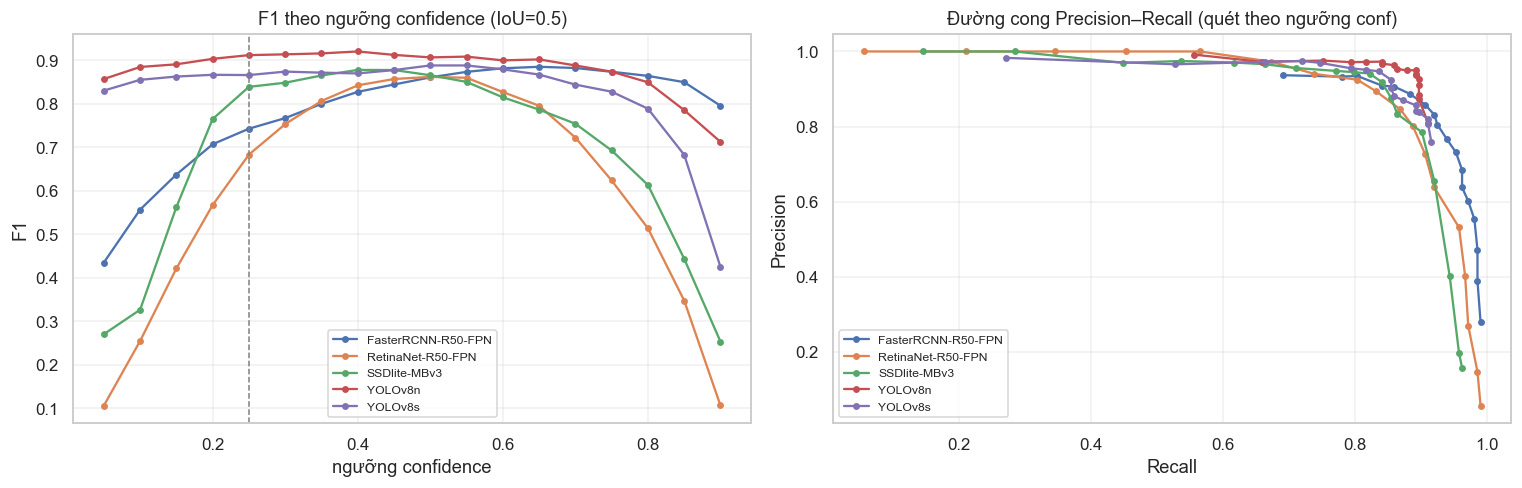

Ngưỡng conf tối ưu theo F1 (so với mặc định 0.25):


,conf,precision,recall,f1
Mô hình,,,,
FasterRCNN-R50-FPN,0.65,0.8873,0.8832,0.8852
RetinaNet-R50-FPN,0.50,0.8945,0.8318,0.8620
SSDlite-MBv3,0.40,0.9184,0.8411,0.8780
YOLOv8n,0.40,0.9502,0.8925,0.9205
YOLOv8s,0.50,0.9242,0.8551,0.8883


SSDlite-MBv3: chỉ cần đổi ngưỡng 0.25 -> 0.40, F1 tăng từ 0.8391 lên 0.8780 (+0.0389) mà KHÔNG cần huấn luyện lại.

Lưu ý: mAP KHÔNG thay đổi theo ngưỡng conf (nó lấy tích phân trên toàn đường P-R);
việc chỉnh ngưỡng chỉ dịch chuyển ĐIỂM VẬN HÀNH — nhưng đây đúng là thứ quyết định
chất lượng cảm nhận được của hệ thống thật.


In [44]:
# =============================================================================
# ✅ CẢI THIỆN 2 — QUÉT NGƯỠNG CONF: TÌM ĐIỂM VẬN HÀNH TỐI ƯU
#   Tính lại P/R/F1 từ detection đã lưu (RAW_DETS) -> gần như miễn phí.
# =============================================================================
if RAW_DETS:
    thresholds = np.round(np.arange(0.05, 0.91, 0.05), 2)
    sweep_rows = []
    for name, dets in RAW_DETS.items():
        for t in thresholds:
            micro, _ = prf1_at(dets, SPLITS["test"], conf=float(t), iou_thr=IOU_REPORT)
            sweep_rows.append({"Mô hình": name, "conf": float(t),
                               "precision": micro["precision"],
                               "recall": micro["recall"], "f1": micro["f1"]})
    sweep_df = pd.DataFrame(sweep_rows)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for name, g in sweep_df.groupby("Mô hình"):
        axes[0].plot(g["conf"], g["f1"], "o-", ms=3.5, label=name)
        axes[1].plot(g["recall"], g["precision"], "o-", ms=3.5, label=name)
    axes[0].set_xlabel("ngưỡng confidence"); axes[0].set_ylabel("F1")
    axes[0].set_title(f"F1 theo ngưỡng confidence (IoU={IOU_REPORT})")
    axes[0].axvline(CONF_REPORT, ls="--", c="gray", lw=1)
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Đường cong Precision–Recall (quét theo ngưỡng conf)")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    best_thr = (sweep_df.loc[sweep_df.groupby("Mô hình")["f1"].idxmax()]
                .set_index("Mô hình")[["conf", "precision", "recall", "f1"]])
    print(f"Ngưỡng conf tối ưu theo F1 (so với mặc định {CONF_REPORT}):")
    display(best_thr.round(4))
    if BEST_MODEL in best_thr.index:
        row = best_thr.loc[BEST_MODEL]
        base = PRF[BEST_MODEL][0]["f1"]
        print(f"{BEST_MODEL}: chỉ cần đổi ngưỡng {CONF_REPORT} -> {row['conf']:.2f}, "
              f"F1 tăng từ {base:.4f} lên {row['f1']:.4f} "
              f"({row['f1'] - base:+.4f}) mà KHÔNG cần huấn luyện lại.")
    print("\nLưu ý: mAP KHÔNG thay đổi theo ngưỡng conf (nó lấy tích phân trên toàn đường P-R);")
    print("việc chỉnh ngưỡng chỉ dịch chuyển ĐIỂM VẬN HÀNH — nhưng đây đúng là thứ quyết định")
    print("chất lượng cảm nhận được của hệ thống thật.")

Thử nghiệm cải thiện trên: YOLOv8s



suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.727
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.928
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.791
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.727
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.761
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.791
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.791
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.791


suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.738
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.930
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.812
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.738
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.761
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.810
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.810
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.810


suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.748
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.925
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.836
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.748
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.761
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.830
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.832
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.832


suy luận (YOLO):   0%|          | 0/13 [00:00<?, ?it/s]

 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.778
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.934
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.841
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.778
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.802
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.856
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.856
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.856


,Cấu hình,mAP@0.5,mAP@0.5:0.95,AR@100
0,gốc (NMS IoU=0.6),0.9283,0.7407,0.8172
1,NMS IoU=0.45,0.9280,0.7271,0.7911
2,NMS IoU=0.55,0.9298,0.7384,0.8100
3,NMS IoU=0.7,0.9250,0.7479,0.8324
4,TTA (augment=True),0.9338,0.7784,0.8556


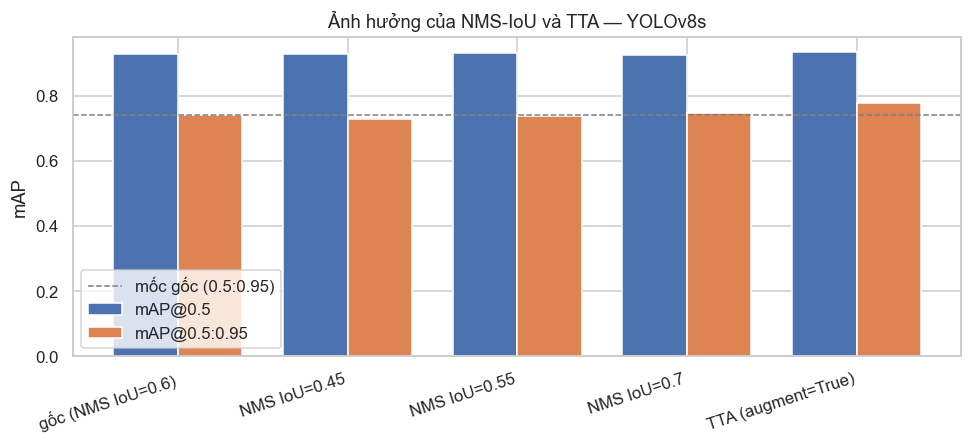

TTA: mAP@0.5:0.95 thay đổi +0.0377 (có cải thiện), độ trễ ~12.7 ms/ảnh so với 16.1 ms/ảnh khi không TTA (gấp ~0.8x).
Cấu hình tốt nhất trong thử nghiệm này: 'TTA (augment=True)' với mAP@0.5:0.95 = 0.7784.
=> Kết luận: chỉnh NMS/TTA là cách cải thiện KHÔNG cần huấn luyện lại; hãy cân nhắc
   mức tăng mAP so với chi phí độ trễ tăng thêm trước khi đưa vào hệ thống thật.


In [45]:
# =============================================================================
# ✅ CẢI THIỆN 3 — TTA (test-time augmentation) + QUÉT NGƯỠNG NMS
#   Áp dụng cho mô hình YOLO tốt nhất (Ultralytics hỗ trợ sẵn augment=True).
#   Vẫn dùng ĐÚNG bộ đo chung -> so sánh hợp lệ.
# =============================================================================
yolo_candidates = [n for n in results_df["Mô hình"]
                   if n in TRAINED and is_yolo(TRAINED[n])] if len(results_df) else []

if yolo_candidates:
    tgt = yolo_candidates[0]        # YOLO tốt nhất (results_df đã sắp theo mAP giảm dần)
    model = TRAINED[tgt]
    print(f"Thử nghiệm cải thiện trên: {tgt}\n")

    imp_rows = []
    base = EVAL_RES[tgt]
    imp_rows.append({"Cấu hình": f"gốc (NMS IoU={NMS_IOU})",
                     "mAP@0.5": base["mAP@0.5"],
                     "mAP@0.5:0.95": base["mAP@0.5:0.95"],
                     "AR@100": base["AR@100"]})

    # (a) quét ngưỡng IoU của NMS
    for iou_v in [0.45, 0.55, 0.70]:
        d = predict_yolo(model, TEST_PATHS, iou=iou_v)
        r_ = run_eval(COCO_GT["test"], d, TEST_IMAGE_IDS)
        imp_rows.append({"Cấu hình": f"NMS IoU={iou_v}",
                         "mAP@0.5": r_["mAP@0.5"],
                         "mAP@0.5:0.95": r_["mAP@0.5:0.95"],
                         "AR@100": r_["AR@100"]})

    # (b) TTA: Ultralytics tự lật + đa tỉ lệ rồi hợp nhất kết quả
    t0 = time.perf_counter()
    d_tta = predict_yolo(model, TEST_PATHS, augment=True)
    tta_time = (time.perf_counter() - t0) / max(1, len(TEST_PATHS)) * 1000
    r_tta = run_eval(COCO_GT["test"], d_tta, TEST_IMAGE_IDS)
    imp_rows.append({"Cấu hình": "TTA (augment=True)",
                     "mAP@0.5": r_tta["mAP@0.5"],
                     "mAP@0.5:0.95": r_tta["mAP@0.5:0.95"],
                     "AR@100": r_tta["AR@100"]})

    imp_df = pd.DataFrame(imp_rows)
    display(imp_df.round(4))

    fig, ax = plt.subplots(figsize=(9, 4.2))
    x = np.arange(len(imp_df)); w = 0.38
    ax.bar(x - w / 2, imp_df["mAP@0.5"], w, label="mAP@0.5")
    ax.bar(x + w / 2, imp_df["mAP@0.5:0.95"], w, label="mAP@0.5:0.95")
    ax.axhline(base["mAP@0.5:0.95"], ls="--", c="gray", lw=1, label="mốc gốc (0.5:0.95)")
    ax.set_xticks(x); ax.set_xticklabels(imp_df["Cấu hình"], rotation=18, ha="right")
    ax.set_ylabel("mAP"); ax.set_title(f"Ảnh hưởng của NMS-IoU và TTA — {tgt}")
    ax.legend(); plt.tight_layout(); plt.show()

    d_map = r_tta["mAP@0.5:0.95"] - base["mAP@0.5:0.95"]
    base_ms = float(results_df.loc[results_df["Mô hình"] == tgt, "ms/ảnh"].iloc[0])
    print(f"TTA: mAP@0.5:0.95 thay đổi {d_map:+.4f} "
          f"({'có cải thiện' if d_map > 0 else 'không cải thiện'}), "
          f"độ trễ ~{tta_time:.1f} ms/ảnh so với {base_ms:.1f} ms/ảnh khi không TTA "
          f"(gấp ~{tta_time / max(base_ms, 1e-9):.1f}x).")
    best_nms = imp_df.iloc[imp_df['mAP@0.5:0.95'].idxmax()]
    print(f"Cấu hình tốt nhất trong thử nghiệm này: '{best_nms['Cấu hình']}' "
          f"với mAP@0.5:0.95 = {best_nms['mAP@0.5:0.95']:.4f}.")
    print("=> Kết luận: chỉnh NMS/TTA là cách cải thiện KHÔNG cần huấn luyện lại; hãy cân nhắc")
    print("   mức tăng mAP so với chi phí độ trễ tăng thêm trước khi đưa vào hệ thống thật.")
else:
    print("Không có mô hình YOLO nào để chạy thử nghiệm TTA/NMS.")

---
# Phần 13 — Kết luận

Notebook đã thực hiện đầy đủ các yêu cầu của đề bài:

1. **Phát hiện vật thể trong nhà** trên bộ *SyntheticIndoorObjectDetectionDataset*
   (6 lớp: `basketbin`, `chair`, `door`, `human`, `sofa`, `table`; nhãn Pascal VOC XML;
   7 107 ảnh 640×640; giấy phép CC BY 4.0).
2. **So sánh 5 mô hình thuộc 3 họ kiến trúc**: anchor-free one-stage (YOLOv8n/s),
   two-stage (Faster R-CNN R50-FPN), one-stage anchor-based với focal loss (RetinaNet R50-FPN)
   và với hard-negative-mining (SSDlite-MobileNetV3) — **trên cùng một split**
   và chấm bằng **một bộ đo `COCOeval` duy nhất**.
3. **Đánh giá** bằng mAP@0.5, mAP@0.5:0.95, mAP@0.75, AP từng lớp, AR@100, P/R/F1,
   tốc độ suy luận, số tham số và dung lượng mô hình; kèm so sánh định tính và bảng ca lỗi.
4. **Đề xuất cải thiện** với ba thực nghiệm minh hoạ trực tiếp: phân cụm k-means để thiết kế lại
   anchor, quét ngưỡng confidence để chọn điểm vận hành, và TTA + quét ngưỡng NMS.

**Ba bài học quan trọng nhất rút ra:**

* **Đặc tính dữ liệu quyết định nhiều hơn kiến trúc.** Vì bộ dữ liệu này gần như chỉ có một vật
  thể lớn trên mỗi ảnh, khác biệt giữa các kiến trúc bị nén lại rất nhiều so với trên COCO.
  Đầu tư vào **chất lượng và mật độ nhãn** sẽ hiệu quả hơn hẳn việc đổi sang mô hình phức tạp hơn.
* **Đo lường phải thống nhất.** Chỉ số nội bộ của các thư viện khác nhau **không so sánh được**;
  toàn bộ notebook được thiết kế xoay quanh một `COCOeval` duy nhất, dùng chung cho mọi mô hình.
* **mAP không phải tiêu chí triển khai.** Với robot di động trong nhà, độ trễ và bộ nhớ là ràng
  buộc cứng; biểu đồ *độ chính xác ↔ tốc độ* và biên Pareto mới là căn cứ chọn mô hình.

**Cách chạy để lấy số liệu chính thức:** đặt `QUICK_RUN = False` ở ô cấu hình, gắn Google Drive,
chọn runtime GPU, rồi chạy lại toàn bộ notebook (Runtime → Run all). Nếu phiên Colab bị ngắt,
checkpoint và bảng kết quả đã được lưu trong `RUNS_DIR` trên Drive; với YOLO có thể học tiếp bằng
`YOLO(".../weights/last.pt").train(resume=True)`.

In [46]:
# =============================================================================
# LƯU TOÀN BỘ KẾT QUẢ (để nộp kèm / phòng khi Colab ngắt kết nối)
# =============================================================================
out_dir = RUNS_DIR / "final_results"
out_dir.mkdir(parents=True, exist_ok=True)

saved = []
if len(results_df):
    results_df.to_csv(out_dir / "comparison.csv", index=False); saved.append("comparison.csv")
if EVAL_RES:
    pd.DataFrame({n: pd.Series(r["per_class_AP"]) for n, r in EVAL_RES.items()}).T \
        .to_csv(out_dir / "per_class_AP.csv"); saved.append("per_class_AP.csv")
if PRF:
    pd.concat([df.assign(model=n) for n, (m, df) in PRF.items()]) \
        .to_csv(out_dir / "per_class_PRF1.csv", index=False); saved.append("per_class_PRF1.csv")
if "sweep_df" in dir():
    sweep_df.to_csv(out_dir / "conf_sweep.csv", index=False); saved.append("conf_sweep.csv")
if "imp_df" in dir():
    imp_df.to_csv(out_dir / "improvements.csv", index=False); saved.append("improvements.csv")
split_df.to_csv(out_dir / "split_stats.csv", index=False); saved.append("split_stats.csv")

meta = {
    "dataset": "SyntheticIndoorObjectDetectionDataset (Mendeley 10.17632/nnph98d3kc.2)",
    "license": "CC BY 4.0",
    "annotation_format": ANN_FORMAT,
    "classes": CLASS_NAMES,
    "n_images_total": len(RECORDS),
    "n_boxes_total": int(len(boxes_df)),
    "split_mode": SPLIT_MODE,
    "split_sizes": {k: len(v) for k, v in SPLITS.items()},
    "quick_run": QUICK_RUN,
    "epochs_yolo": EPOCHS_YOLO, "epochs_torchvision": EPOCHS_TV,
    "img_size": IMG_SIZE, "device": DEVICE,
    "eval_backend": EVAL_BACKEND,
    "models_trained": list(TRAINED.keys()),
    "models_failed": FAILED,
}
(out_dir / "run_metadata.json").write_text(json.dumps(meta, indent=2, ensure_ascii=False))
saved.append("run_metadata.json")

print("Đã lưu vào", out_dir)
for s in saved:
    print("  -", s)
if FAILED:
    print("\nCác mô hình gặp lỗi (nếu có):", FAILED)

Đã lưu vào /content/drive/MyDrive/dl_homework/hw2/final_results
  - comparison.csv
  - per_class_AP.csv
  - per_class_PRF1.csv
  - conf_sweep.csv
  - improvements.csv
  - split_stats.csv
  - run_metadata.json
